In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras import layers

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

In [123]:
df = pd.read_csv('data/jepx_data.csv')
df

,date_time,Sell bid amount,Buy bid amount,Total contract amount,System price,Hokkaido area price,Tohoku area price,Tokyo area price,Chubu area price,Hokuriku area price,Kansai area price,Chugoku area price,Shikoku area price,Kyushu area price,Sell block bid total amount,Total sell block execution amount,Buy block bid total amount,Total buy block total amount
0,2005/04/02 00:00:00,676500,198000,0,6.71,6.71,6.71,6.71,6.71,6.71,6.71,6.71,6.71,6.71,NaN,NaN,NaN,NaN
1,2005/04/02 00:30:00,676500,192000,0,6.65,6.65,6.65,6.65,6.65,6.65,6.65,6.65,6.65,6.65,NaN,NaN,NaN,NaN
2,2005/04/02 01:00:00,670000,189000,10000,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,NaN,NaN,NaN,NaN
3,2005/04/02 01:30:00,670000,186500,10000,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,6.39,NaN,NaN,NaN,NaN
4,2005/04/02 02:00:00,676500,184500,15000,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359179,2025/09/26 21:30:00,23194300,20334000,14866150,11.20,15.19,11.41,11.41,11.41,9.00,9.00,9.00,9.00,9.00,7173000.0,1198500.0,1806050.0,1716050.0
359180,2025/09/26 22:00:00,23034150,20511100,14615100,10.91,11.58,11.58,11.58,11.58,8.96,8.96,8.96,8.96,8.96,7190600.0,1119450.0,1929850.0,1739850.0
359181,2025/09/26 22:30:00,23050450,20236750,14594650,10.58,11.20,11.20,11.20,11.20,8.63,8.63,8.63,8.63,8.63,7329400.0,1134050.0,1987550.0,1797550.0
359182,2025/09/26 23:00:00,22656650,19873650,14393800,10.32,11.37,11.37,11.37,8.50,8.50,8.50,8.50,8.50,8.50,7058100.0,1132600.0,1710900.0,1520900.0


## 2020

In [121]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)

cutoff_date = '2020-01-01'
df = df[df.index >= cutoff_date].copy()
df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
date_time,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,17030600,18224200,14612900,6.78,11.01,6.78,6.78,6.78,6.78,6.78,6.78,6.78,5.41,3530350.0,2354700.0,913800.0,783800.0
2020-01-01 00:30:00,17944550,18188300,14600550,6.64,10.36,6.72,6.72,6.72,6.72,6.72,6.72,6.72,5.16,4241700.0,2355050.0,1096300.0,921300.0
2020-01-01 01:00:00,19106350,18205200,14706000,6.53,10.36,6.53,6.53,6.53,6.53,6.53,6.53,6.53,5.16,4602150.0,2345200.0,1498800.0,1223800.0
2020-01-01 01:30:00,19604000,18372650,14890500,6.53,9.34,6.53,6.53,6.53,6.53,6.53,6.53,6.53,5.16,4886350.0,2318050.0,1754800.0,1379800.0
2020-01-01 02:00:00,19956600,18536600,15275850,6.92,9.34,6.92,6.92,6.92,6.92,6.92,6.92,6.92,5.16,5265350.0,2338050.0,1923800.0,1448800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 21:30:00,23194300,20334000,14866150,11.20,15.19,11.41,11.41,11.41,9.00,9.00,9.00,9.00,9.00,7173000.0,1198500.0,1806050.0,1716050.0
2025-09-26 22:00:00,23034150,20511100,14615100,10.91,11.58,11.58,11.58,11.58,8.96,8.96,8.96,8.96,8.96,7190600.0,1119450.0,1929850.0,1739850.0
2025-09-26 22:30:00,23050450,20236750,14594650,10.58,11.20,11.20,11.20,11.20,8.63,8.63,8.63,8.63,8.63,7329400.0,1134050.0,1987550.0,1797550.0


In [119]:
df.isnull().sum()

sell_bid_amount                      0
buy_bid_amount                       0
total_contract_amount                0
system_price                         0
hokkaido_area_price                  0
tohoku_area_price                    0
tokyo_area_price                     0
chubu_area_price                     0
hokuriku_area_price                  0
kansai_area_price                    0
chugoku_area_price                   0
shikoku_area_price                   0
kyushu_area_price                    0
sell_block_bid_total_amount          0
total_sell_block_execution_amount    0
buy_block_bid_total_amount           0
total_buy_block_total_amount         0
dtype: int64

In [6]:
df.describe()

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
count,1.006080e+05,1.006080e+05,1.006080e+05,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,1.006080e+05,1.006080e+05,1.006080e+05,1.006080e+05
mean,2.321723e+07,2.066022e+07,1.691959e+07,13.104273,13.886143,13.737969,14.594362,13.456716,12.759227,12.700233,12.552677,12.250745,10.896091,6.767787e+06,2.417610e+06,2.527096e+06,1.882345e+06
std,4.459279e+06,3.947171e+06,3.219194e+06,12.488840,13.408171,13.554101,13.720824,12.438366,12.225770,12.217595,12.144013,12.196213,11.811512,2.443724e+06,1.321753e+06,1.087553e+06,9.002489e+05
min,1.250215e+07,8.581700e+06,8.253000e+06,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,1.264250e+06,8.845000e+04,7.885000e+04,7.885000e+04
25%,2.006885e+07,1.785155e+07,1.456049e+07,7.040000,7.380000,7.090000,7.820000,7.120000,6.840000,6.800000,6.760000,6.540000,5.630000,5.015750e+06,1.145675e+06,1.724075e+06,1.226725e+06
50%,2.248050e+07,2.040570e+07,1.688678e+07,10.770000,11.230000,11.210000,11.990000,11.250000,10.270000,10.190000,10.110000,9.760000,9.000000,6.248000e+06,2.425875e+06,2.404900e+06,1.763850e+06
75%,2.560200e+07,2.320005e+07,1.908315e+07,15.830000,16.750000,16.180000,17.010000,16.560000,16.030000,16.000000,15.840000,15.402500,13.250000,8.020212e+06,3.575612e+06,3.225112e+06,2.418662e+06
max,4.921920e+07,3.733535e+07,2.770770e+07,251.000000,252.000000,252.000000,252.000000,242.210000,242.210000,242.210000,242.210000,242.210000,242.210000,2.027460e+07,6.066900e+06,7.555200e+06,7.312250e+06


In [116]:
df.to_csv('data/jepx_2020.csv')


--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---


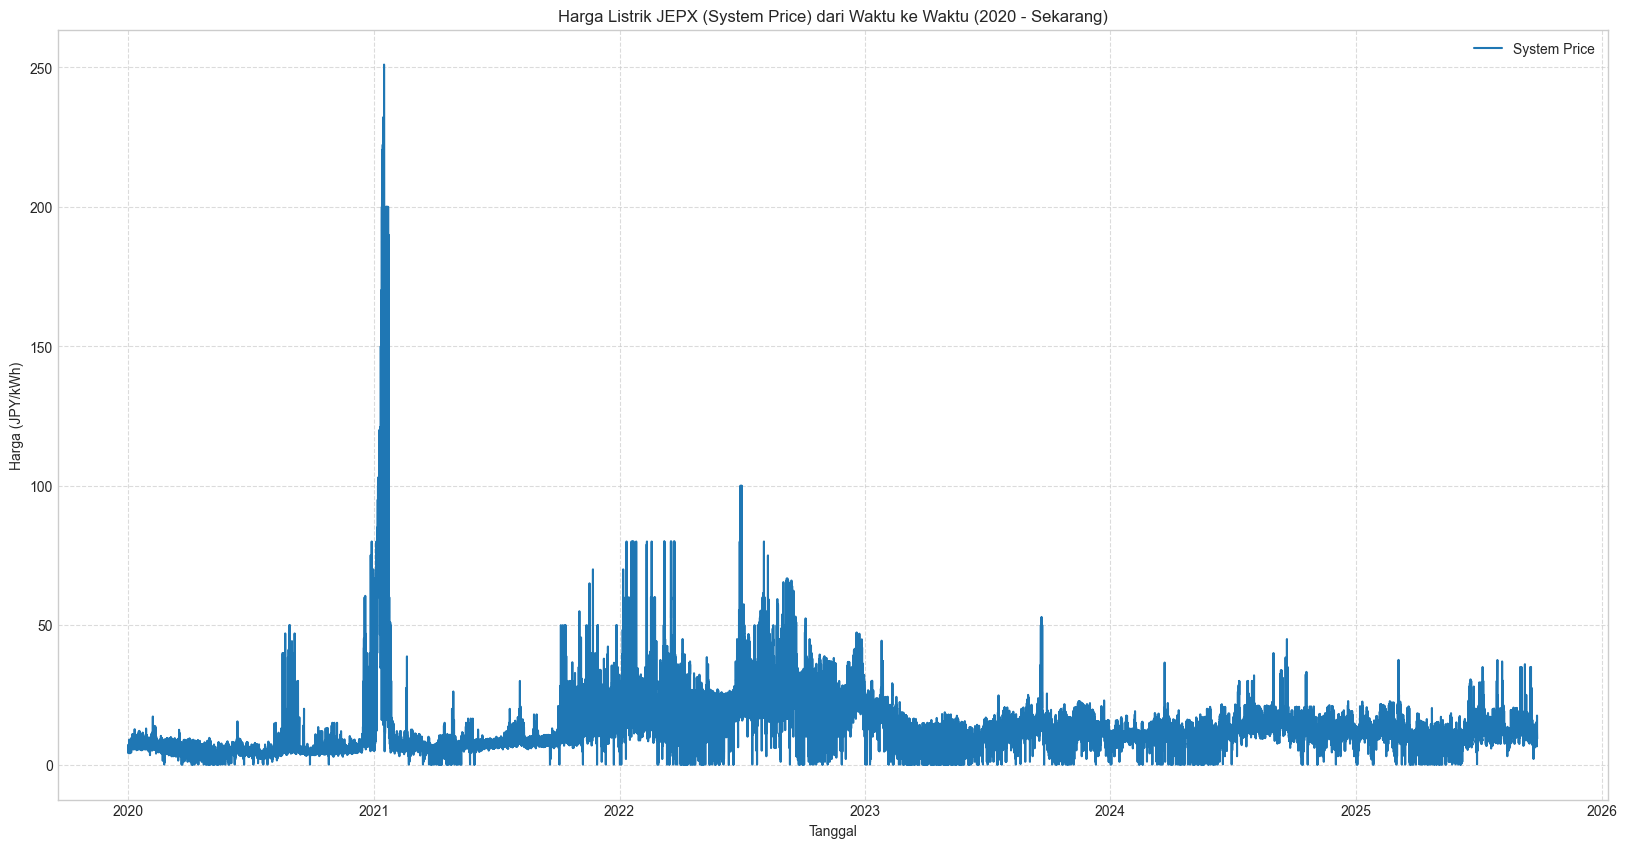


--- Plot Dekomposisi Musiman (Tahun 2022) ---


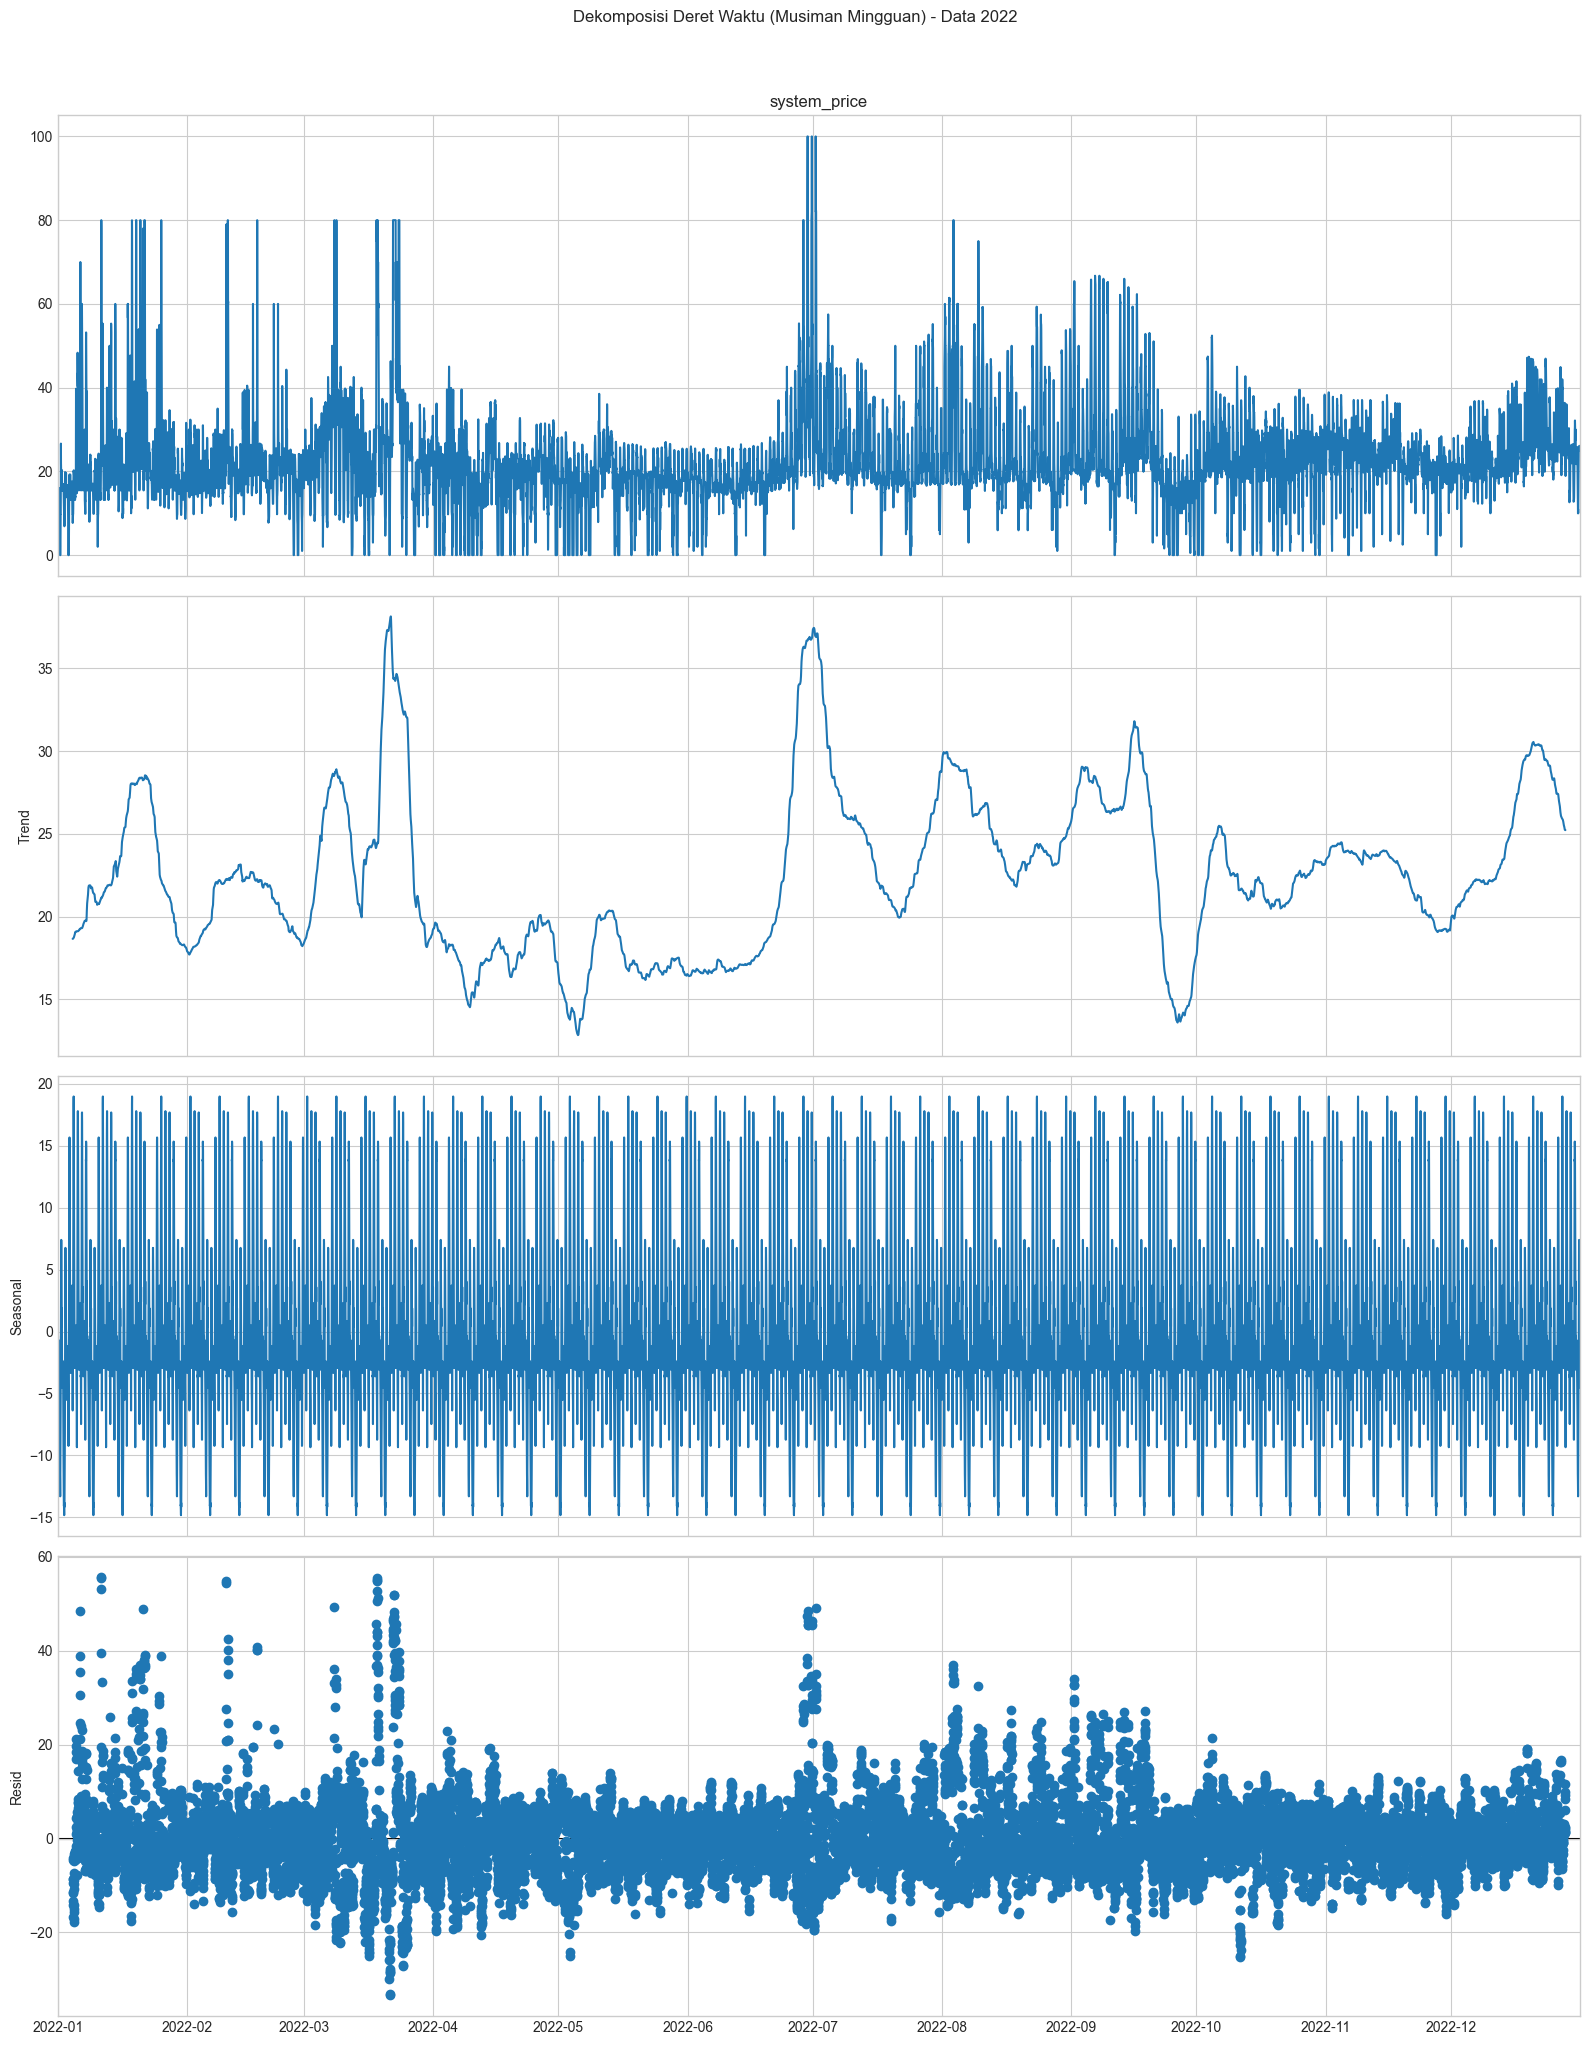


--- Box Plot Musiman ---


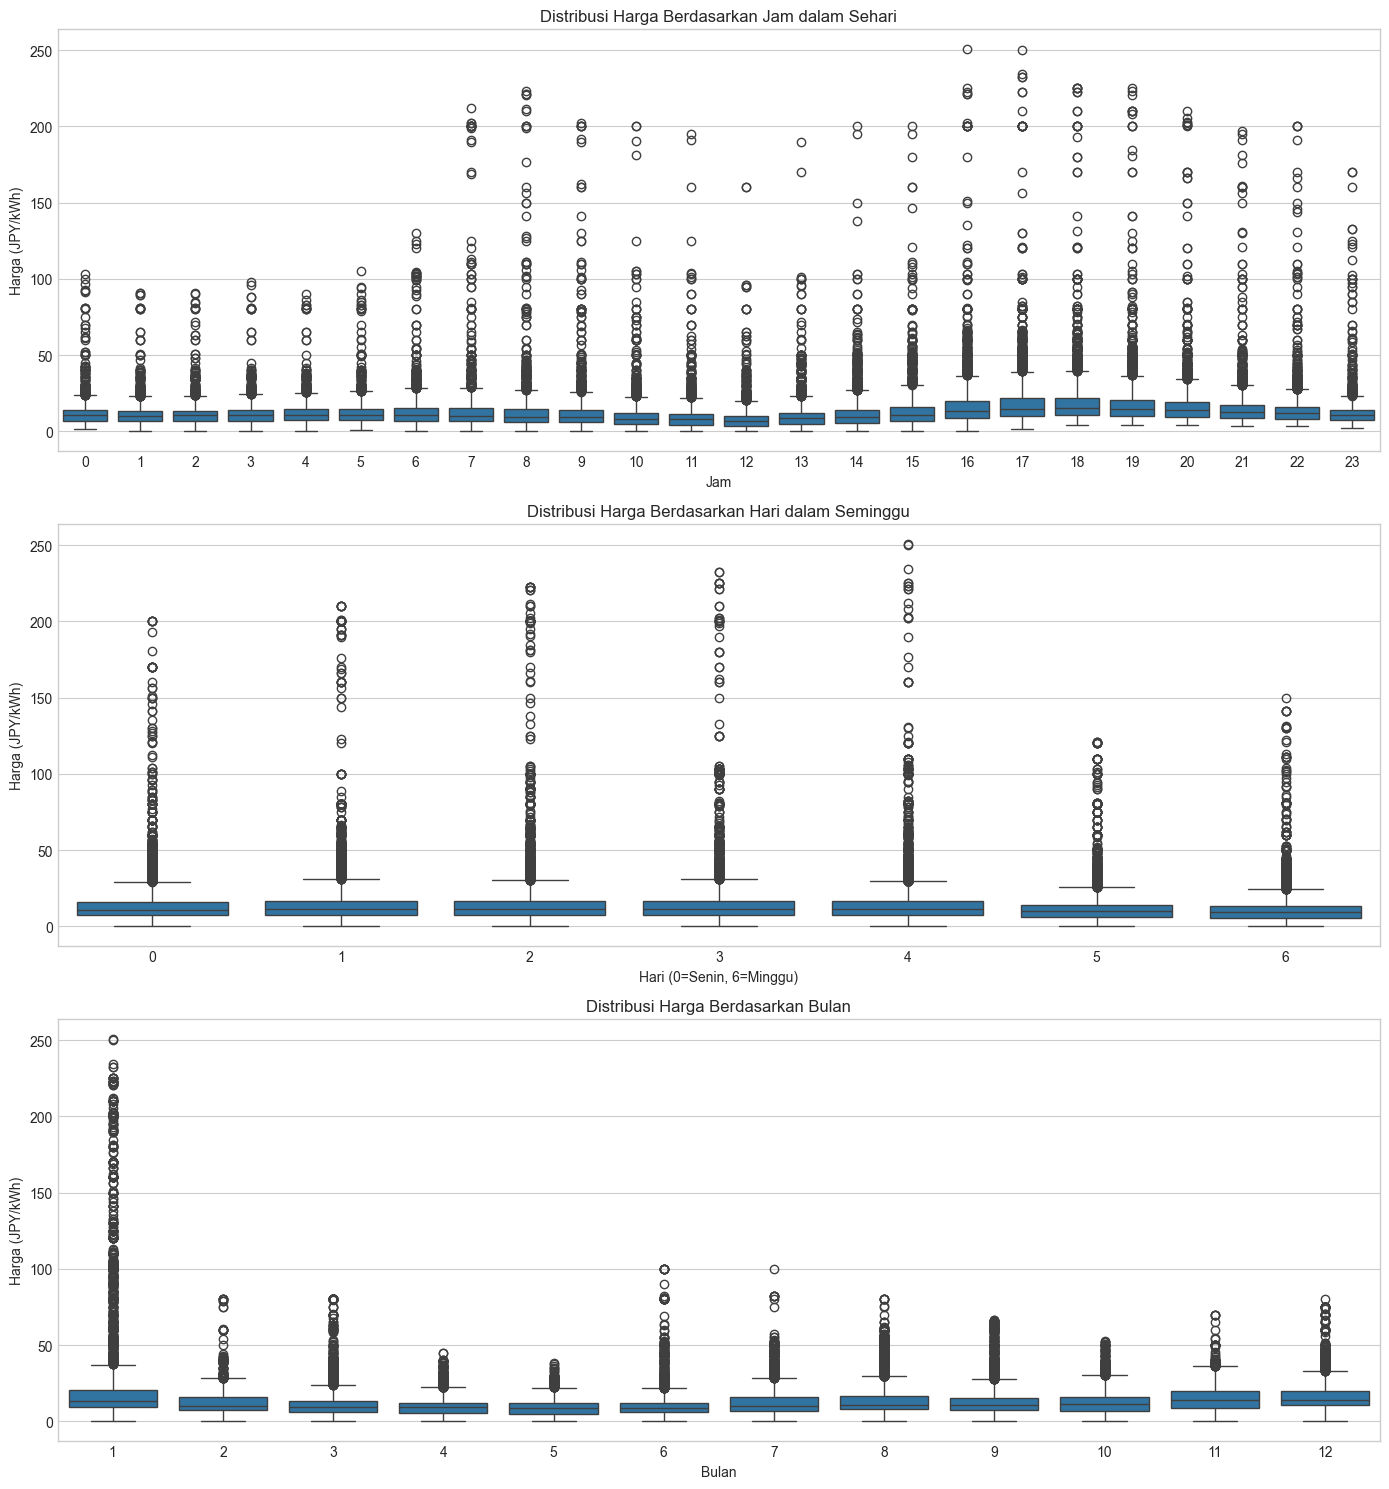

In [7]:
# TAHAP 1: ANALISIS DATA EKSPLORASI (EDA)

print("\n--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---")

# 1.1. Visualisasi Data Awal

price_col = 'system_price'

# 1.1. Visualisasi Data Awal

# Plot Deret Waktu Keseluruhan
plt.figure(figsize=(20, 10))
plt.plot(df.index, df[price_col], label='System Price')
plt.title('Harga Listrik JEPX (System Price) dari Waktu ke Waktu (2020 - Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (JPY/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---
# Catatan: Untuk Dekomposisi Musiman, period=48*7 (48 titik per hari * 7 hari) adalah musiman mingguan
# Menggunakan data dari tahun 2022
if '2022' in df.index:
    print("\n--- Plot Dekomposisi Musiman (Tahun 2022) ---")
    result_decompose = seasonal_decompose(df[price_col]['2022'], model='additive', period=48*7)
    fig = result_decompose.plot()
    fig.set_size_inches(16, 20)
    plt.suptitle('Dekomposisi Deret Waktu (Musiman Mingguan) - Data 2022', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak cukup data untuk dekomposisi tahun 2022, melompati plot dekomposisi.")


# ---

# Box Plot Musiman untuk melihat pola harian, mingguan, dan bulanan
print("\n--- Box Plot Musiman ---")
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

# Pola Harian (berdasarkan jam)
sns.boxplot(x=df.index.hour, y=df[price_col], ax=axes[0]) # Menggunakan axes[0]
axes[0].set_title('Distribusi Harga Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Harga (JPY/kWh)')

# Pola Mingguan (berdasarkan hari)
sns.boxplot(x=df.index.dayofweek, y=df[price_col], ax=axes[1]) # Menggunakan axes[1]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[1].set_title('Distribusi Harga Berdasarkan Hari dalam Seminggu')
axes[1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[1].set_ylabel('Harga (JPY/kWh)')

# Pola Tahunan (berdasarkan bulan)
sns.boxplot(x=df.index.month, y=df[price_col], ax=axes[2]) # Menggunakan axes[2]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[2].set_title('Distribusi Harga Berdasarkan Bulan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Harga (JPY/kWh)')

plt.tight_layout()
plt.show()

In [13]:
TARGET = 'system_price'

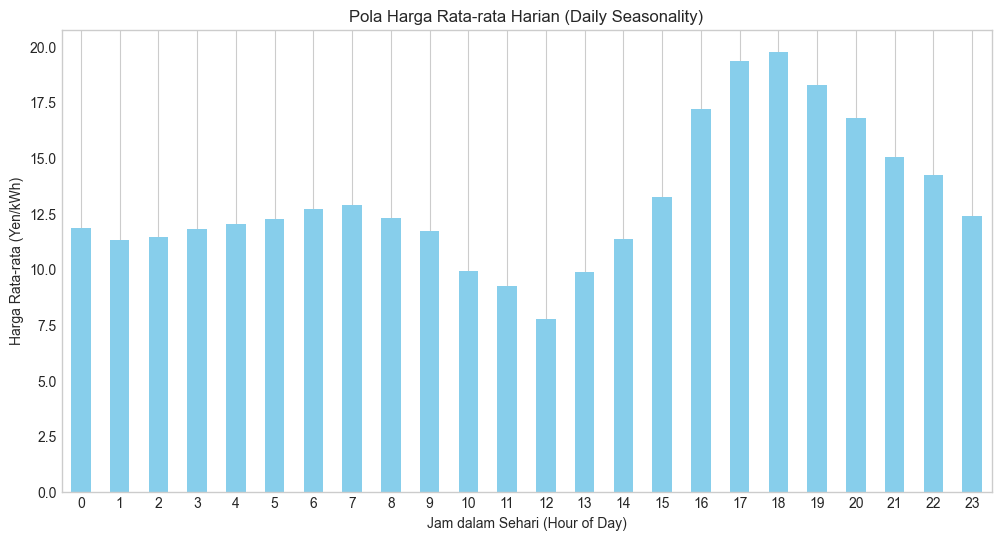

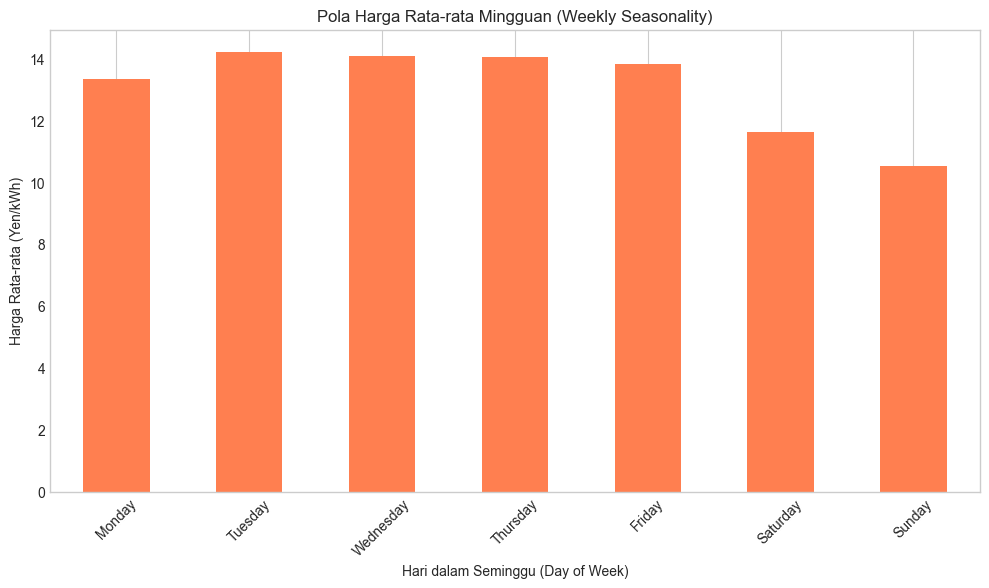

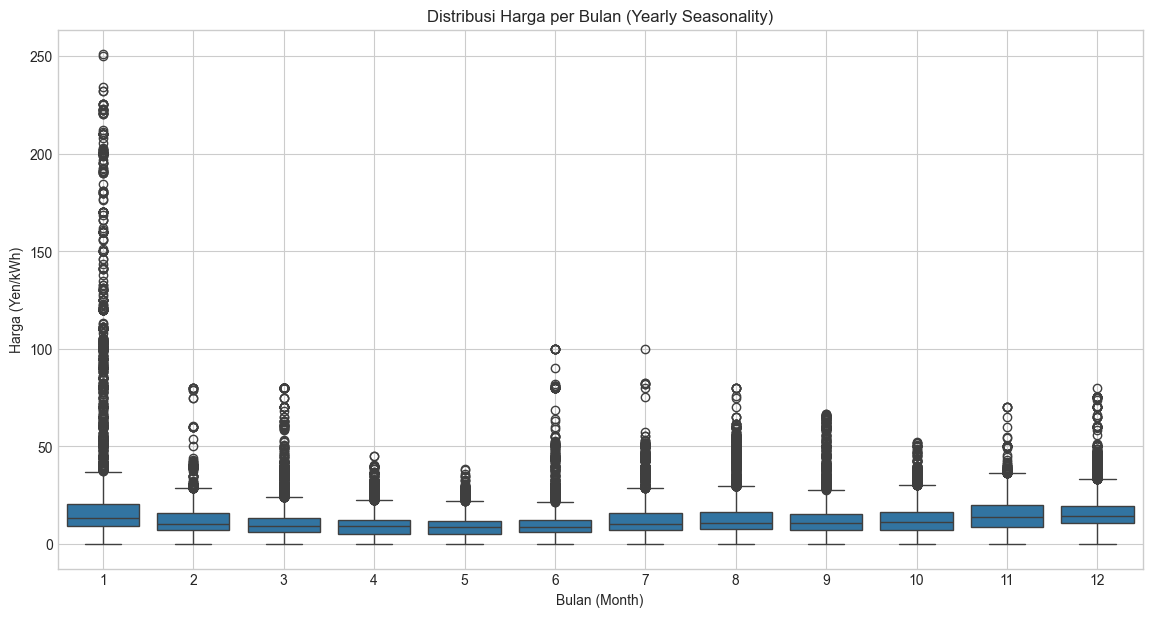

In [9]:
# --- Analisis Musiman Harian (Daily Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan data berdasarkan jam dan menghitung harga rata-rata
hourly_seasonality = df.groupby(df.index.hour)[TARGET].mean()
hourly_seasonality.plot(kind='bar', color='skyblue')
plt.title('Pola Harga Rata-rata Harian (Daily Seasonality)')
plt.xlabel('Jam dalam Sehari (Hour of Day)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Mingguan (Weekly Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan berdasarkan nama hari dan menghitung harga rata-rata
weekly_seasonality = df.groupby(df.index.day_name())[TARGET].mean()
# Mengurutkan hari agar sesuai urutan kalender
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_seasonality = weekly_seasonality.reindex(day_order)
weekly_seasonality.plot(kind='bar', color='coral')
plt.title('Pola Harga Rata-rata Mingguan (Weekly Seasonality)')
plt.xlabel('Hari dalam Seminggu (Day of Week)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Tahunan (Yearly/Monthly Seasonality) ---
plt.figure(figsize=(14, 7))
# Menggunakan boxplot untuk melihat distribusi harga setiap bulan
sns.boxplot(x=df.index.month, y=df[TARGET])
plt.title('Distribusi Harga per Bulan (Yearly Seasonality)')
plt.xlabel('Bulan (Month)')
plt.ylabel('Harga (Yen/kWh)')
plt.grid(True)
plt.show()


Korelasi Fitur terhadap Target (system_price):
system_price                         1.000000
kansai_area_price                    0.964479
hokuriku_area_price                  0.964121
chubu_area_price                     0.962602
chugoku_area_price                   0.961723
shikoku_area_price                   0.955479
tokyo_area_price                     0.946230
tohoku_area_price                    0.944200
hokkaido_area_price                  0.934474
kyushu_area_price                    0.918884
buy_bid_amount                       0.300173
total_sell_block_execution_amount    0.179850
total_contract_amount                0.130157
buy_block_bid_total_amount          -0.048837
total_buy_block_total_amount        -0.240768
sell_bid_amount                     -0.266654
sell_block_bid_total_amount         -0.350647
Name: system_price, dtype: float64


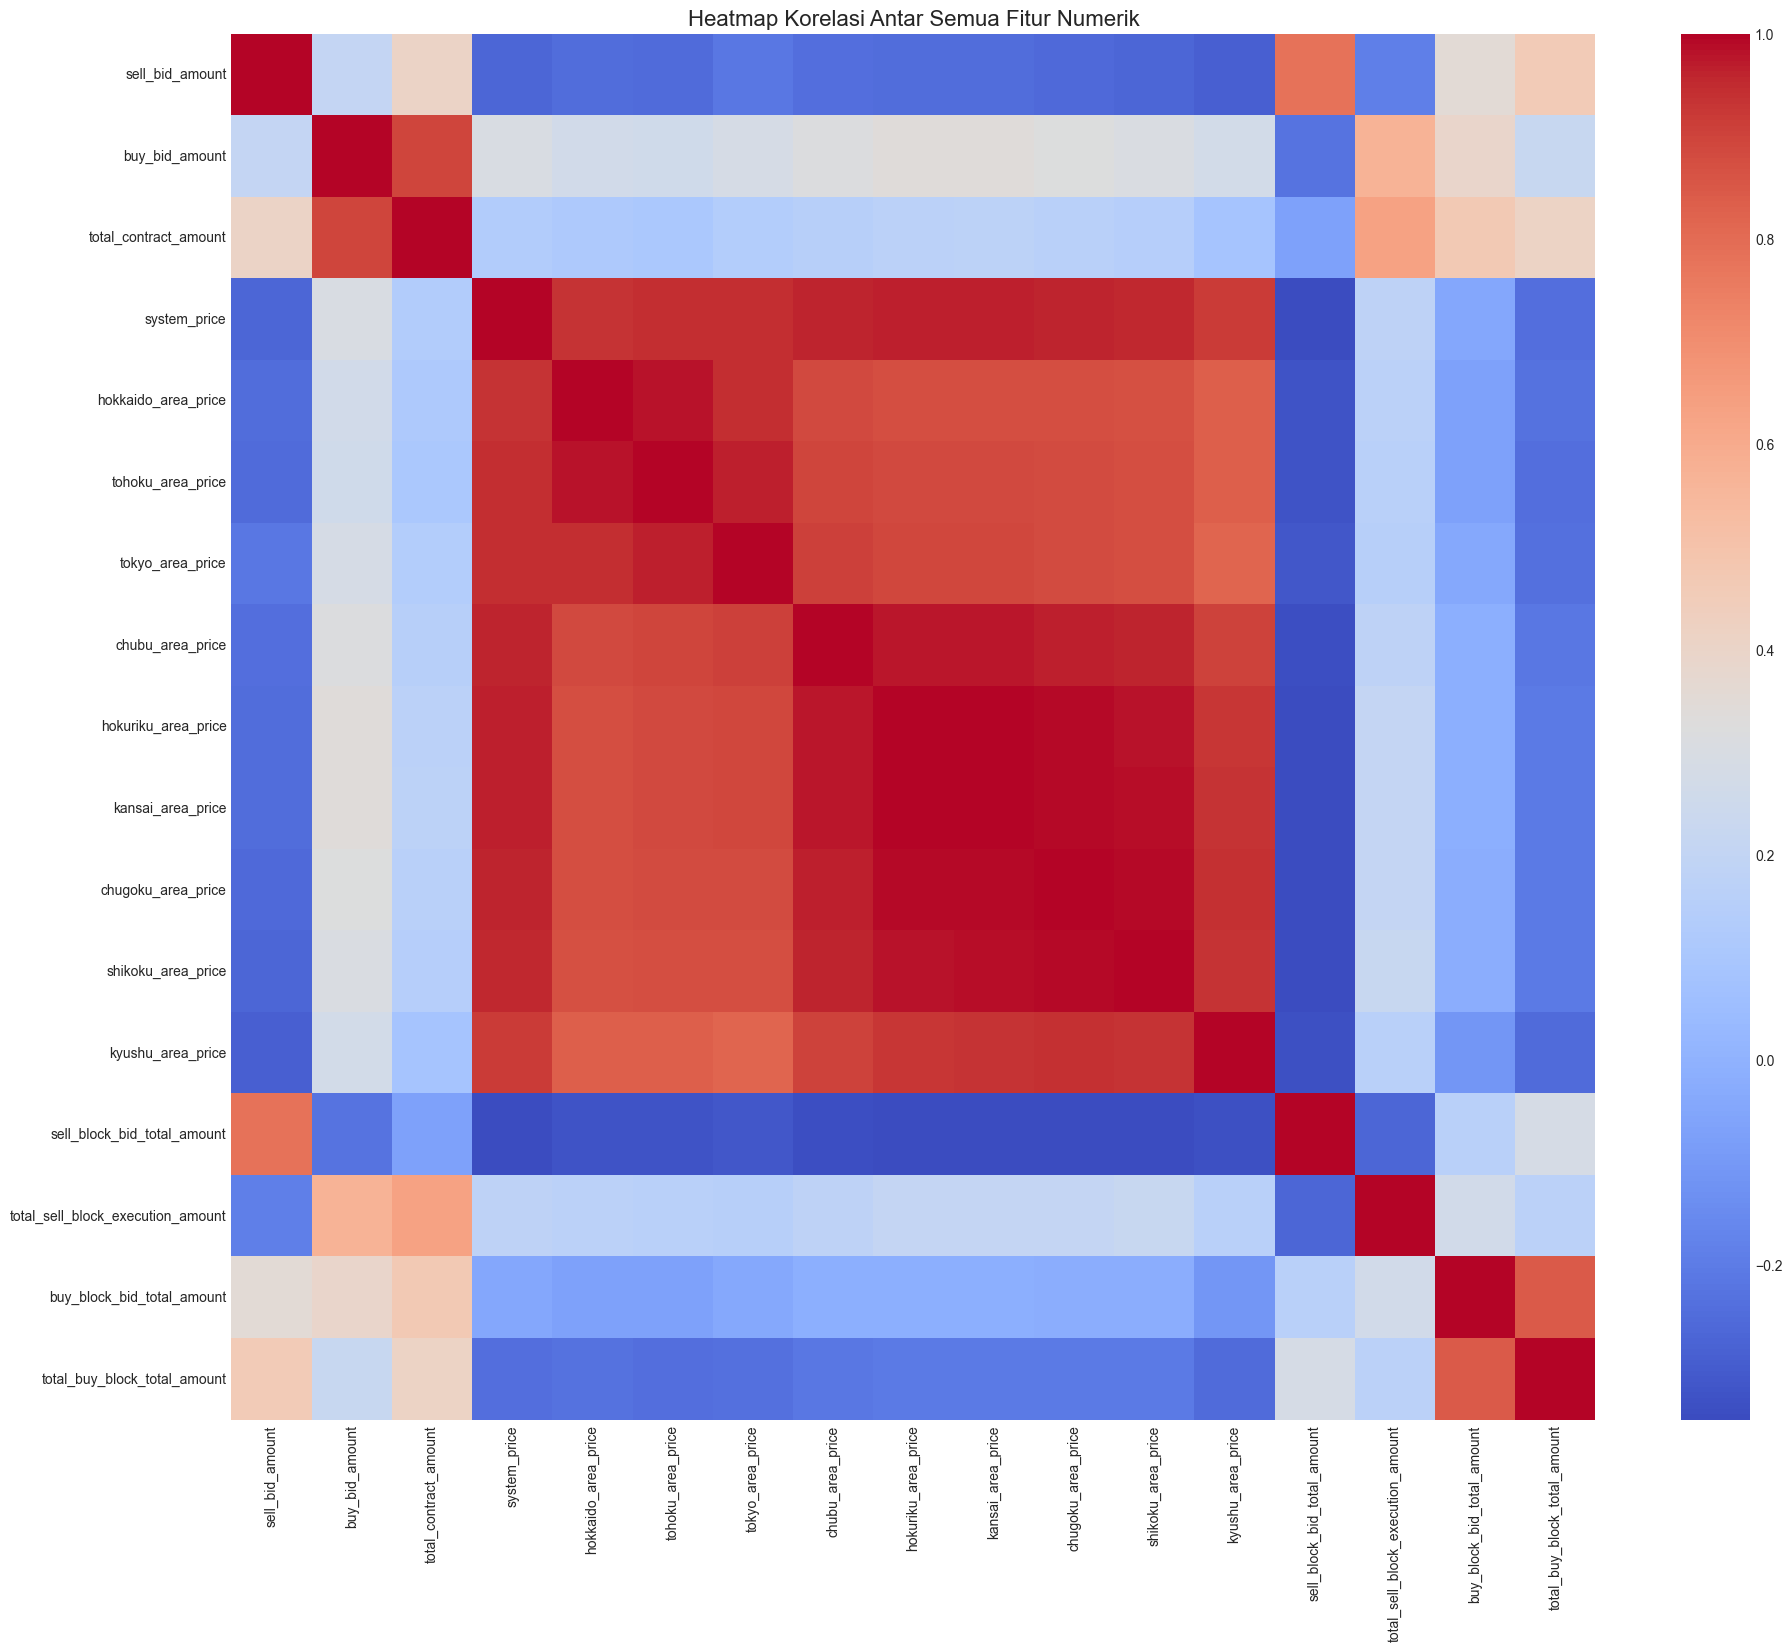

In [14]:
# Menghitung matriks korelasi untuk semua fitur
# Kita hanya akan menggunakan fitur numerik untuk korelasi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

# Menampilkan korelasi dari setiap fitur terhadap 'system_price'
# Diurutkan dari yang paling tinggi ke paling rendah
print(f"\nKorelasi Fitur terhadap Target ({TARGET}):")
target_correlation = correlation_matrix[TARGET].sort_values(ascending=False)
print(target_correlation)

# Visualisasi matriks korelasi dengan heatmap
# Ini membantu melihat gambaran besar hubungan antar semua variabel
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False agar tidak terlalu ramai
plt.title('Heatmap Korelasi Antar Semua Fitur Numerik', fontsize=16)
plt.show()

In [15]:
TARGET = 'tokyo_area_price'


--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---


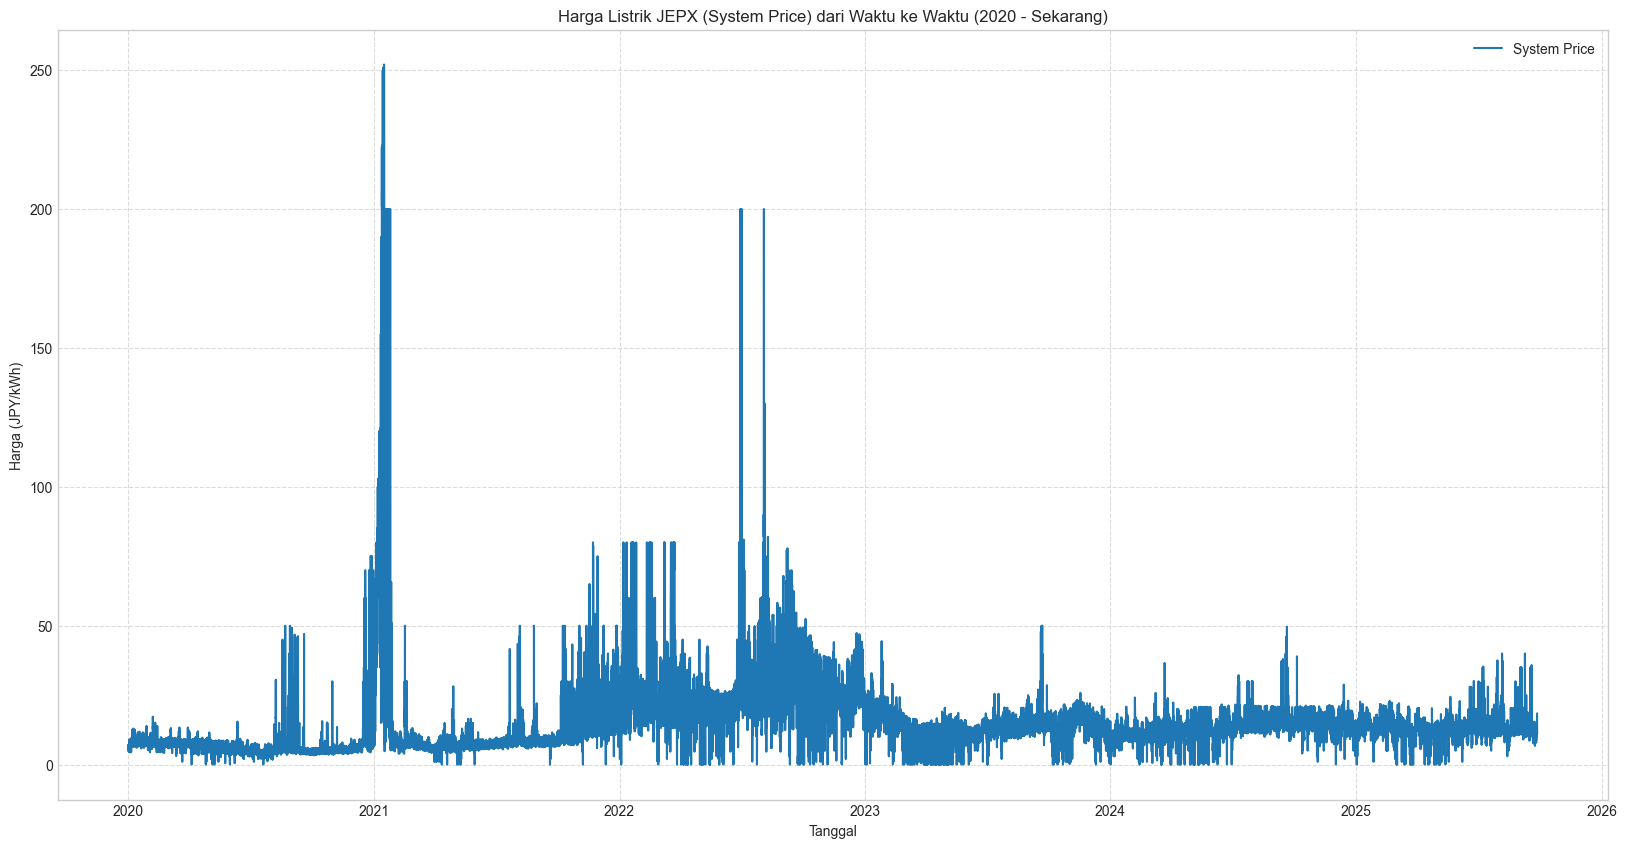


--- Plot Dekomposisi Musiman (Tahun 2022) ---


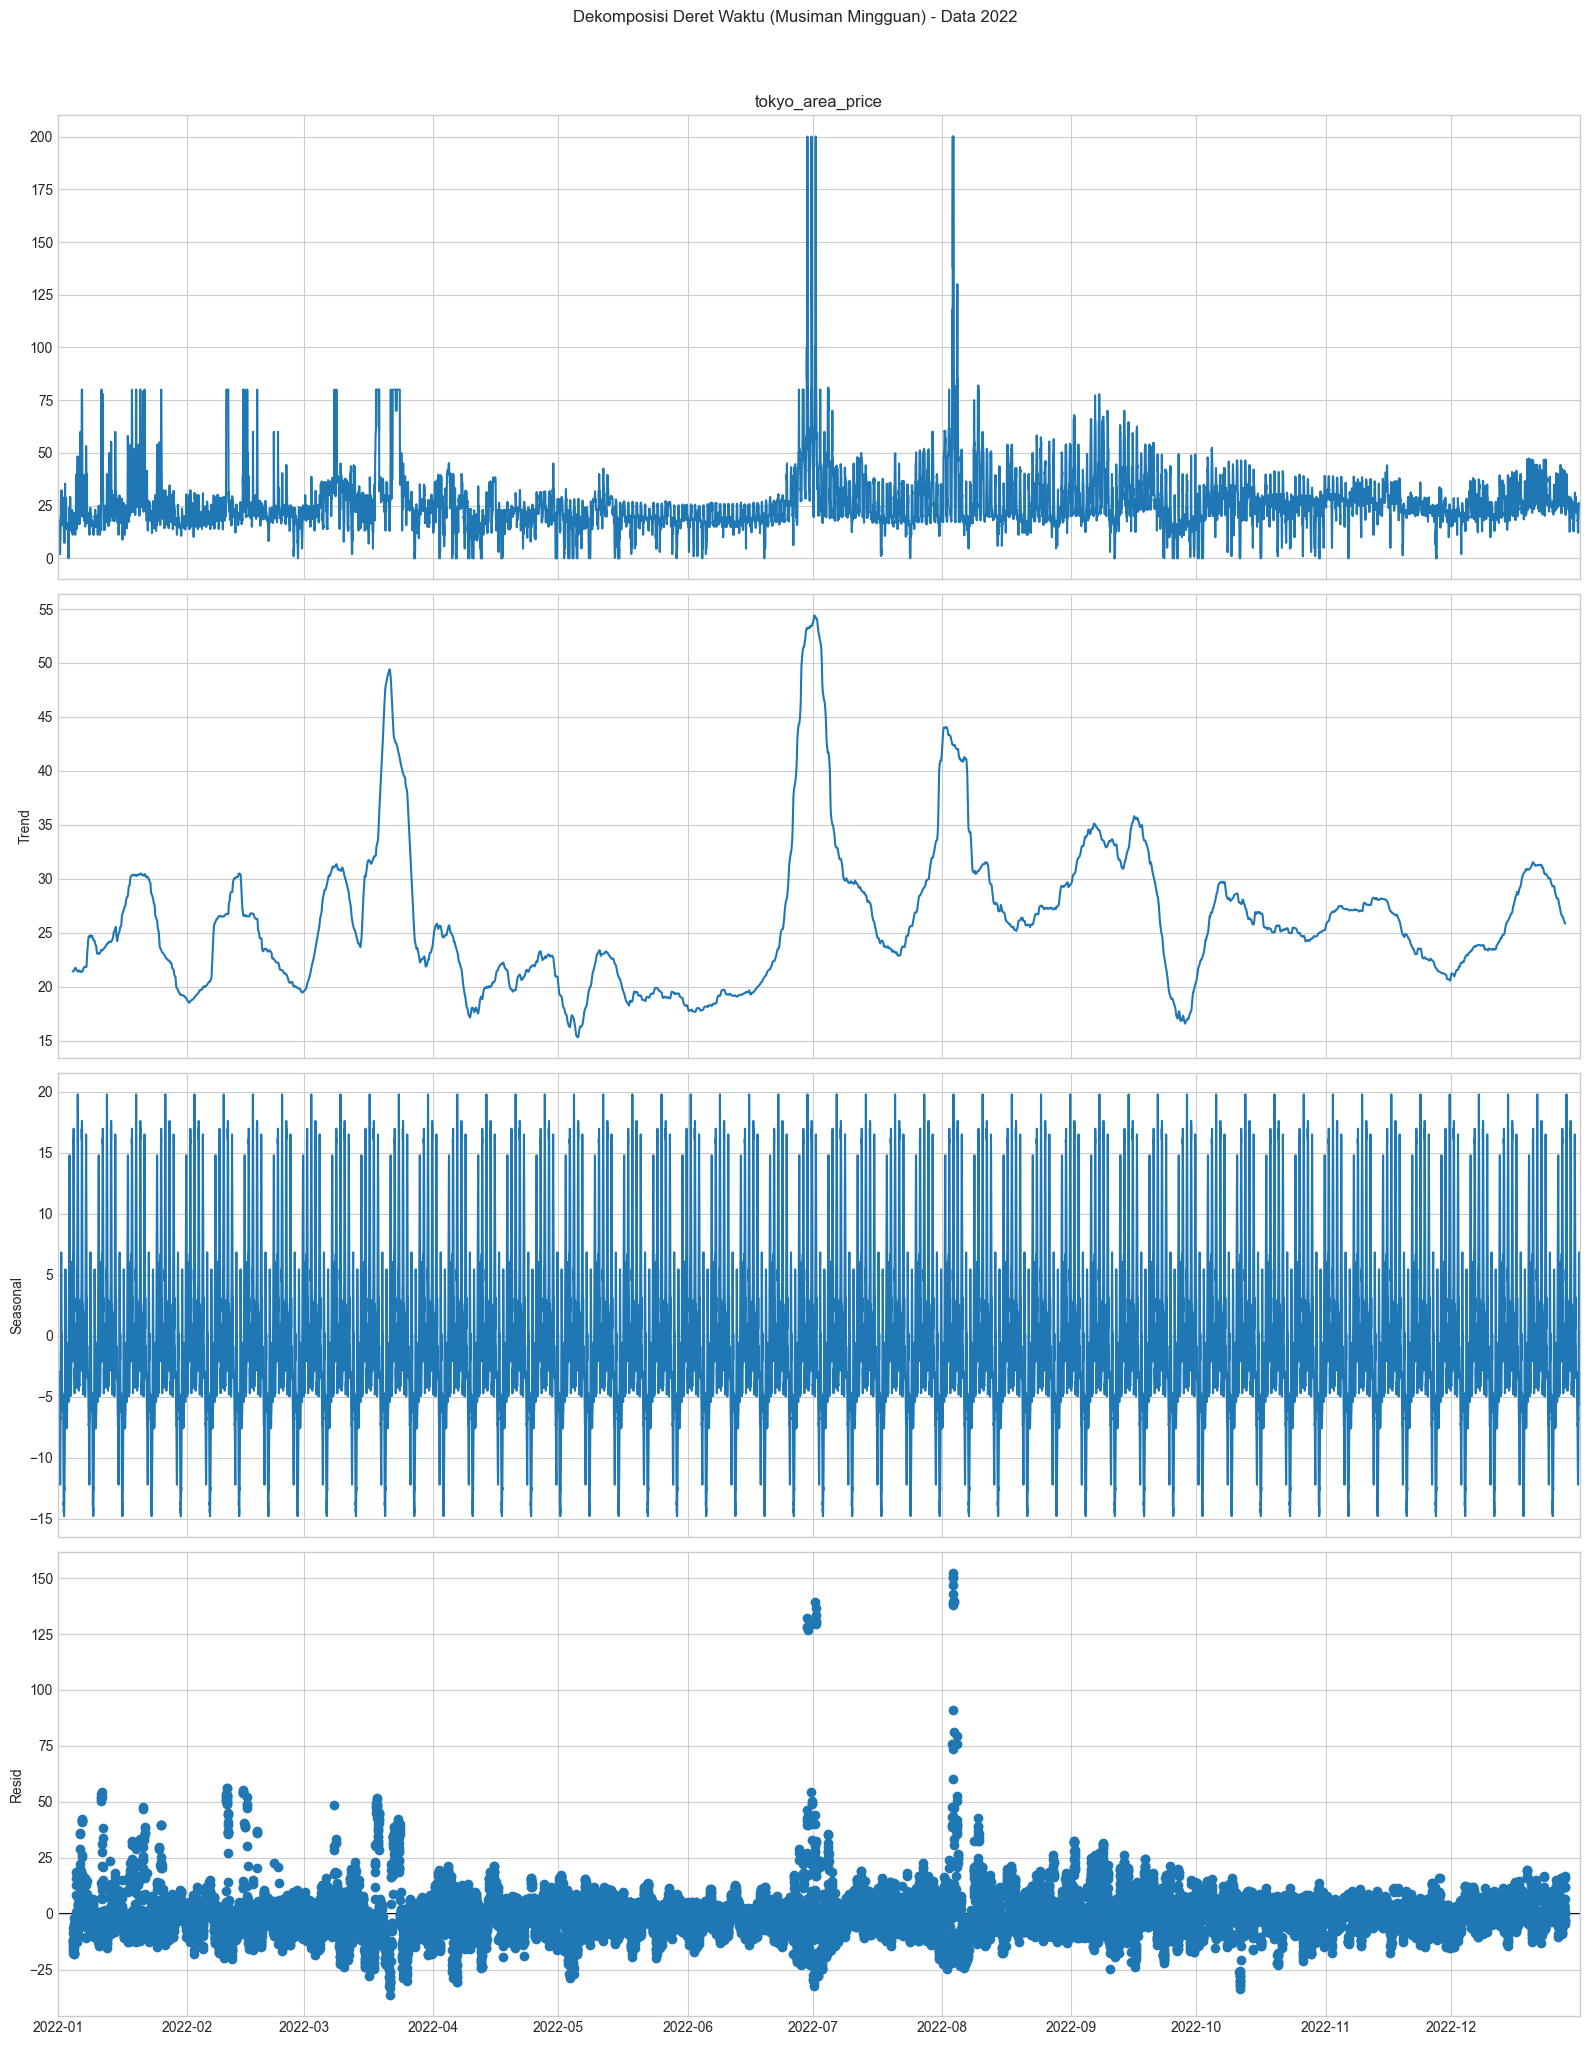


--- Box Plot Musiman ---


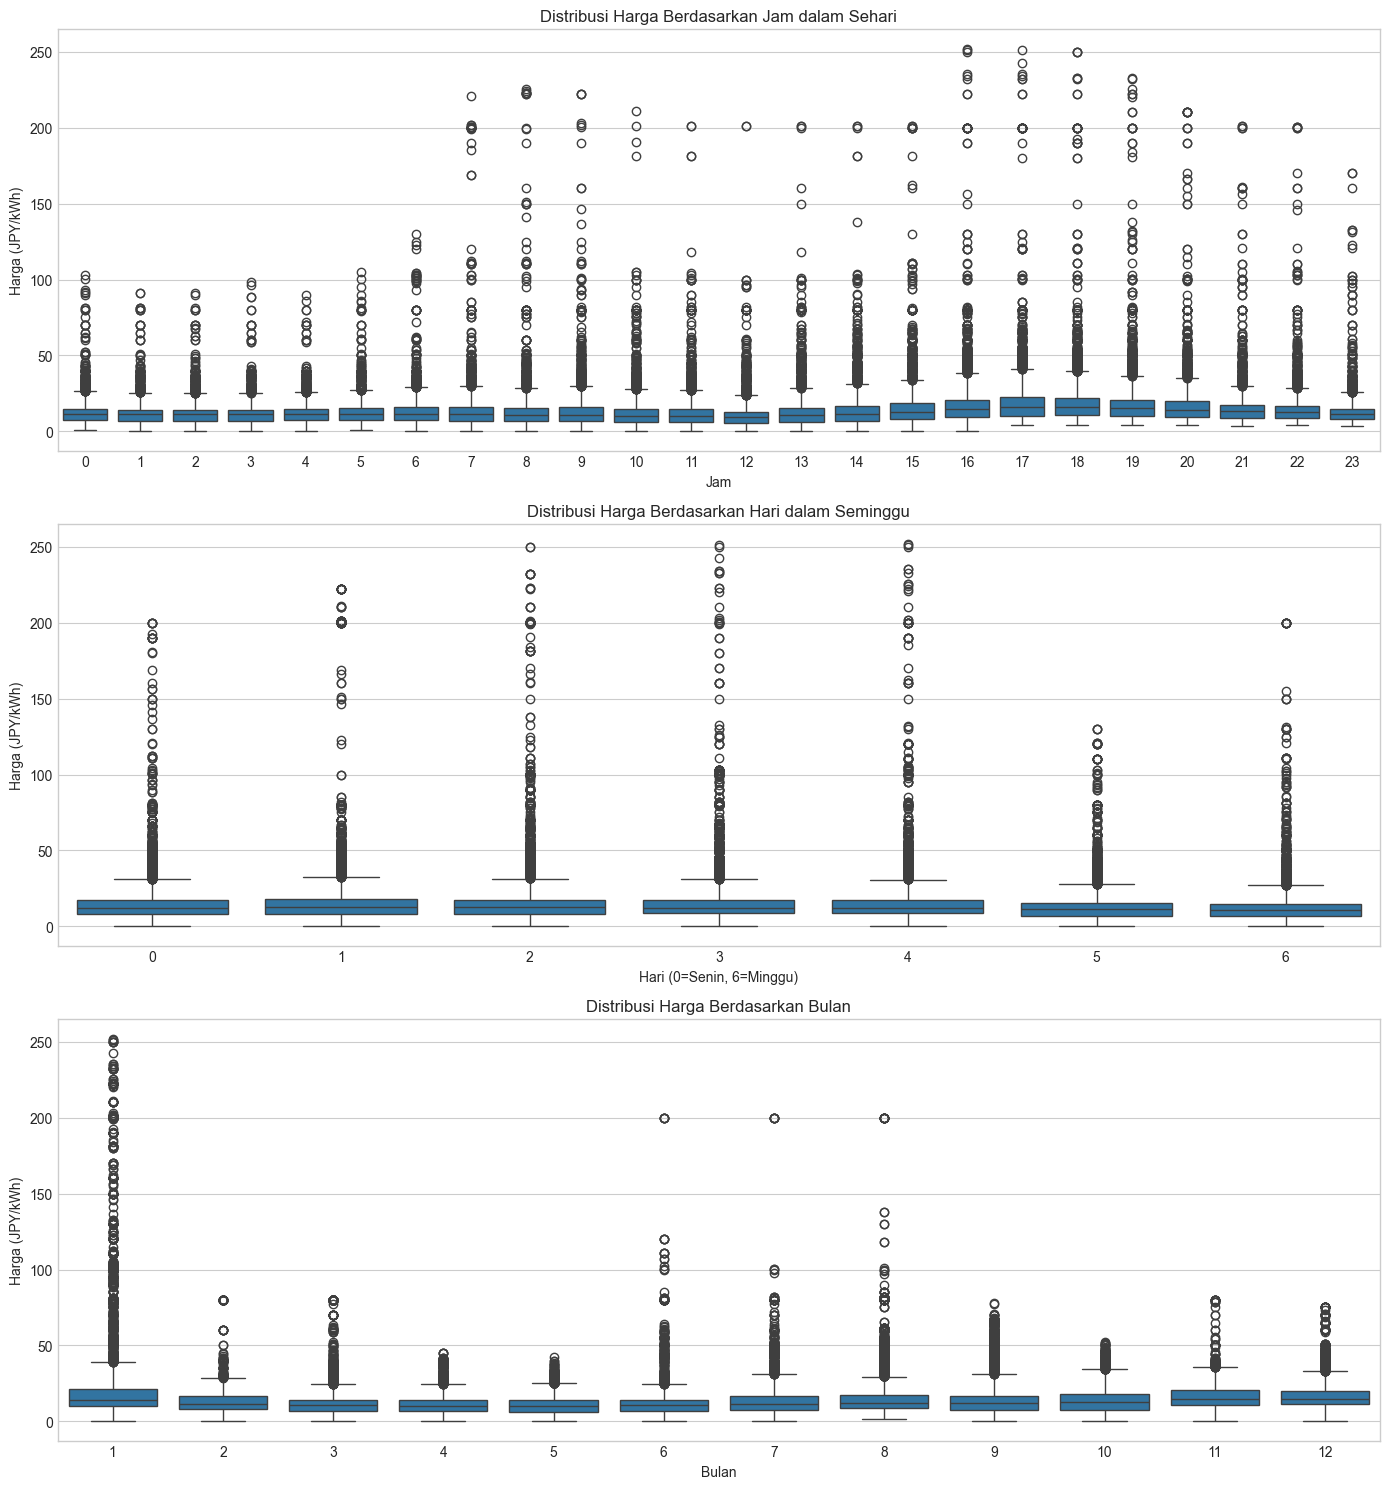

In [11]:
# TAHAP 1: ANALISIS DATA EKSPLORASI (EDA)

print("\n--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---")

# 1.1. Visualisasi Data Awal

# Plot Deret Waktu Keseluruhan
plt.figure(figsize=(20, 10))
plt.plot(df.index, df[TARGET], label='System Price')
plt.title('Harga Listrik JEPX (System Price) dari Waktu ke Waktu (2020 - Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (JPY/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---
# Catatan: Untuk Dekomposisi Musiman, period=48*7 (48 titik per hari * 7 hari) adalah musiman mingguan
# Menggunakan data dari tahun 2022
if '2022' in df.index:
    print("\n--- Plot Dekomposisi Musiman (Tahun 2022) ---")
    result_decompose = seasonal_decompose(df[TARGET]['2022'], model='additive', period=48*7)
    fig = result_decompose.plot()
    fig.set_size_inches(16, 20)
    plt.suptitle('Dekomposisi Deret Waktu (Musiman Mingguan) - Data 2022', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak cukup data untuk dekomposisi tahun 2022, melompati plot dekomposisi.")


# ---

# Box Plot Musiman untuk melihat pola harian, mingguan, dan bulanan
print("\n--- Box Plot Musiman ---")
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

# Pola Harian (berdasarkan jam)
sns.boxplot(x=df.index.hour, y=df[TARGET], ax=axes[0]) # Menggunakan axes[0]
axes[0].set_title('Distribusi Harga Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Harga (JPY/kWh)')

# Pola Mingguan (berdasarkan hari)
sns.boxplot(x=df.index.dayofweek, y=df[TARGET], ax=axes[1]) # Menggunakan axes[1]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[1].set_title('Distribusi Harga Berdasarkan Hari dalam Seminggu')
axes[1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[1].set_ylabel('Harga (JPY/kWh)')

# Pola Tahunan (berdasarkan bulan)
sns.boxplot(x=df.index.month, y=df[TARGET], ax=axes[2]) # Menggunakan axes[2]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[2].set_title('Distribusi Harga Berdasarkan Bulan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Harga (JPY/kWh)')

plt.tight_layout()
plt.show()

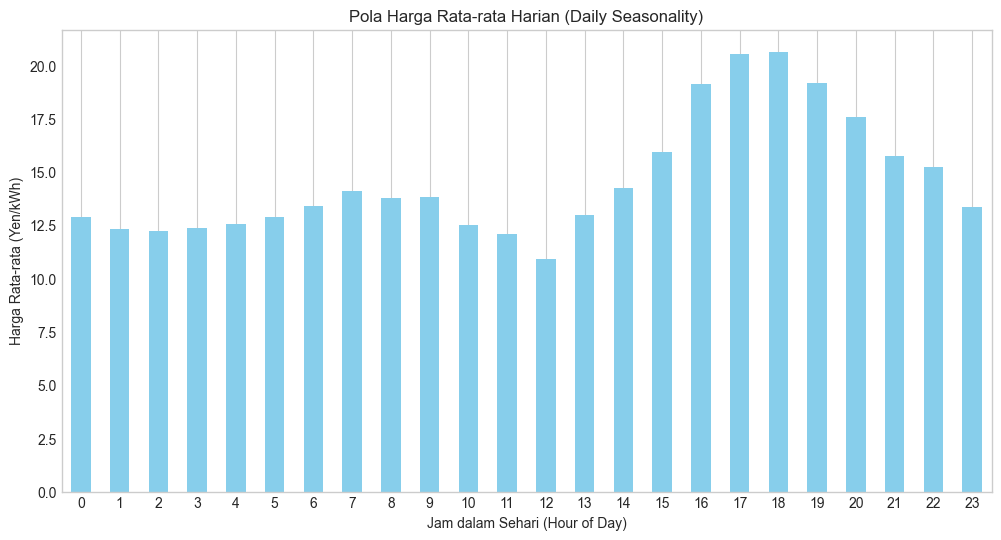

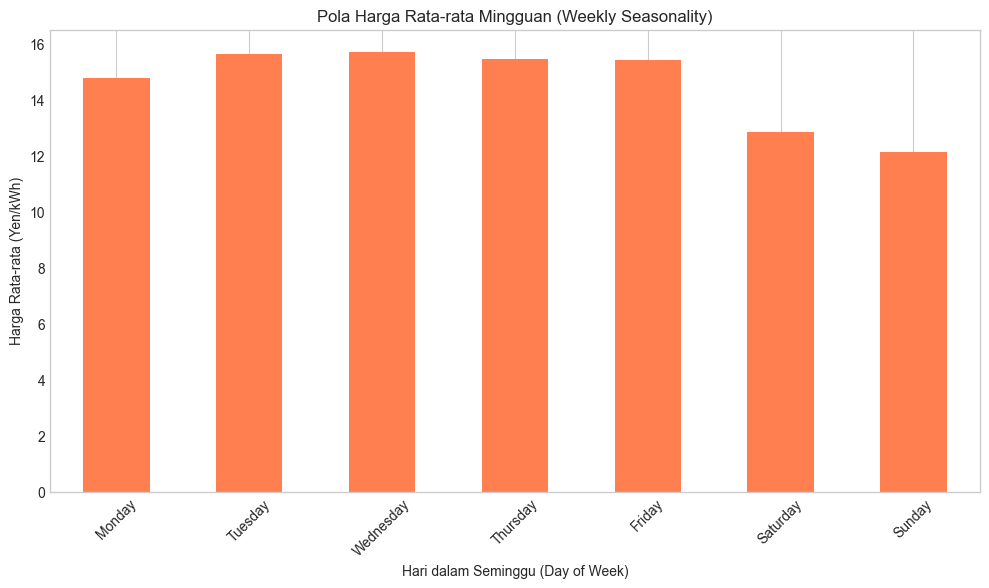

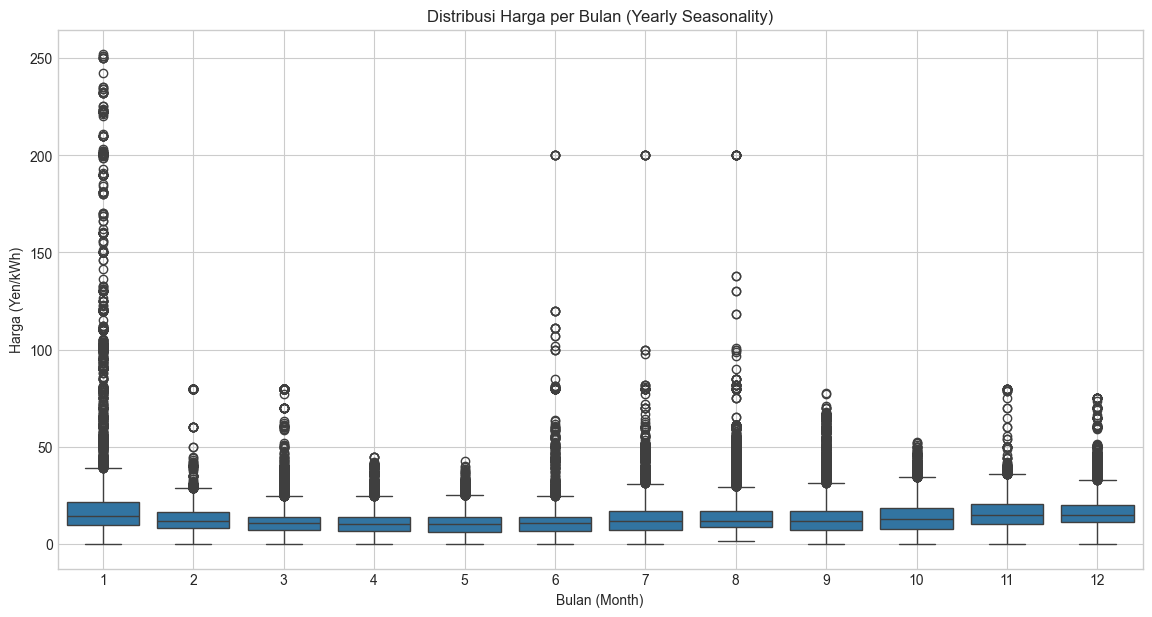

In [12]:
# --- Analisis Musiman Harian (Daily Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan data berdasarkan jam dan menghitung harga rata-rata
hourly_seasonality = df.groupby(df.index.hour)[TARGET].mean()
hourly_seasonality.plot(kind='bar', color='skyblue')
plt.title('Pola Harga Rata-rata Harian (Daily Seasonality)')
plt.xlabel('Jam dalam Sehari (Hour of Day)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Mingguan (Weekly Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan berdasarkan nama hari dan menghitung harga rata-rata
weekly_seasonality = df.groupby(df.index.day_name())[TARGET].mean()
# Mengurutkan hari agar sesuai urutan kalender
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_seasonality = weekly_seasonality.reindex(day_order)
weekly_seasonality.plot(kind='bar', color='coral')
plt.title('Pola Harga Rata-rata Mingguan (Weekly Seasonality)')
plt.xlabel('Hari dalam Seminggu (Day of Week)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Tahunan (Yearly/Monthly Seasonality) ---
plt.figure(figsize=(14, 7))
# Menggunakan boxplot untuk melihat distribusi harga setiap bulan
sns.boxplot(x=df.index.month, y=df[TARGET])
plt.title('Distribusi Harga per Bulan (Yearly Seasonality)')
plt.xlabel('Bulan (Month)')
plt.ylabel('Harga (Yen/kWh)')
plt.grid(True)
plt.show()


Korelasi Fitur terhadap Target (tokyo_area_price):
tokyo_area_price                     1.000000
tohoku_area_price                    0.963687
system_price                         0.946230
hokkaido_area_price                  0.944731
chubu_area_price                     0.906852
hokuriku_area_price                  0.892337
kansai_area_price                    0.891825
chugoku_area_price                   0.882946
shikoku_area_price                   0.876305
kyushu_area_price                    0.819595
buy_bid_amount                       0.284335
total_sell_block_execution_amount    0.151080
total_contract_amount                0.135637
buy_block_bid_total_amount          -0.040361
sell_bid_amount                     -0.217018
total_buy_block_total_amount        -0.235138
sell_block_bid_total_amount         -0.317667
Name: tokyo_area_price, dtype: float64


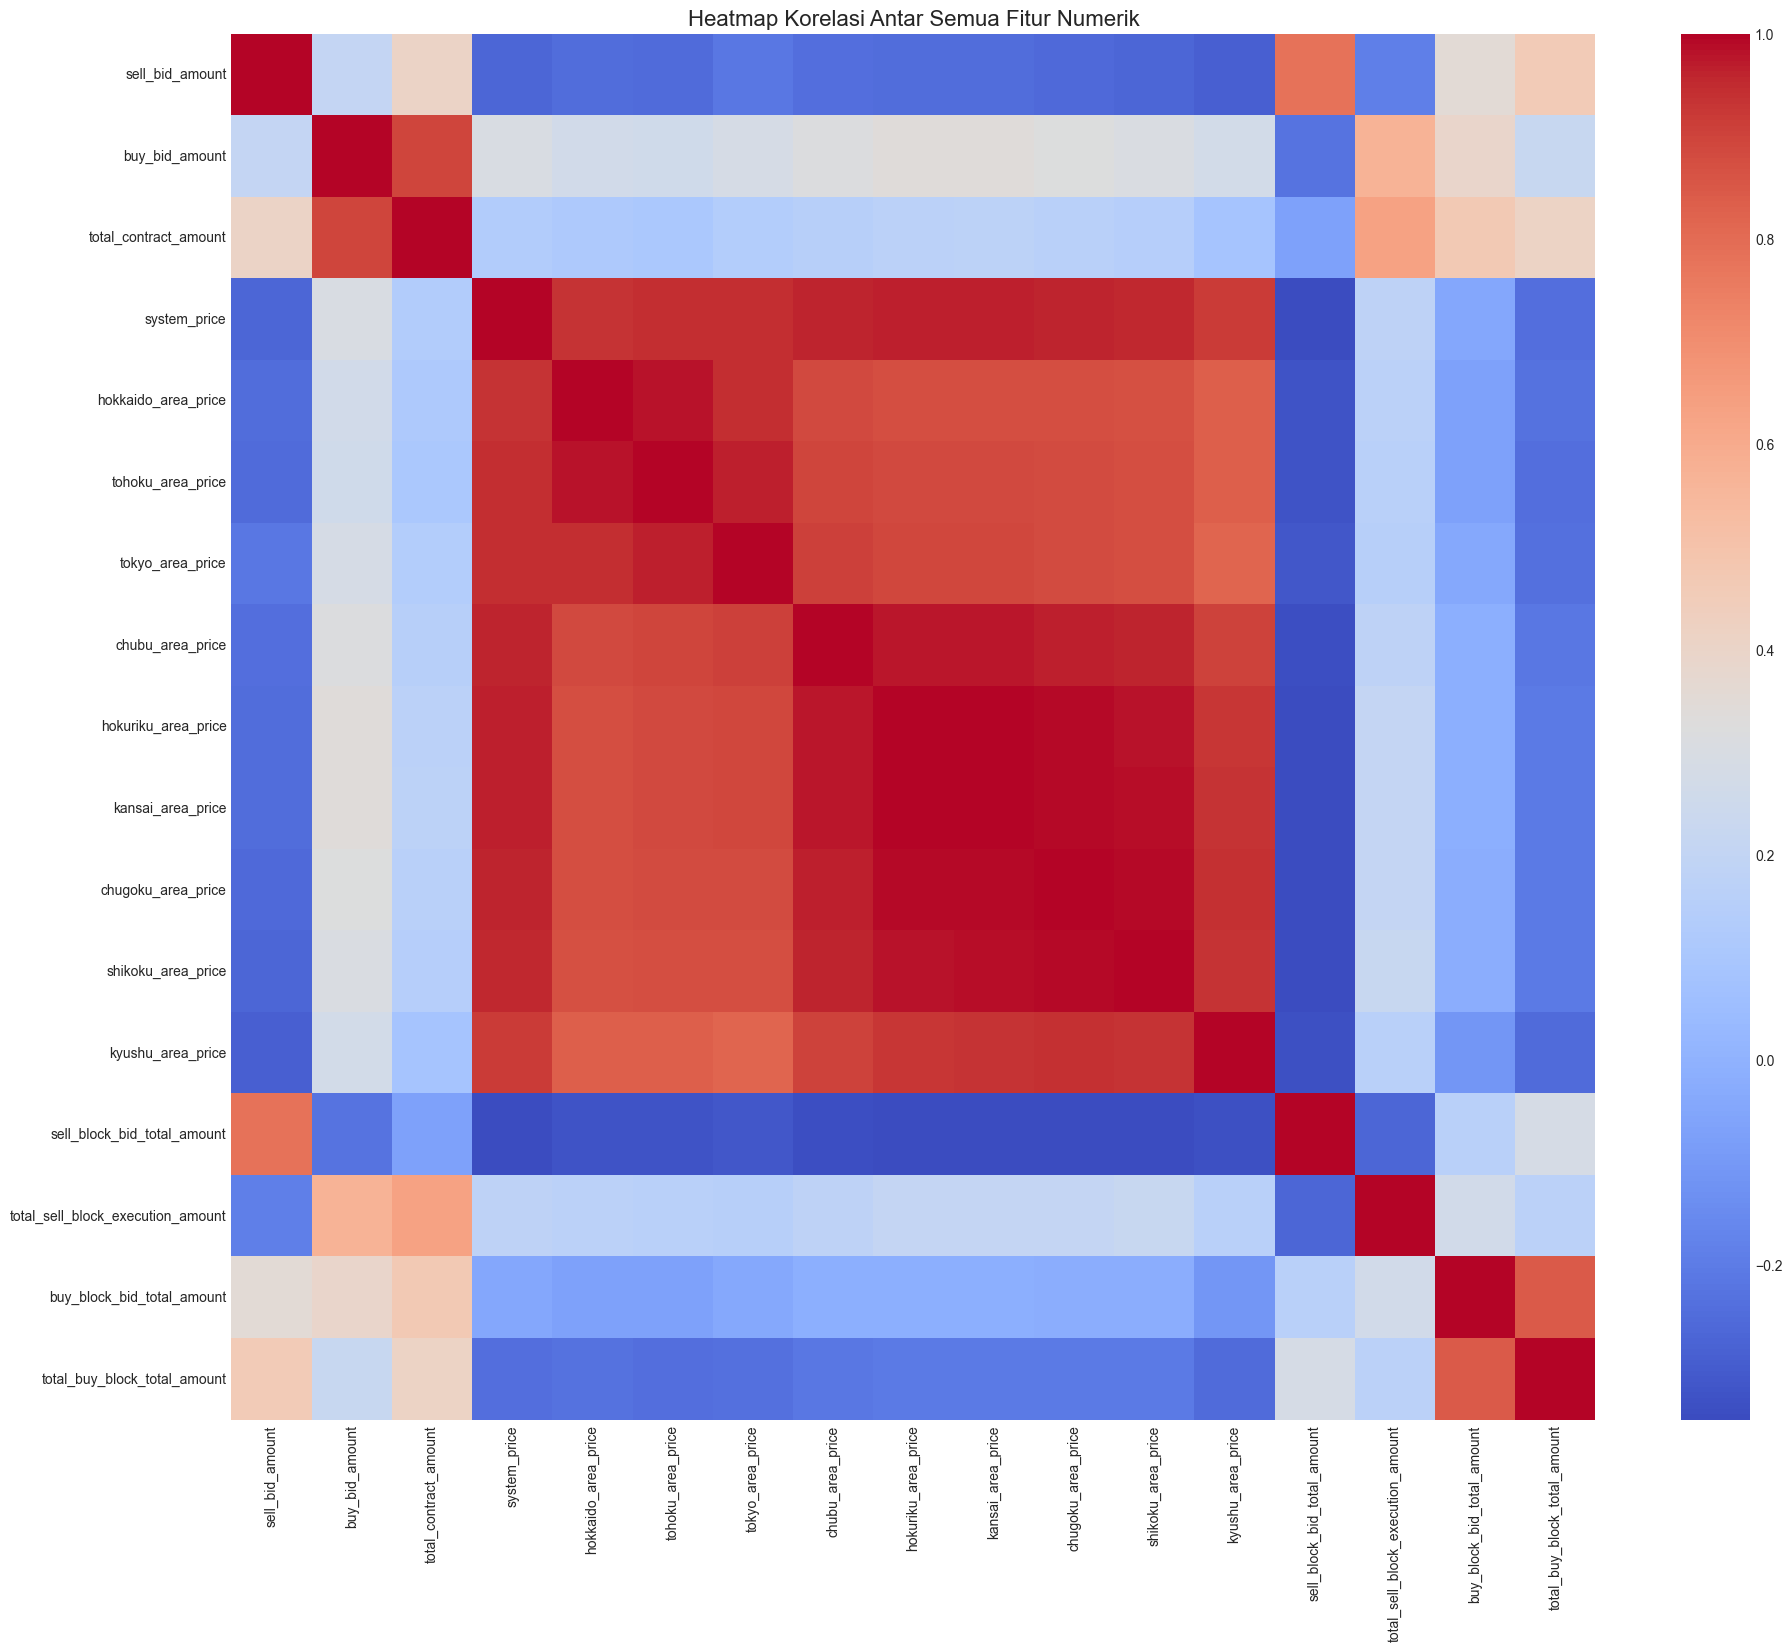

In [16]:
# Menghitung matriks korelasi untuk semua fitur
# Kita hanya akan menggunakan fitur numerik untuk korelasi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

# Menampilkan korelasi dari setiap fitur terhadap 'system_price'
# Diurutkan dari yang paling tinggi ke paling rendah
print(f"\nKorelasi Fitur terhadap Target ({TARGET}):")
target_correlation = correlation_matrix[TARGET].sort_values(ascending=False)
print(target_correlation)

# Visualisasi matriks korelasi dengan heatmap
# Ini membantu melihat gambaran besar hubungan antar semua variabel
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False agar tidak terlalu ramai
plt.title('Heatmap Korelasi Antar Semua Fitur Numerik', fontsize=16)
plt.show()

In [44]:
# --- 4. Rekayasa Fitur untuk Model Machine Learning ---
def create_features(df):
    """
    Membuat fitur berbasis waktu dari datetime index.
    """
    df_copy = df.copy()
    df_copy['hour'] = df_copy.index.hour
    df_copy['day_of_week'] = df_copy.index.dayofweek # Senin=0, Minggu=6
    df_copy['day_of_year'] = df_copy.index.dayofyear
    df_copy['month'] = df_copy.index.month
    df_copy['quarter'] = df_copy.index.quarter
    df_copy['year'] = df_copy.index.year
    return df_copy

df_featured = create_features(df)
print("\nData dengan fitur-fitur baru:")
df_featured.head()


Data dengan fitur-fitur baru:


,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,...,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount,hour,day_of_week,day_of_year,month,quarter,year
date_time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,17030600,18224200,14612900,6.78,11.01,6.78,6.78,6.78,6.78,6.78,...,3530350.0,2354700.0,913800.0,783800.0,0,2,1,1,1,2020
2020-01-01 00:30:00,17944550,18188300,14600550,6.64,10.36,6.72,6.72,6.72,6.72,6.72,...,4241700.0,2355050.0,1096300.0,921300.0,0,2,1,1,1,2020
2020-01-01 01:00:00,19106350,18205200,14706000,6.53,10.36,6.53,6.53,6.53,6.53,6.53,...,4602150.0,2345200.0,1498800.0,1223800.0,1,2,1,1,1,2020
2020-01-01 01:30:00,19604000,18372650,14890500,6.53,9.34,6.53,6.53,6.53,6.53,6.53,...,4886350.0,2318050.0,1754800.0,1379800.0,1,2,1,1,1,2020
2020-01-01 02:00:00,19956600,18536600,15275850,6.92,9.34,6.92,6.92,6.92,6.92,6.92,...,5265350.0,2338050.0,1923800.0,1448800.0,2,2,1,1,1,2020


In [17]:
df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
date_time,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,17030600,18224200,14612900,6.78,11.01,6.78,6.78,6.78,6.78,6.78,6.78,6.78,5.41,3530350.0,2354700.0,913800.0,783800.0
2020-01-01 00:30:00,17944550,18188300,14600550,6.64,10.36,6.72,6.72,6.72,6.72,6.72,6.72,6.72,5.16,4241700.0,2355050.0,1096300.0,921300.0
2020-01-01 01:00:00,19106350,18205200,14706000,6.53,10.36,6.53,6.53,6.53,6.53,6.53,6.53,6.53,5.16,4602150.0,2345200.0,1498800.0,1223800.0
2020-01-01 01:30:00,19604000,18372650,14890500,6.53,9.34,6.53,6.53,6.53,6.53,6.53,6.53,6.53,5.16,4886350.0,2318050.0,1754800.0,1379800.0
2020-01-01 02:00:00,19956600,18536600,15275850,6.92,9.34,6.92,6.92,6.92,6.92,6.92,6.92,6.92,5.16,5265350.0,2338050.0,1923800.0,1448800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 21:30:00,23194300,20334000,14866150,11.20,15.19,11.41,11.41,11.41,9.00,9.00,9.00,9.00,9.00,7173000.0,1198500.0,1806050.0,1716050.0
2025-09-26 22:00:00,23034150,20511100,14615100,10.91,11.58,11.58,11.58,11.58,8.96,8.96,8.96,8.96,8.96,7190600.0,1119450.0,1929850.0,1739850.0
2025-09-26 22:30:00,23050450,20236750,14594650,10.58,11.20,11.20,11.20,11.20,8.63,8.63,8.63,8.63,8.63,7329400.0,1134050.0,1987550.0,1797550.0


In [21]:
df.columns

Index(['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount',
       'system_price', 'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount'],
      dtype='object')

In [41]:
def create_sliding_window_dataset(df, window_days,target):
    """
    Creates a sliding window dataset from the hourly data.
    """
    window_size_hours = window_days * 48
    day1 = [col for col in df.columns if col != target]
    df_windowed = df.copy()

    print(f"\nCreating dataset for a {window_days}-day ({window_size_hours/2}-hour) sliding window...")

    # Create lagged features for all columns in the dataframe
    for col in df.columns:
        for i in range(49, window_size_hours + 49):
            # The .shift(i) function pushes data from 'i' hours ago to the current row.
            # This creates our feature set (X) based on past data.
            df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)

    # The shifting operations create NaN values at the beginning and end of the dataframe.
    # We need to remove these rows as they cannot be used for training.
    df_windowed = df_windowed.drop(columns=day1, axis=1)
    final_df = df_windowed.dropna()

    print(f"Finished creating {window_days}-day window. Final dataset shape: {final_df.shape}")
    return final_df

df_1_ml = create_sliding_window_dataset(df, window_days=1, target='system_price')
df_2_ml = create_sliding_window_dataset(df, window_days=2, target='system_price')
df_7_ml = create_sliding_window_dataset(df, window_days=7, target='system_price')


Creating dataset for a 1-day (24.0-hour) sliding window...
Finished creating 1-day window. Final dataset shape: (100512, 817)

Creating dataset for a 2-day (48.0-hour) sliding window...
Finished creating 2-day window. Final dataset shape: (100464, 1633)

Creating dataset for a 7-day (168.0-hour) sliding window...
Finished creating 7-day window. Final dataset shape: (100224, 5713)


In [42]:
df_1_ml

,system_price,sell_bid_amount_lag_49h,sell_bid_amount_lag_50h,sell_bid_amount_lag_51h,sell_bid_amount_lag_52h,sell_bid_amount_lag_53h,sell_bid_amount_lag_54h,sell_bid_amount_lag_55h,sell_bid_amount_lag_56h,sell_bid_amount_lag_57h,...,total_buy_block_total_amount_lag_87h,total_buy_block_total_amount_lag_88h,total_buy_block_total_amount_lag_89h,total_buy_block_total_amount_lag_90h,total_buy_block_total_amount_lag_91h,total_buy_block_total_amount_lag_92h,total_buy_block_total_amount_lag_93h,total_buy_block_total_amount_lag_94h,total_buy_block_total_amount_lag_95h,total_buy_block_total_amount_lag_96h
date_time,,,,,,,,,,,,,,,,,,,,,
2020-01-03 00:00:00,6.48,20795050.0,22797100.0,23808200.0,24165300.0,24115050.0,23554850.0,23444100.0,22997550.0,23749600.0,...,1629800.0,1574300.0,1739300.0,1669300.0,1561300.0,1448800.0,1379800.0,1223800.0,921300.0,783800.0
2020-01-03 00:30:00,6.40,17312300.0,20795050.0,22797100.0,23808200.0,24165300.0,24115050.0,23554850.0,23444100.0,22997550.0,...,1688800.0,1629800.0,1574300.0,1739300.0,1669300.0,1561300.0,1448800.0,1379800.0,1223800.0,921300.0
2020-01-03 01:00:00,6.19,18429550.0,17312300.0,20795050.0,22797100.0,23808200.0,24165300.0,24115050.0,23554850.0,23444100.0,...,1628800.0,1688800.0,1629800.0,1574300.0,1739300.0,1669300.0,1561300.0,1448800.0,1379800.0,1223800.0
2020-01-03 01:30:00,6.19,19460600.0,18429550.0,17312300.0,20795050.0,22797100.0,23808200.0,24165300.0,24115050.0,23554850.0,...,1589300.0,1628800.0,1688800.0,1629800.0,1574300.0,1739300.0,1669300.0,1561300.0,1448800.0,1379800.0
2020-01-03 02:00:00,6.16,19890000.0,19460600.0,18429550.0,17312300.0,20795050.0,22797100.0,23808200.0,24165300.0,24115050.0,...,1600000.0,1589300.0,1628800.0,1688800.0,1629800.0,1574300.0,1739300.0,1669300.0,1561300.0,1448800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 21:30:00,11.20,23887800.0,23948350.0,23749650.0,24243500.0,23674600.0,23800300.0,23358500.0,23329400.0,23565200.0,...,1281500.0,1343500.0,1333600.0,1214850.0,1037600.0,743100.0,1071550.0,1320300.0,1372300.0,1239300.0
2025-09-26 22:00:00,10.91,24218050.0,23887800.0,23948350.0,23749650.0,24243500.0,23674600.0,23800300.0,23358500.0,23329400.0,...,1384000.0,1281500.0,1343500.0,1333600.0,1214850.0,1037600.0,743100.0,1071550.0,1320300.0,1372300.0
2025-09-26 22:30:00,10.58,23772950.0,24218050.0,23887800.0,23948350.0,23749650.0,24243500.0,23674600.0,23800300.0,23358500.0,...,1498300.0,1384000.0,1281500.0,1343500.0,1333600.0,1214850.0,1037600.0,743100.0,1071550.0,1320300.0


In [67]:
def split_data(df, target, test_size=0.1):
    """
    Splits the dataframe into training and testing sets.
    """
    train_data = df.iloc[:-int(test_size * len(df))]
    test_data = df.iloc[-int(test_size * len(df)):]
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]
    return X_train, y_train, X_test, y_test

X_train_1, y_train_1, X_test_1, y_test_1 = split_data(df_1_ml, target='system_price')
X_train_2, y_train_2, X_test_2, y_test_2 = split_data(df_2_ml, target='system_price')
X_train_7, y_train_7, X_test_7, y_test_7 = split_data(df_7_ml, target='system_price')

In [28]:
y_test_1

date_time
2024-08-04 00:00:00    12.49
2024-08-04 00:30:00    11.93
2024-08-04 01:00:00    11.90
2024-08-04 01:30:00    11.52
2024-08-04 02:00:00    11.47
                       ...  
2025-09-26 21:30:00    11.20
2025-09-26 22:00:00    10.91
2025-09-26 22:30:00    10.58
2025-09-26 23:00:00    10.32
2025-09-26 23:30:00     9.30
Name: system_price, Length: 20112, dtype: float64

In [68]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=5)
print("Training Random Forest model...")
rf_model.fit(X_train_1, y_train_1)
print("Training complete.")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test_1)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test_1, rf_predictions))
rf_mae = mean_absolute_error(y_test_1, rf_predictions)

print(f"\nRandom Forest Model Performance:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

Training Random Forest model...
Training complete.

Random Forest Model Performance:
RMSE: 2.8817
MAE: 1.9407


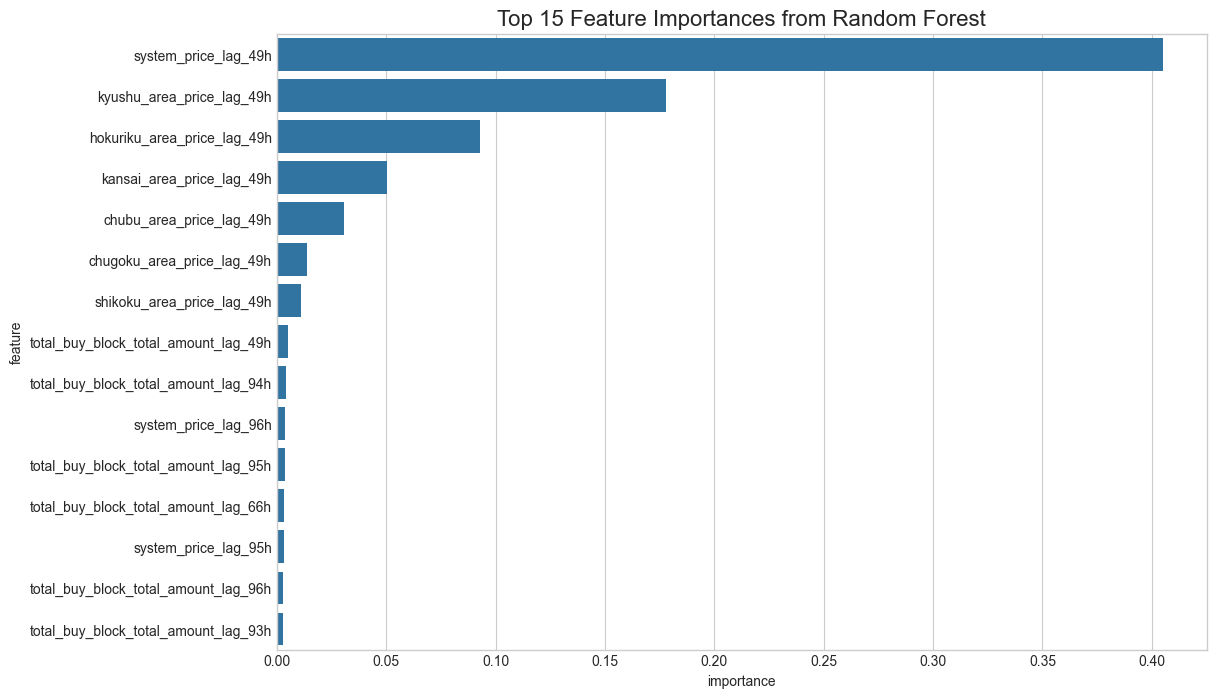

In [69]:
# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train_1.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.show()

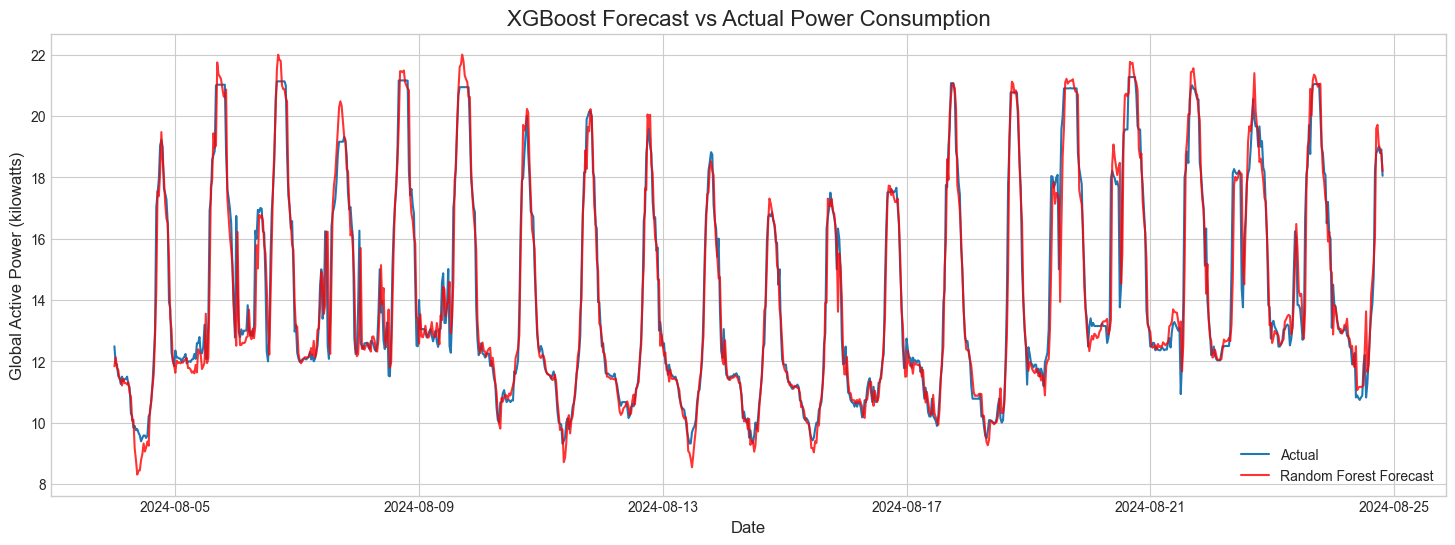

In [34]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_1[:1000].index, y_test_1[:1000], label='Actual')
plt.plot(y_test_1[:1000].index, rf_predictions[:1000], color='red', label='Random Forest Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)
plt.legend()
plt.show()

In [70]:
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1, objective='reg:squarederror')
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_1, y_train_1,
                eval_set=[(X_test_1, y_test_1)]) # Corrected the call to fit
print("Training complete.")

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test_1)

# Evaluate the model
xgb_rmse = np.sqrt(mean_squared_error(y_test_1, xgb_predictions))
xgb_mae = mean_absolute_error(y_test_1, xgb_predictions)

print(f"\nXGBoost Model Performance:")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE: {xgb_mae:.4f}")


Training XGBoost model...
[0]	validation_0-rmse:4.79241
[1]	validation_0-rmse:4.64589
[2]	validation_0-rmse:4.50854
[3]	validation_0-rmse:4.38009
[4]	validation_0-rmse:4.26102
[5]	validation_0-rmse:4.14943
[6]	validation_0-rmse:4.04934
[7]	validation_0-rmse:3.95582
[8]	validation_0-rmse:3.87013
[9]	validation_0-rmse:3.78960
[10]	validation_0-rmse:3.71539
[11]	validation_0-rmse:3.64864
[12]	validation_0-rmse:3.58949
[13]	validation_0-rmse:3.53154
[14]	validation_0-rmse:3.48080
[15]	validation_0-rmse:3.43374
[16]	validation_0-rmse:3.39021
[17]	validation_0-rmse:3.34887
[18]	validation_0-rmse:3.31342
[19]	validation_0-rmse:3.28101
[20]	validation_0-rmse:3.25386
[21]	validation_0-rmse:3.22825
[22]	validation_0-rmse:3.20295
[23]	validation_0-rmse:3.18303
[24]	validation_0-rmse:3.16293
[25]	validation_0-rmse:3.14555
[26]	validation_0-rmse:3.13120
[27]	validation_0-rmse:3.12023
[28]	validation_0-rmse:3.10945
[29]	validation_0-rmse:3.09799
[30]	validation_0-rmse:3.08593
[31]	validation_0-rmse

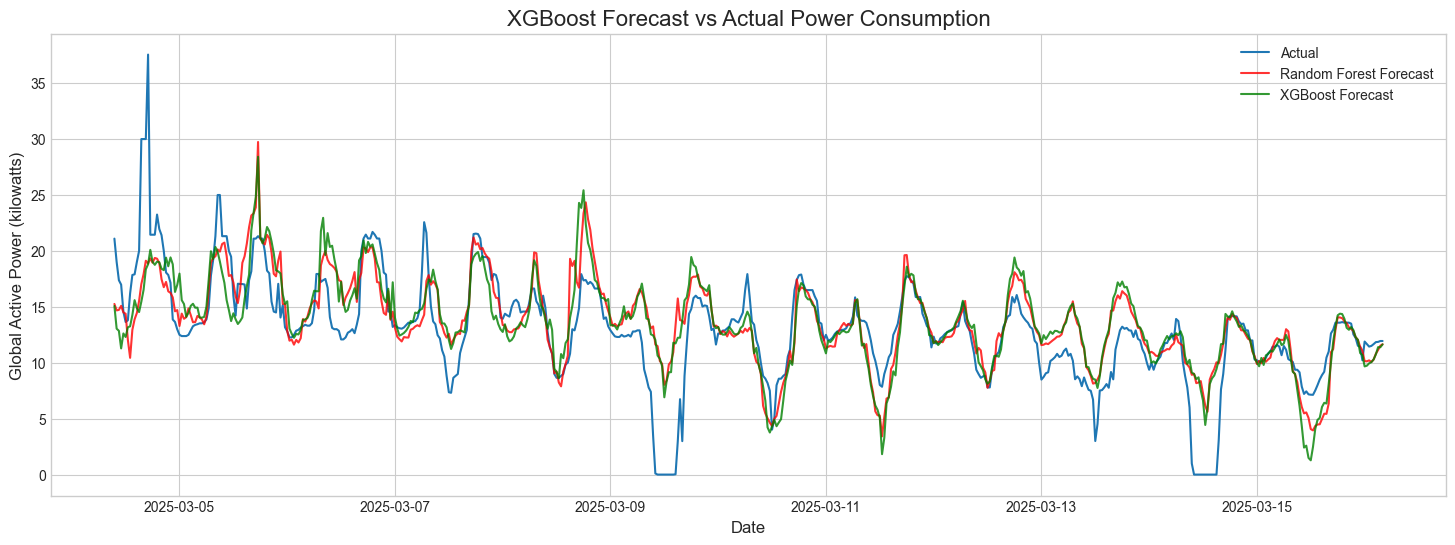

In [102]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_1[134:700].index, y_test_1[134:700], label='Actual')
plt.plot(y_test_1[134:700].index, rf_predictions[134:700], color='red', label='Random Forest Forecast', alpha=0.8)
plt.plot(y_test_1[134:700].index, xgb_predictions[134:700], color='green', label='XGBoost Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)
plt.legend()
plt.show()

In [93]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# no random state for time series

X_train, X_val, y_train, y_val = train_test_split(df.drop(columns=['system_price']), df['system_price'], test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, shuffle=False)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=48):
    Xs, ys = [], []
    # The loop must stop earlier to account for the lag
    for i in range(49, len(X) - (2 * time_steps - 1)):
        # The input sequence is the same
        v = X[i:(i + time_steps)]
        Xs.append(v)
        
        # The target is now time_steps ahead of the end of the sequence
        target_idx = i + 2 * time_steps - 1
        ys.append(y[target_idx])
        
    return np.array(Xs), np.array(ys)

TIME_STEPS = 48

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print("Data prepared for RNN models.")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

Data prepared for RNN models.
X_train_seq shape: (80342, 48, 16)
y_train_seq shape: (80342, 1)


In [57]:
X_train_seq

array([[[0.18482521, 0.33777277, 0.360517  , ..., 0.40643478,
         0.23027497, 0.18593749],
        [0.2169749 , 0.34185573, 0.36537186, ..., 0.40278835,
         0.27442745, 0.21798902],
        [0.23036423, 0.34023854, 0.36544126, ..., 0.3969089 ,
         0.28792447, 0.21706223],
        ...,
        [0.29757283, 0.35633041, 0.35965088, ..., 0.46811465,
         0.17966114, 0.15419489],
        [0.24116082, 0.3309319 , 0.35215655, ..., 0.46553873,
         0.12014502, 0.12878536],
        [0.16273936, 0.31566253, 0.32189908, ..., 0.40982194,
         0.1076531 , 0.10808703]],

       [[0.2169749 , 0.34185573, 0.36537186, ..., 0.40278835,
         0.27442745, 0.21798902],
        [0.23036423, 0.34023854, 0.36544126, ..., 0.3969089 ,
         0.28792447, 0.21706223],
        [0.24576165, 0.34116017, 0.37338278, ..., 0.39431625,
         0.29424223, 0.23389893],
        ...,
        [0.24116082, 0.3309319 , 0.35215655, ..., 0.46553873,
         0.12014502, 0.12878536],
        [0.1

In [113]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

def Bilstm_model(input_shape):
    inputs = Input(shape=input_shape)
    # x = Dense(128, activation='relu')(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    # x = Dropout(0.1)(x)
    # x = Dense(64, activation='relu')(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    # x = Dropout(0.1)(x)
    # x = tf.keras.layers.Flatten()(x)
    x = Bidirectional(LSTM(32, return_sequences=False))(x)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizer, loss='mse')
    return model

model = Bilstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 48, 16)]          0         
                                                                 
 bidirectional_6 (Bidirectio  (None, 48, 256)          148480    
 nal)                                                            
                                                                 
 bidirectional_7 (Bidirectio  (None, 48, 128)          164352    
 nal)                                                            
                                                                 
 bidirectional_8 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense_9 (Dense)             (None, 1)                 65        
                                                           

In [114]:
# Train the LSTM model
print("\nTraining LSTM model...")
lstm_history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    shuffle=False
)
print("Training complete.")

# Make predictions
lstm_predictions_scaled = model.predict(X_test_seq)
# Inverse transform predictions to original scale
lstm_predictions = target_scaler.inverse_transform(lstm_predictions_scaled)

# Inverse transform actuals to original scale for comparison
y_test_actual = target_scaler.inverse_transform(y_test_seq)

# Evaluate the model
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)

print(f"\nLSTM Model Performance:")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")


Training LSTM model...
Epoch 1/20
1256/1256 [==============================] - 37s 26ms/step - loss: 0.0013 - val_loss: 2.1642e-04
Epoch 2/20
1256/1256 [==============================] - 31s 25ms/step - loss: 0.0013 - val_loss: 1.5852e-04
Epoch 3/20
1256/1256 [==============================] - 31s 25ms/step - loss: 0.0013 - val_loss: 1.5207e-04
Epoch 4/20
1256/1256 [==============================] - 31s 25ms/step - loss: 0.0012 - val_loss: 1.4803e-04
Epoch 5/20
1256/1256 [==============================] - 31s 24ms/step - loss: 0.0010 - val_loss: 1.4293e-04
Epoch 6/20
1256/1256 [==============================] - 31s 25ms/step - loss: 9.9860e-04 - val_loss: 1.3915e-04
Epoch 7/20
1256/1256 [==============================] - 31s 25ms/step - loss: 9.5916e-04 - val_loss: 1.4163e-04
Epoch 8/20
1256/1256 [==============================] - 31s 25ms/step - loss: 9.1824e-04 - val_loss: 1.4780e-04
Epoch 9/20
1256/1256 [==============================] - 31s 25ms/step - loss: 8.7747e-04 - val_loss:

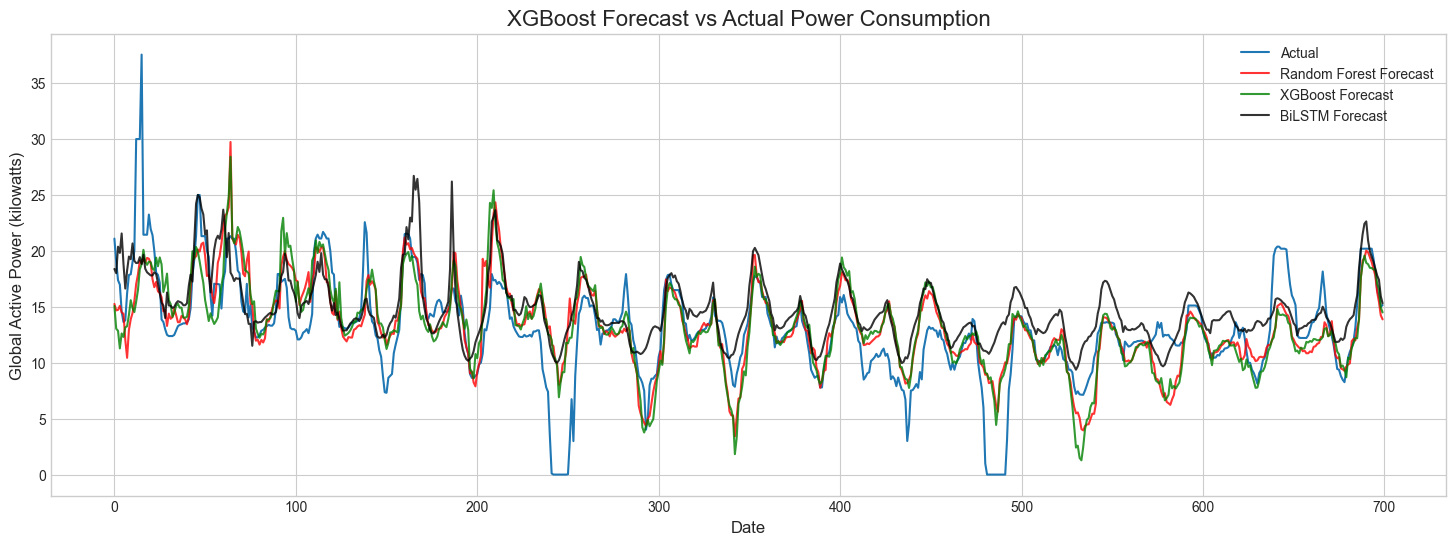

In [112]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_actual[:700], label='Actual')
plt.plot(rf_predictions[134:834], color='red', label='Random Forest Forecast', alpha=0.8)
plt.plot(xgb_predictions[134:834], color='green', label='XGBoost Forecast', alpha=0.8)
plt.plot(lstm_predictions[:700], color='black', label='BiLSTM Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)
plt.legend()
plt.show()

## 2022

In [124]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)

cutoff_date = '2022-01-01'
df = df[df.index >= cutoff_date].copy()
df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
date_time,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,18109750,19732300,16671250,15.46,19.86,19.86,19.86,19.86,19.86,19.86,19.86,19.86,13.25,4778800.0,3714450.0,1674250.0,861300.0
2022-01-01 00:30:00,19574000,20603350,17250450,15.46,19.84,19.84,19.84,19.84,19.84,19.84,19.84,19.84,13.25,5377700.0,3916650.0,2625450.0,1677200.0
2022-01-01 01:00:00,20715000,20963000,17568350,15.46,19.62,19.62,19.62,19.62,19.62,19.62,19.62,19.62,13.25,5635800.0,3937450.0,3337500.0,2238250.0
2022-01-01 01:30:00,21421600,21306050,17867750,15.46,17.60,17.60,17.60,17.60,17.60,17.60,17.60,17.60,13.25,6014100.0,3940050.0,3730850.0,2607300.0
2022-01-01 02:00:00,21960500,21443450,17997900,15.46,17.49,17.49,17.49,17.49,17.49,17.49,17.49,17.49,13.25,6400900.0,3936450.0,4041000.0,2898850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 21:30:00,23194300,20334000,14866150,11.20,15.19,11.41,11.41,11.41,9.00,9.00,9.00,9.00,9.00,7173000.0,1198500.0,1806050.0,1716050.0
2025-09-26 22:00:00,23034150,20511100,14615100,10.91,11.58,11.58,11.58,11.58,8.96,8.96,8.96,8.96,8.96,7190600.0,1119450.0,1929850.0,1739850.0
2025-09-26 22:30:00,23050450,20236750,14594650,10.58,11.20,11.20,11.20,11.20,8.63,8.63,8.63,8.63,8.63,7329400.0,1134050.0,1987550.0,1797550.0


In [7]:
df = pd.read_csv('data/jepx_2022.csv')
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)
df = df.resample('h').mean()
df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
date_time,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,18841875.0,20167825.0,16960850.0,15.460,19.850,19.850,19.850,19.850,19.850,19.850,19.850,19.850,13.250,5078250.0,3815550.0,2149850.0,1269250.0
2022-01-01 01:00:00,21068300.0,21134525.0,17718050.0,15.460,18.610,18.610,18.610,18.610,18.610,18.610,18.610,18.610,13.250,5824950.0,3938750.0,3534175.0,2422775.0
2022-01-01 02:00:00,22100150.0,21453250.0,18018200.0,15.460,17.595,17.595,17.595,17.595,17.595,17.595,17.595,17.595,13.250,6524875.0,3935175.0,4163550.0,3000525.0
2022-01-01 03:00:00,22982925.0,21574900.0,18159450.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,16.785,16.785,11.890,6982575.0,3931425.0,4626375.0,3438875.0
2022-01-01 04:00:00,23685750.0,21616450.0,18330475.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,16.785,16.785,10.530,7207250.0,3931750.0,4985375.0,3770800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00,22288600.0,22215700.0,16218650.0,11.795,15.270,14.240,14.240,11.410,11.410,11.410,11.410,11.410,11.410,5507525.0,1550000.0,1883900.0,1748900.0
2025-09-26 20:00:00,22787100.0,21286575.0,15459075.0,11.500,13.440,12.535,12.535,11.410,10.865,10.865,10.865,10.865,10.865,6651575.0,1373225.0,1940700.0,1809250.0
2025-09-26 21:00:00,22922825.0,20512950.0,14937225.0,11.305,13.380,11.490,11.490,11.410,9.500,9.500,9.500,9.500,9.500,6963900.0,1211575.0,1844375.0,1749725.0


In [8]:
df.isnull().sum()

sell_bid_amount                      0
buy_bid_amount                       0
total_contract_amount                0
system_price                         0
hokkaido_area_price                  0
tohoku_area_price                    0
tokyo_area_price                     0
chubu_area_price                     0
hokuriku_area_price                  0
kansai_area_price                    0
chugoku_area_price                   0
shikoku_area_price                   0
kyushu_area_price                    0
sell_block_bid_total_amount          0
total_sell_block_execution_amount    0
buy_block_bid_total_amount           0
total_buy_block_total_amount         0
dtype: int64

In [9]:
df.describe()

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
count,3.276000e+04,3.276000e+04,3.276000e+04,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,3.276000e+04,3.276000e+04,3.276000e+04,3.276000e+04
mean,2.371287e+07,2.003648e+07,1.630524e+07,14.586426,15.311620,15.350269,16.587230,15.070344,13.993904,13.921457,13.702235,13.236441,11.602904,6.940112e+06,1.871228e+06,2.516424e+06,1.816072e+06
std,4.833742e+06,4.026178e+06,3.347958e+06,8.517673,9.578342,9.888377,10.039701,8.681559,8.291488,8.311067,8.166663,8.300328,7.517892,2.647003e+06,1.176140e+06,1.059210e+06,8.497312e+05
min,1.254655e+07,8.630925e+06,8.458175e+06,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,1.377200e+06,8.852500e+04,1.533250e+05,1.377000e+05
25%,2.029279e+07,1.707298e+07,1.367229e+07,10.090000,10.190000,10.450000,11.405000,10.465000,9.290000,9.168750,9.005000,8.610000,7.800000,4.991638e+06,8.860500e+05,1.723369e+06,1.205225e+06
50%,2.293009e+07,1.962068e+07,1.599046e+07,12.615000,13.370000,13.280000,14.035000,13.150000,12.215000,12.127500,11.990000,11.390000,10.645000,6.334788e+06,1.536600e+06,2.362925e+06,1.665938e+06
75%,2.625337e+07,2.247946e+07,1.865814e+07,17.861250,18.750000,18.395000,19.315000,18.480000,18.015000,17.995000,17.740000,17.480000,14.801250,8.391469e+06,2.770106e+06,3.206469e+06,2.298700e+06
max,4.915865e+07,3.695005e+07,2.689408e+07,100.000000,200.000000,200.000000,200.000000,100.020000,100.020000,100.020000,100.020000,100.020000,82.510000,2.017138e+07,5.402800e+06,7.504975e+06,7.272475e+06


In [126]:
df.to_csv('data/jepx_2022.csv')


--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---


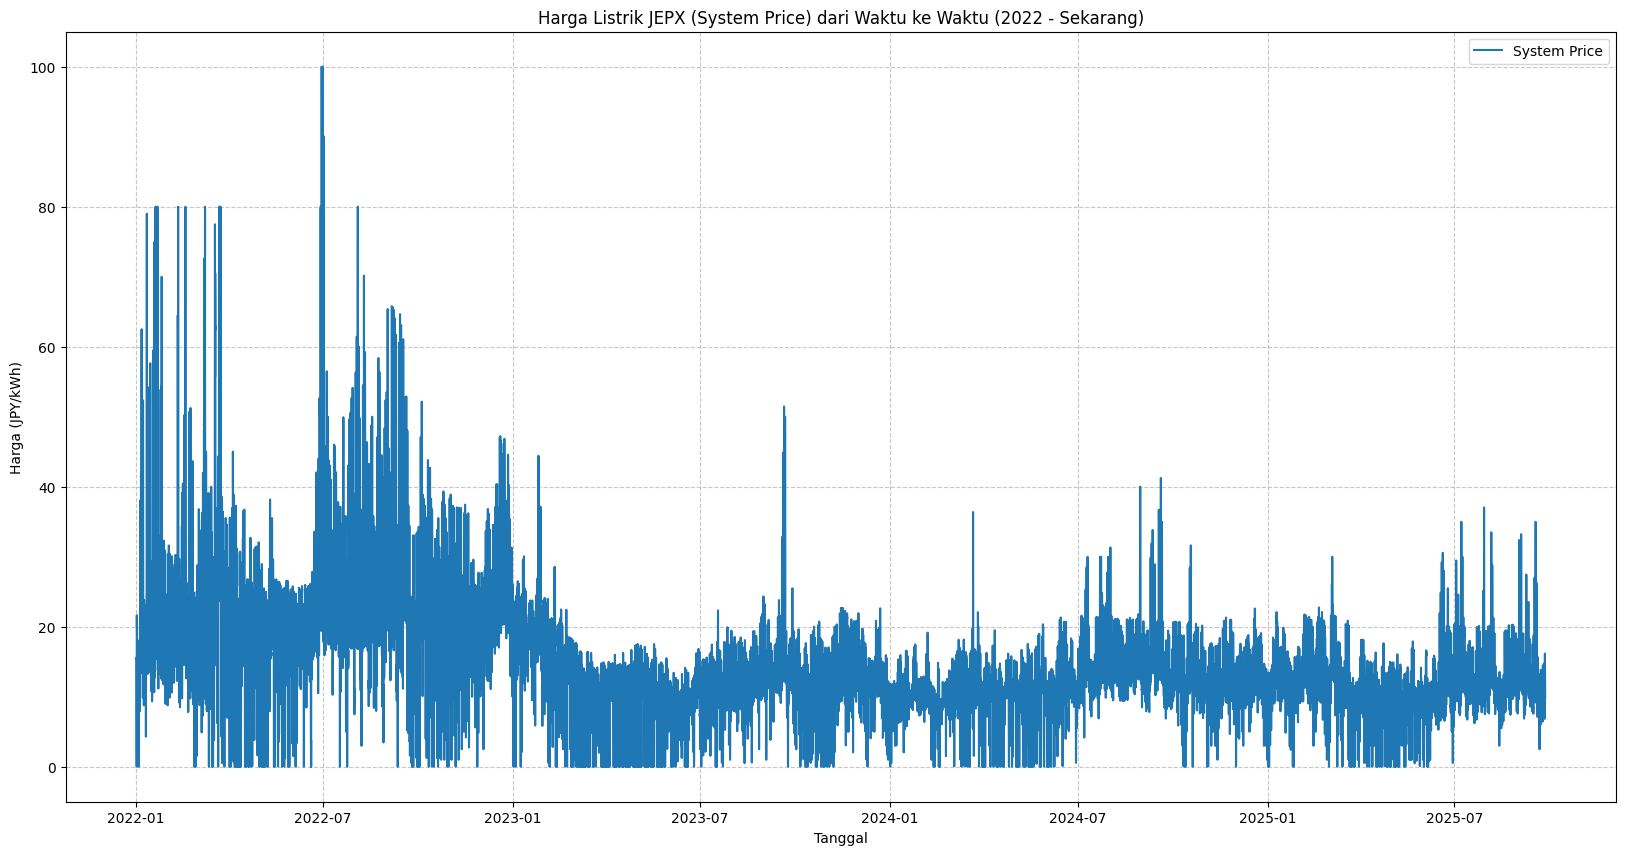


--- Plot Dekomposisi Musiman (Tahun 2022) ---


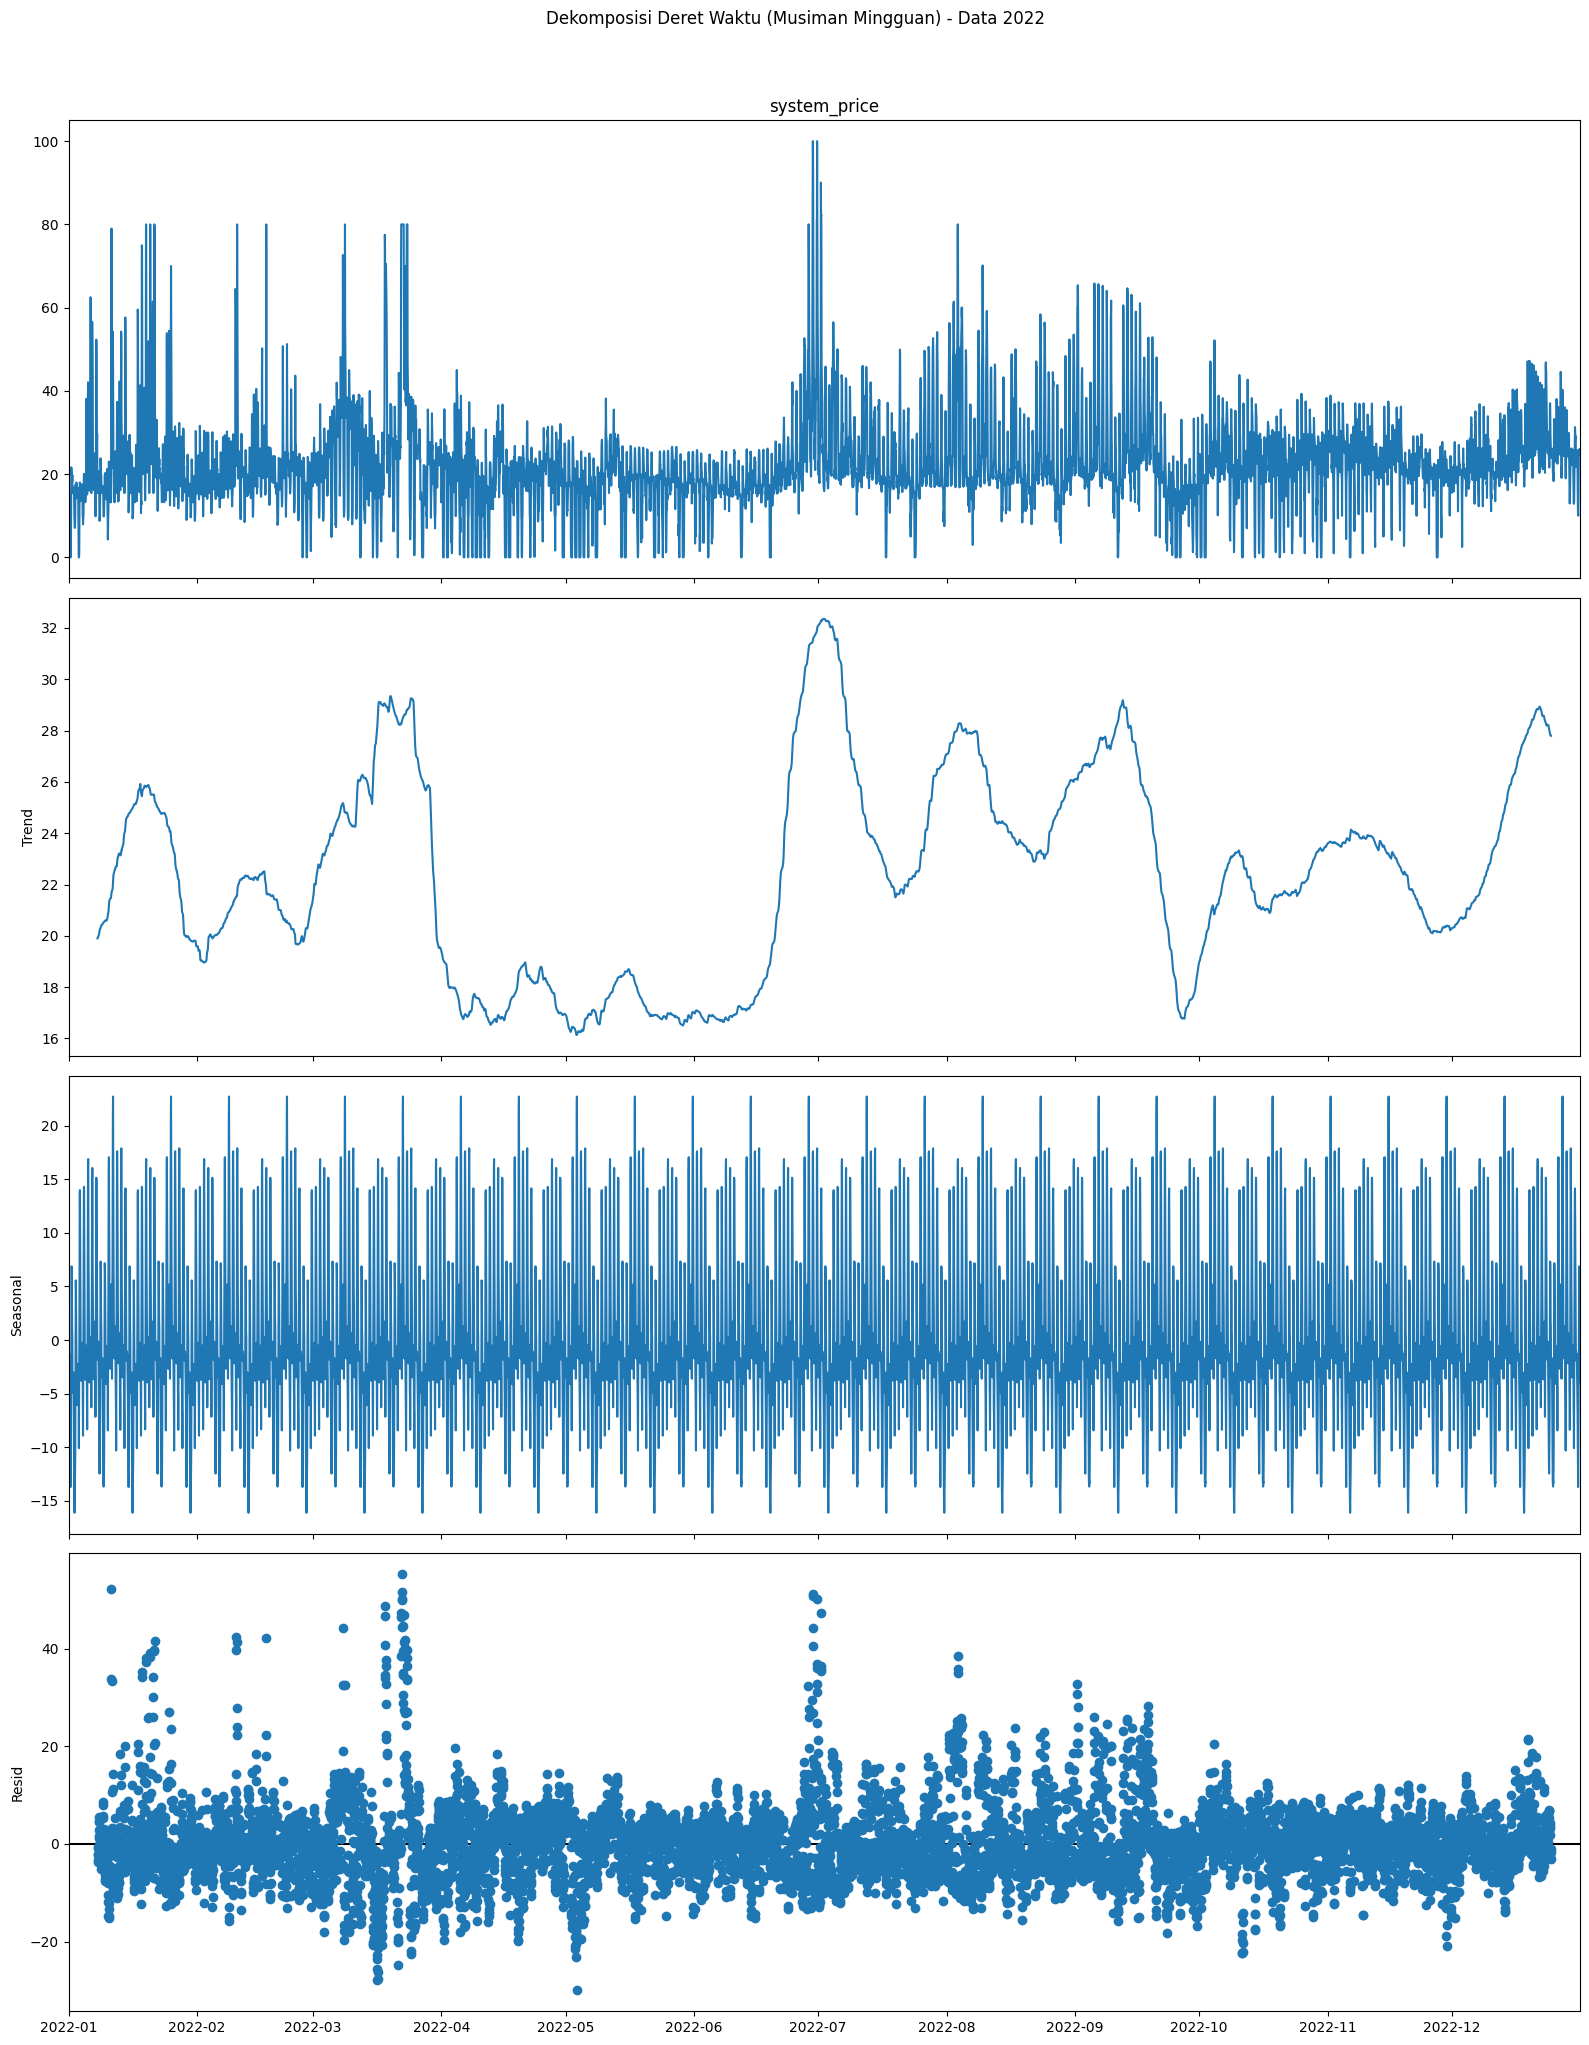


--- Box Plot Musiman ---


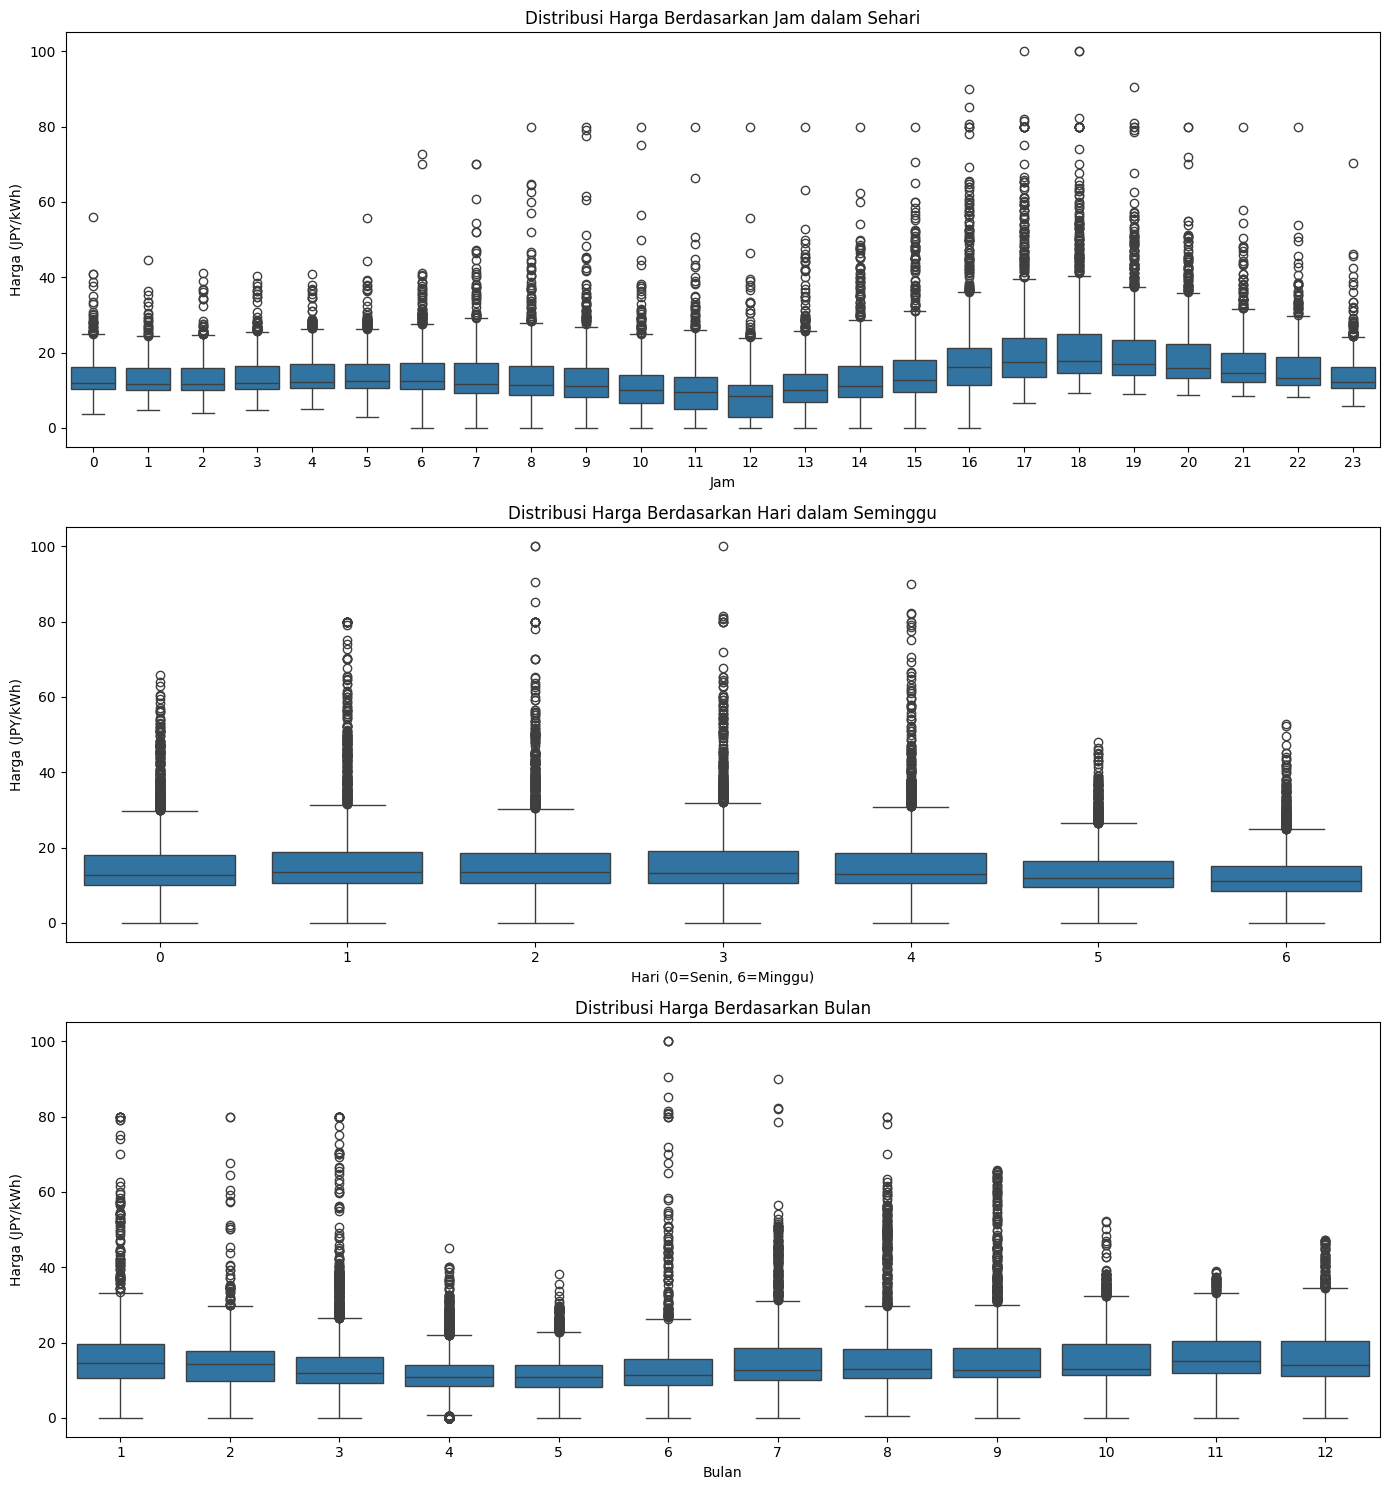

In [10]:
# TAHAP 1: ANALISIS DATA EKSPLORASI (EDA)

print("\n--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---")

# 1.1. Visualisasi Data Awal

price_col = 'system_price'

# 1.1. Visualisasi Data Awal

# Plot Deret Waktu Keseluruhan
plt.figure(figsize=(20, 10))
plt.plot(df.index, df[price_col], label='System Price')
plt.title('Harga Listrik JEPX (System Price) dari Waktu ke Waktu (2022 - Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (JPY/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---
# Catatan: Untuk Dekomposisi Musiman, period=48*7 (48 titik per hari * 7 hari) adalah musiman mingguan
# Menggunakan data dari tahun 2022
if '2022' in df.index:
    print("\n--- Plot Dekomposisi Musiman (Tahun 2022) ---")
    result_decompose = seasonal_decompose(df[price_col]['2022'], model='additive', period=48*7)
    fig = result_decompose.plot()
    fig.set_size_inches(16, 20)
    plt.suptitle('Dekomposisi Deret Waktu (Musiman Mingguan) - Data 2022', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak cukup data untuk dekomposisi tahun 2022, melompati plot dekomposisi.")


# ---

# Box Plot Musiman untuk melihat pola harian, mingguan, dan bulanan
print("\n--- Box Plot Musiman ---")
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

# Pola Harian (berdasarkan jam)
sns.boxplot(x=df.index.hour, y=df[price_col], ax=axes[0]) # Menggunakan axes[0]
axes[0].set_title('Distribusi Harga Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Harga (JPY/kWh)')

# Pola Mingguan (berdasarkan hari)
sns.boxplot(x=df.index.dayofweek, y=df[price_col], ax=axes[1]) # Menggunakan axes[1]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[1].set_title('Distribusi Harga Berdasarkan Hari dalam Seminggu')
axes[1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[1].set_ylabel('Harga (JPY/kWh)')

# Pola Tahunan (berdasarkan bulan)
sns.boxplot(x=df.index.month, y=df[price_col], ax=axes[2]) # Menggunakan axes[2]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[2].set_title('Distribusi Harga Berdasarkan Bulan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Harga (JPY/kWh)')

plt.tight_layout()
plt.show()

In [11]:
TARGET = 'system_price'

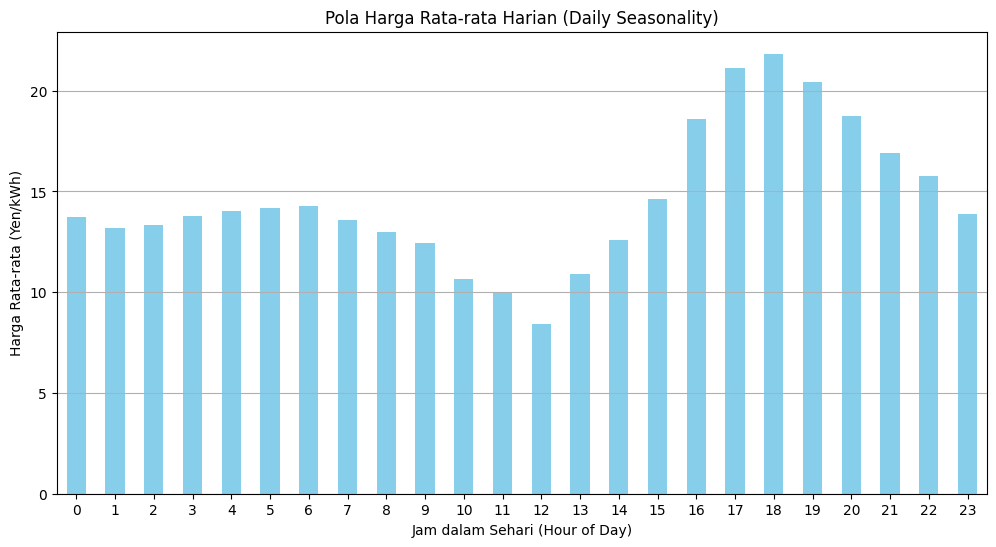

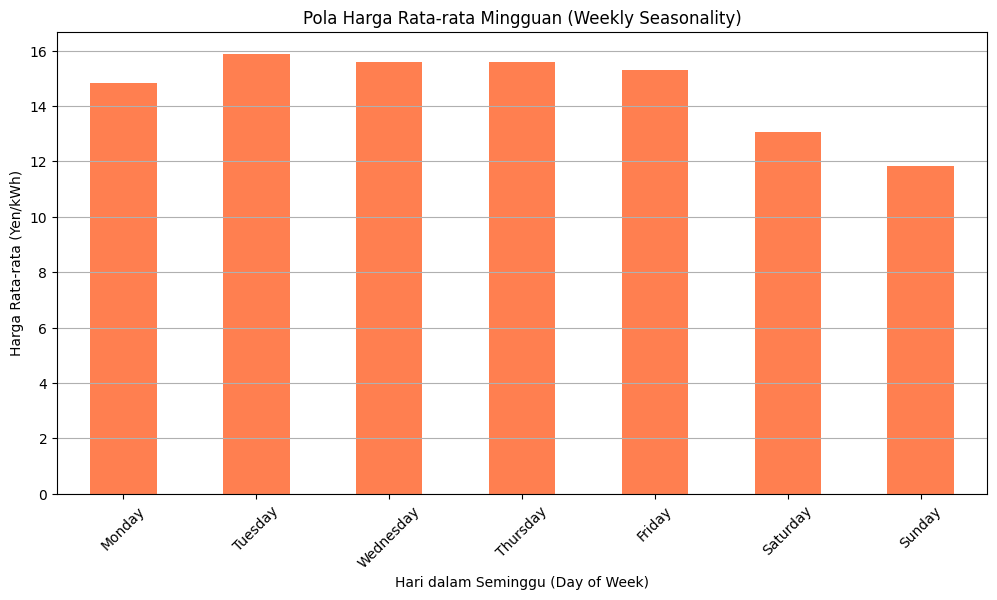

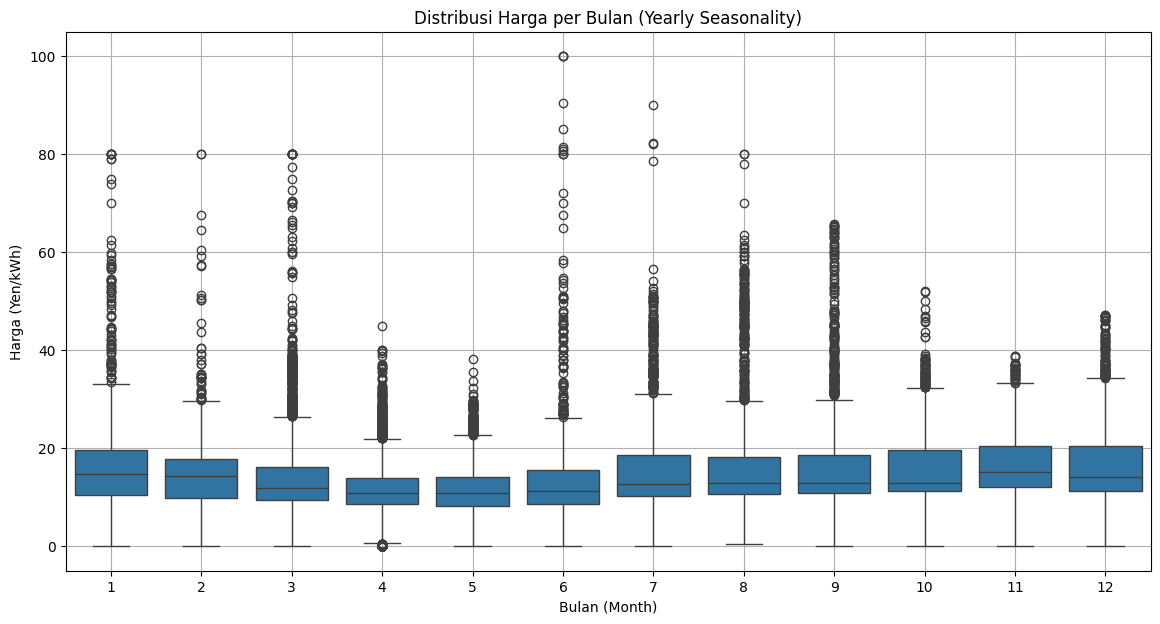

In [12]:
# --- Analisis Musiman Harian (Daily Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan data berdasarkan jam dan menghitung harga rata-rata
hourly_seasonality = df.groupby(df.index.hour)[TARGET].mean()
hourly_seasonality.plot(kind='bar', color='skyblue')
plt.title('Pola Harga Rata-rata Harian (Daily Seasonality)')
plt.xlabel('Jam dalam Sehari (Hour of Day)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Mingguan (Weekly Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan berdasarkan nama hari dan menghitung harga rata-rata
weekly_seasonality = df.groupby(df.index.day_name())[TARGET].mean()
# Mengurutkan hari agar sesuai urutan kalender
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_seasonality = weekly_seasonality.reindex(day_order)
weekly_seasonality.plot(kind='bar', color='coral')
plt.title('Pola Harga Rata-rata Mingguan (Weekly Seasonality)')
plt.xlabel('Hari dalam Seminggu (Day of Week)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Tahunan (Yearly/Monthly Seasonality) ---
plt.figure(figsize=(14, 7))
# Menggunakan boxplot untuk melihat distribusi harga setiap bulan
sns.boxplot(x=df.index.month, y=df[TARGET])
plt.title('Distribusi Harga per Bulan (Yearly Seasonality)')
plt.xlabel('Bulan (Month)')
plt.ylabel('Harga (Yen/kWh)')
plt.grid(True)
plt.show()


Korelasi Fitur terhadap Target (system_price):
system_price                         1.000000
chubu_area_price                     0.938482
kansai_area_price                    0.934643
hokuriku_area_price                  0.934583
chugoku_area_price                   0.926102
shikoku_area_price                   0.908947
tokyo_area_price                     0.901675
tohoku_area_price                    0.891515
hokkaido_area_price                  0.879375
kyushu_area_price                    0.797009
total_sell_block_execution_amount    0.631386
buy_bid_amount                       0.481435
total_contract_amount                0.312266
buy_block_bid_total_amount           0.076177
total_buy_block_total_amount        -0.239634
sell_bid_amount                     -0.414785
sell_block_bid_total_amount         -0.499170
Name: system_price, dtype: float64


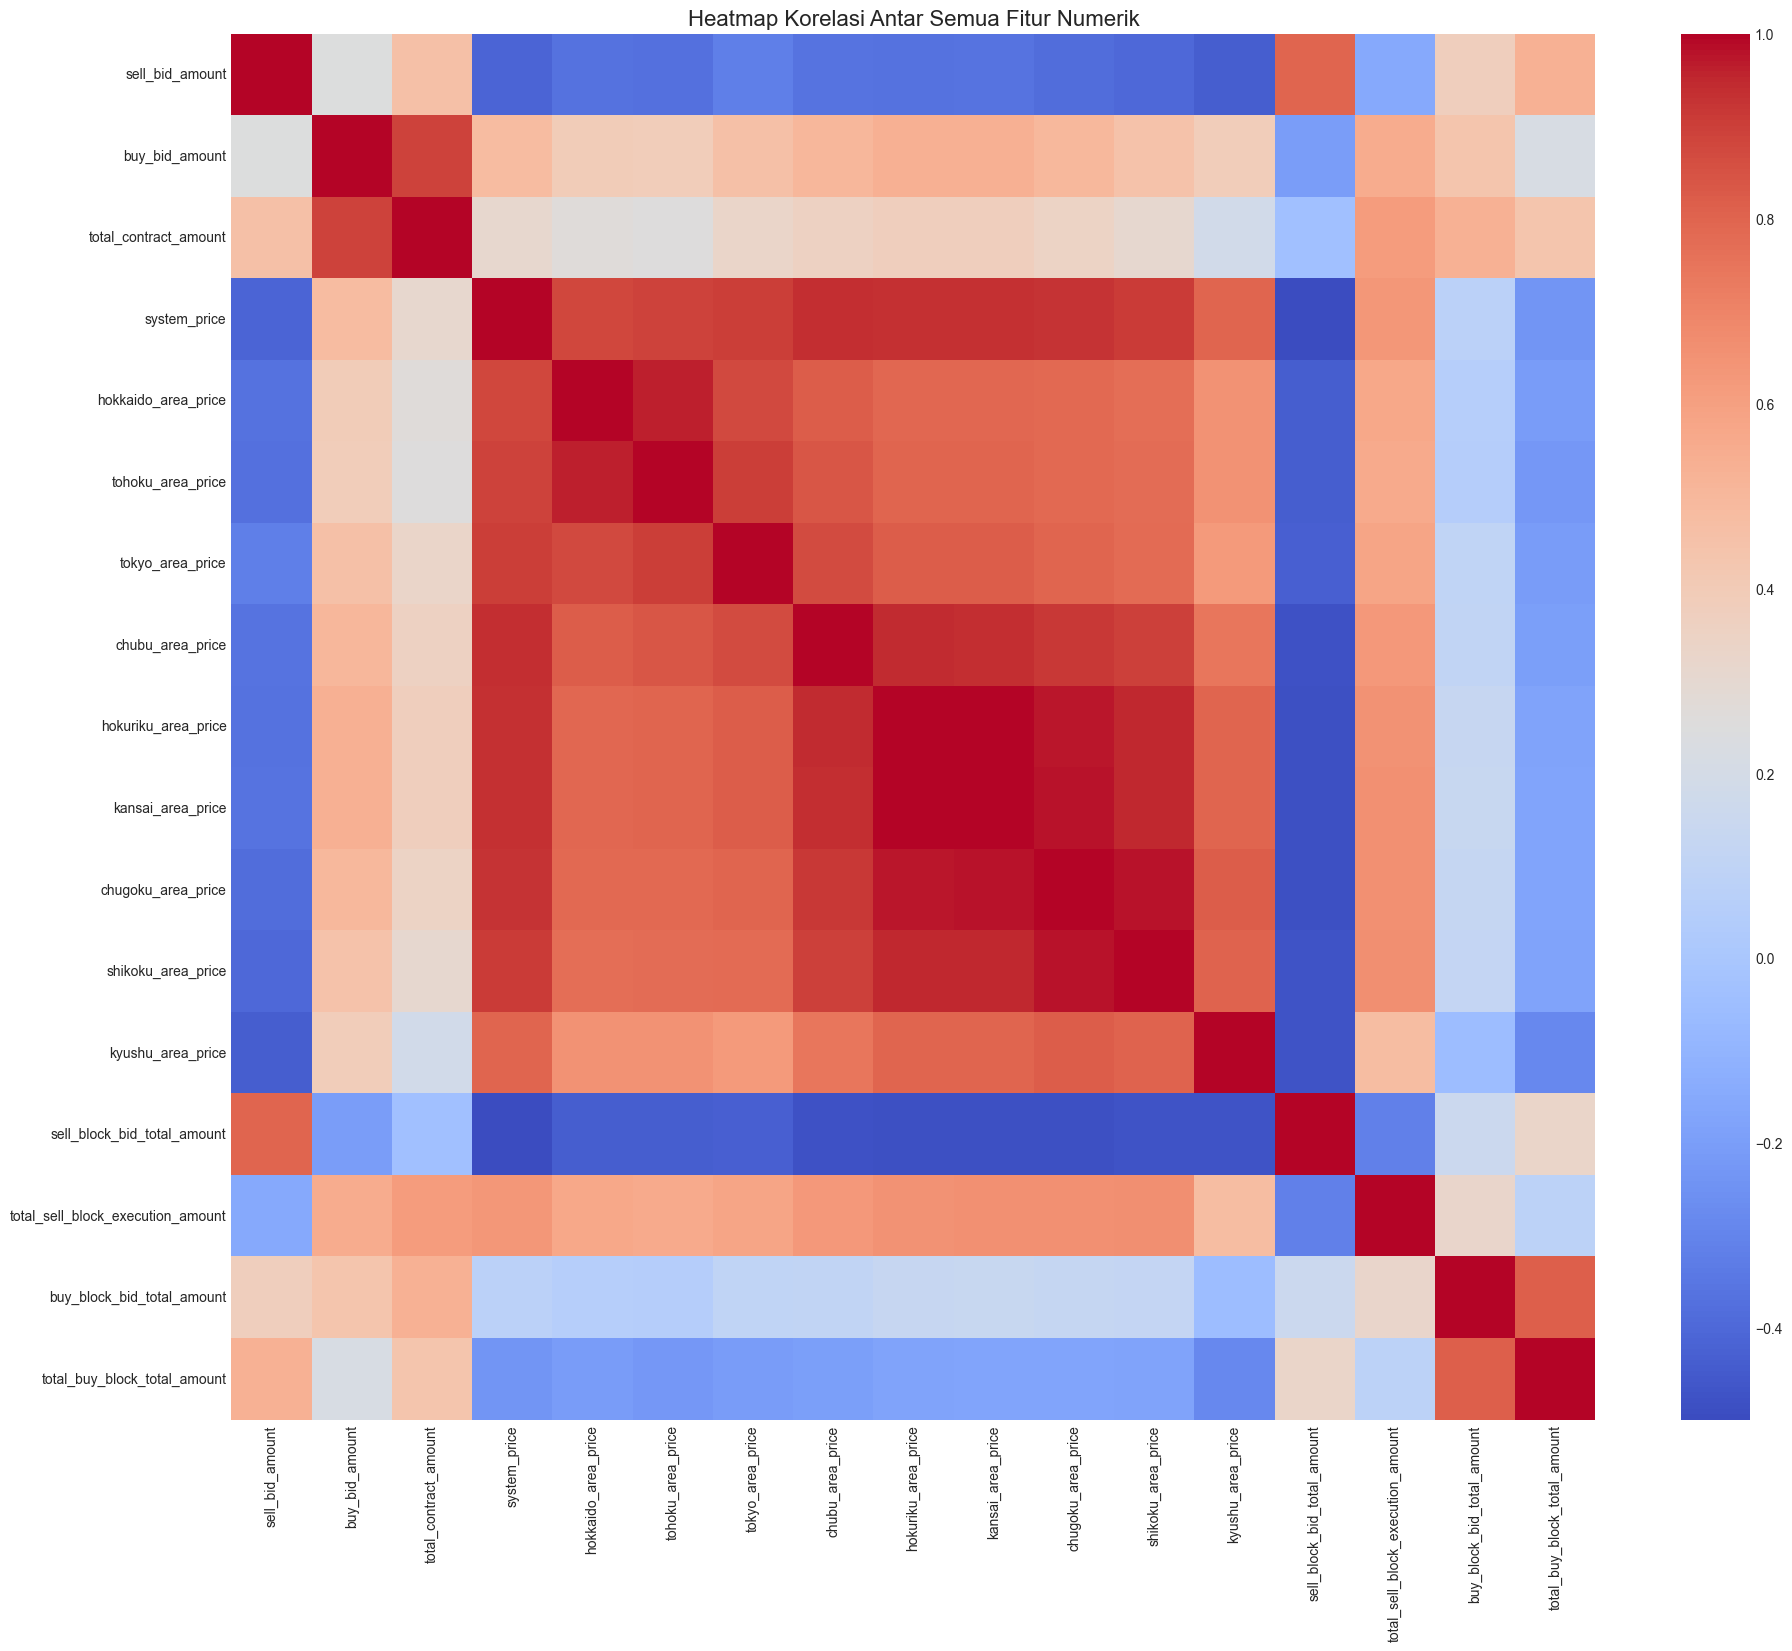

In [130]:
# Menghitung matriks korelasi untuk semua fitur
# Kita hanya akan menggunakan fitur numerik untuk korelasi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

# Menampilkan korelasi dari setiap fitur terhadap 'system_price'
# Diurutkan dari yang paling tinggi ke paling rendah
print(f"\nKorelasi Fitur terhadap Target ({TARGET}):")
target_correlation = correlation_matrix[TARGET].sort_values(ascending=False)
print(target_correlation)

# Visualisasi matriks korelasi dengan heatmap
# Ini membantu melihat gambaran besar hubungan antar semua variabel
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False agar tidak terlalu ramai
plt.title('Heatmap Korelasi Antar Semua Fitur Numerik', fontsize=16)
plt.show()

In [13]:
TARGET = 'tokyo_area_price'


--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---


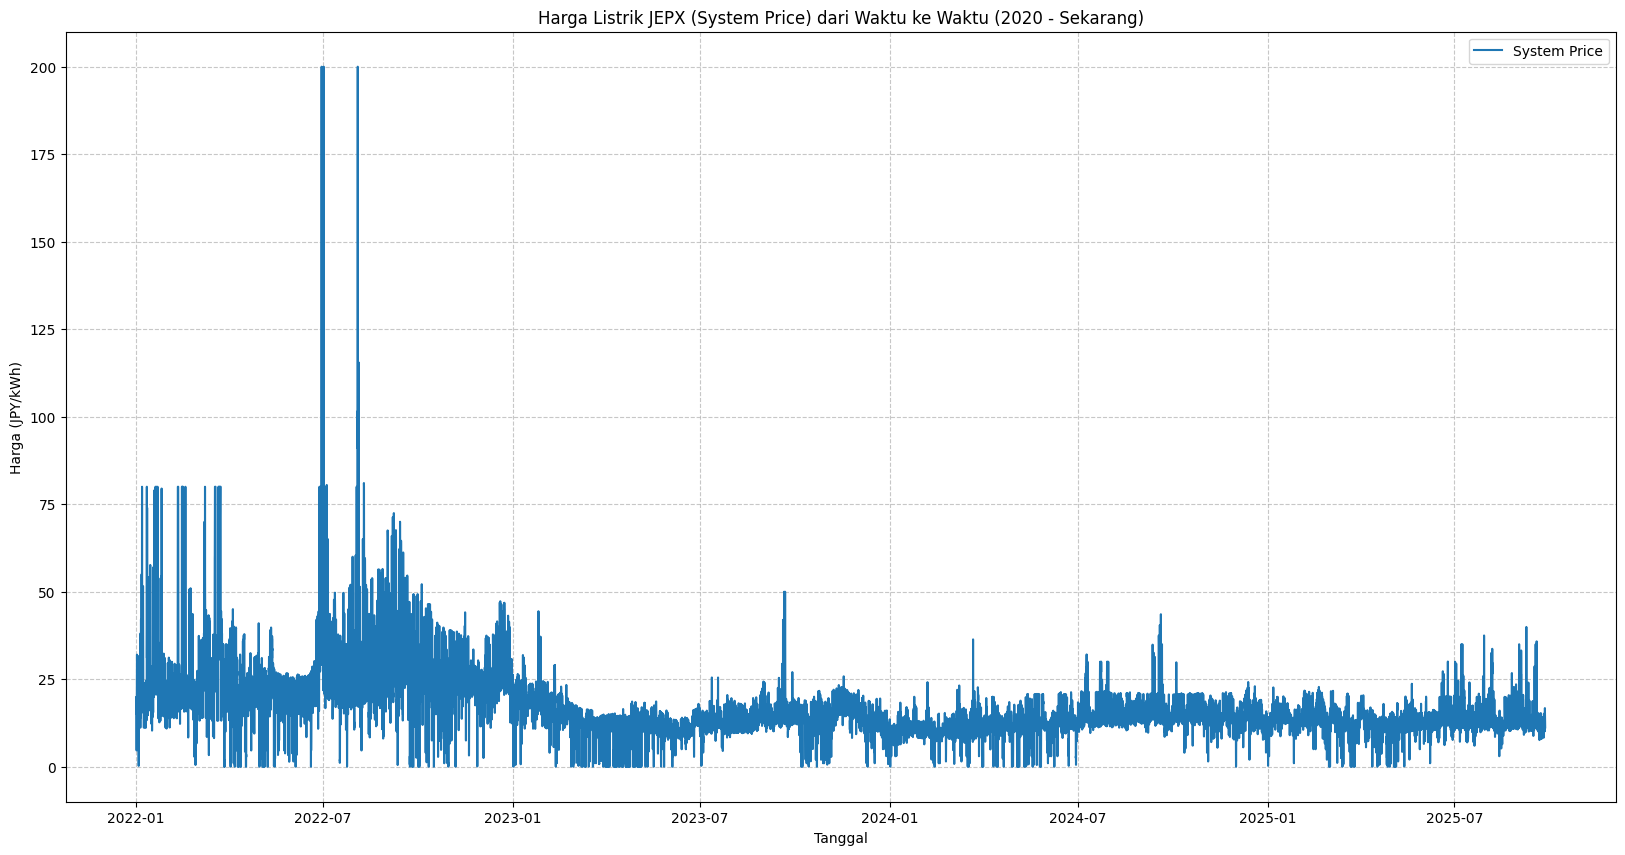


--- Plot Dekomposisi Musiman (Tahun 2022) ---


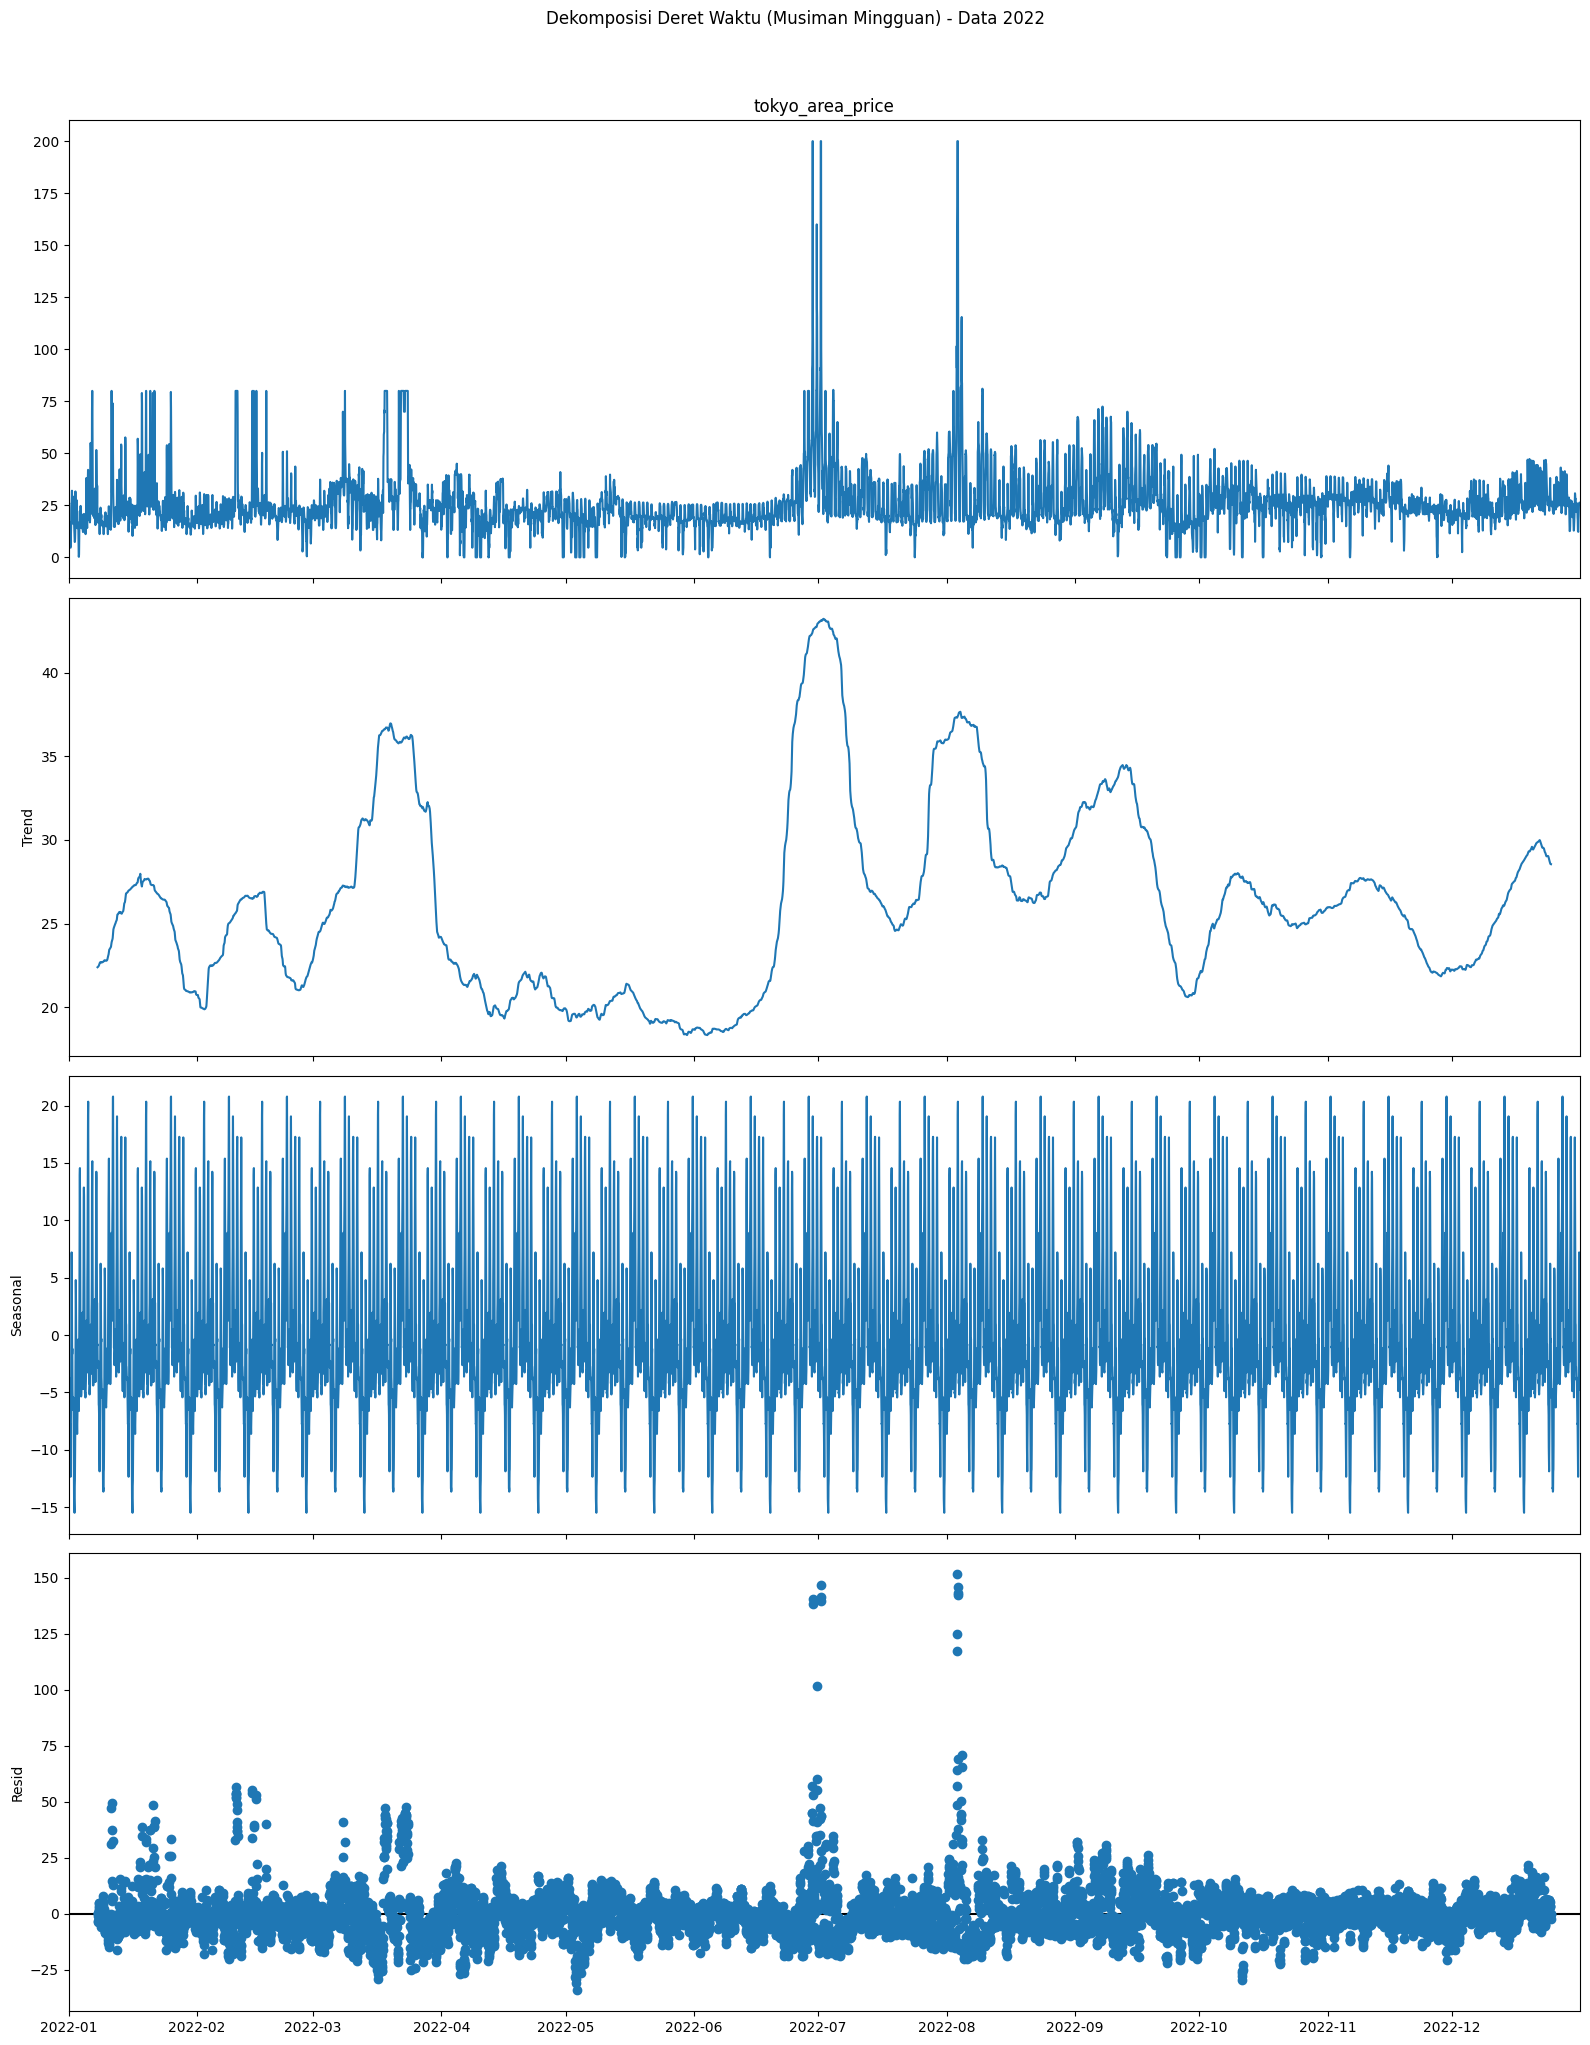


--- Box Plot Musiman ---


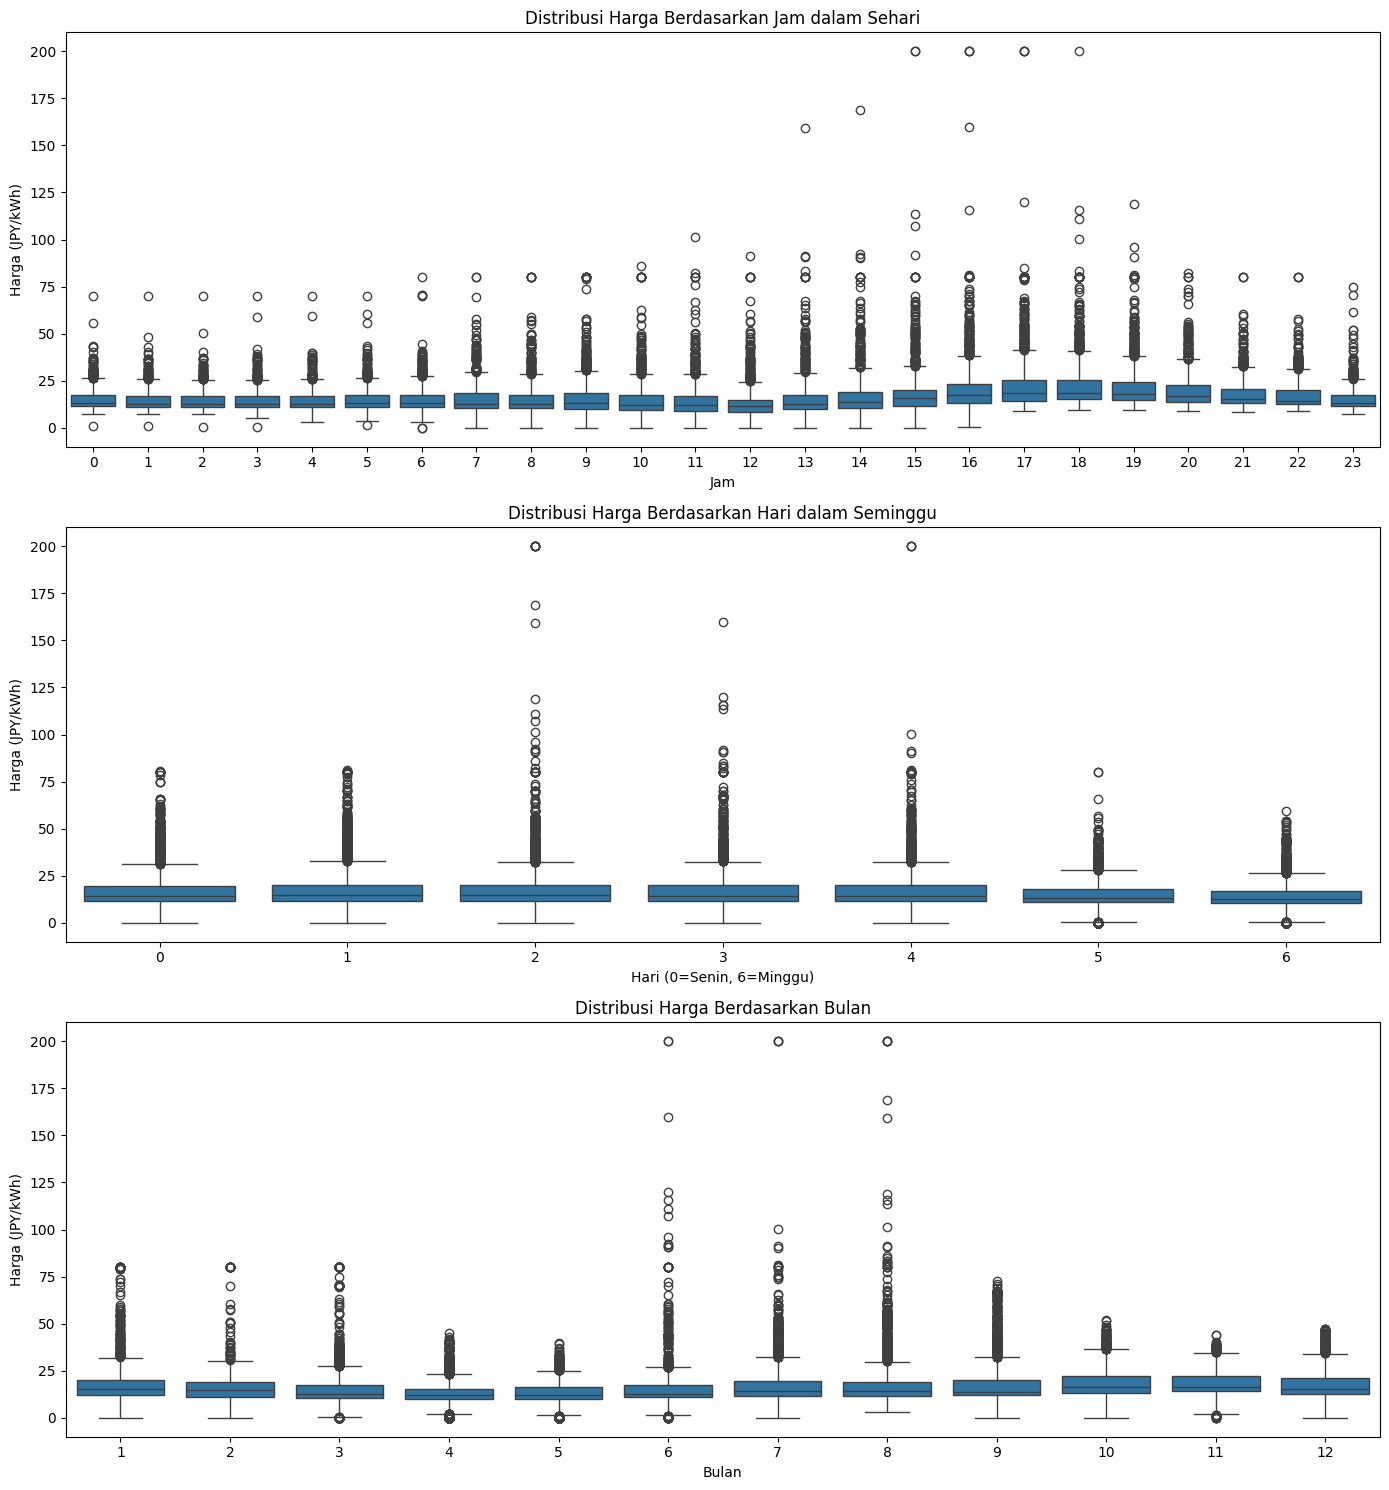

In [14]:
# TAHAP 1: ANALISIS DATA EKSPLORASI (EDA)

print("\n--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---")

# 1.1. Visualisasi Data Awal

# Plot Deret Waktu Keseluruhan
plt.figure(figsize=(20, 10))
plt.plot(df.index, df[TARGET], label='System Price')
plt.title('Harga Listrik JEPX (System Price) dari Waktu ke Waktu (2020 - Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (JPY/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---
# Catatan: Untuk Dekomposisi Musiman, period=48*7 (48 titik per hari * 7 hari) adalah musiman mingguan
# Menggunakan data dari tahun 2022
if '2022' in df.index:
    print("\n--- Plot Dekomposisi Musiman (Tahun 2022) ---")
    result_decompose = seasonal_decompose(df[TARGET]['2022'], model='additive', period=48*7)
    fig = result_decompose.plot()
    fig.set_size_inches(16, 20)
    plt.suptitle('Dekomposisi Deret Waktu (Musiman Mingguan) - Data 2022', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak cukup data untuk dekomposisi tahun 2022, melompati plot dekomposisi.")


# ---

# Box Plot Musiman untuk melihat pola harian, mingguan, dan bulanan
print("\n--- Box Plot Musiman ---")
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

# Pola Harian (berdasarkan jam)
sns.boxplot(x=df.index.hour, y=df[TARGET], ax=axes[0]) # Menggunakan axes[0]
axes[0].set_title('Distribusi Harga Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Harga (JPY/kWh)')

# Pola Mingguan (berdasarkan hari)
sns.boxplot(x=df.index.dayofweek, y=df[TARGET], ax=axes[1]) # Menggunakan axes[1]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[1].set_title('Distribusi Harga Berdasarkan Hari dalam Seminggu')
axes[1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[1].set_ylabel('Harga (JPY/kWh)')

# Pola Tahunan (berdasarkan bulan)
sns.boxplot(x=df.index.month, y=df[TARGET], ax=axes[2]) # Menggunakan axes[2]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[2].set_title('Distribusi Harga Berdasarkan Bulan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Harga (JPY/kWh)')

plt.tight_layout()
plt.show()

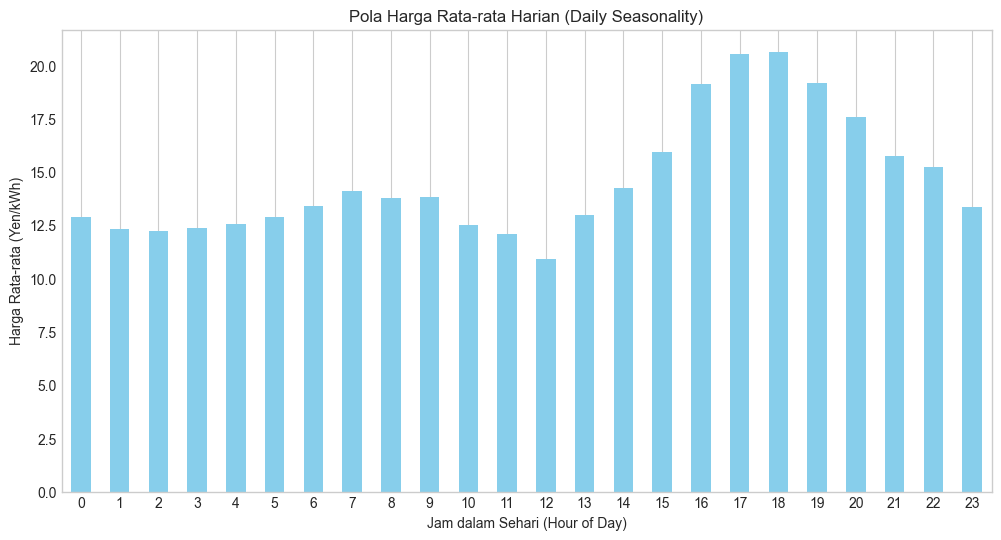

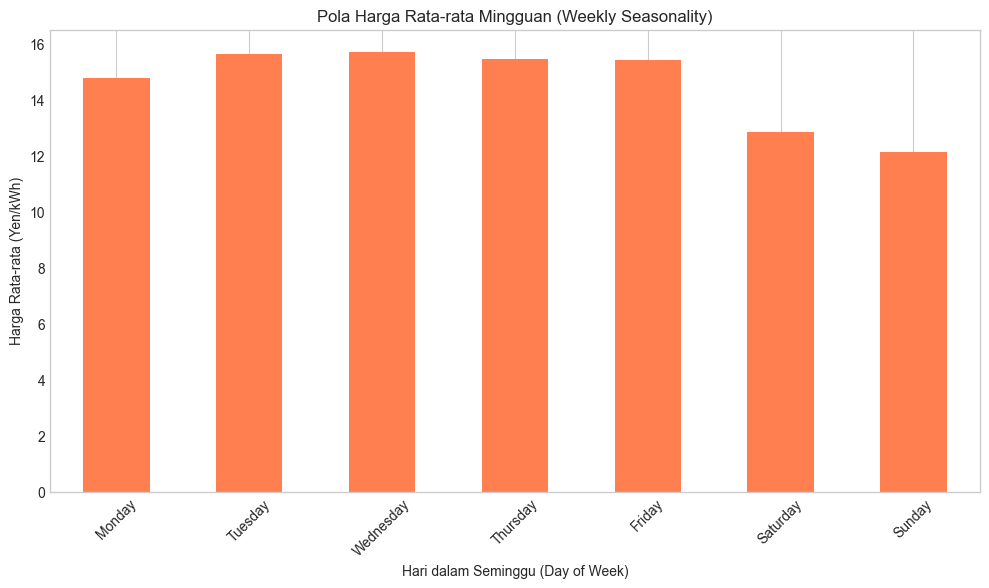

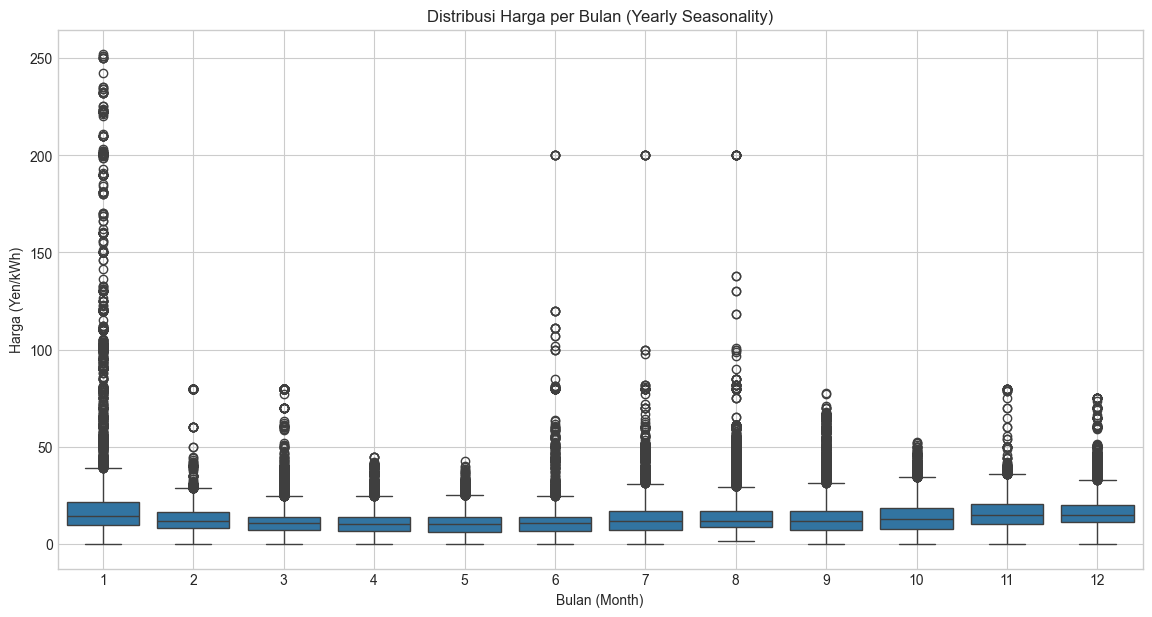

In [ ]:
# --- Analisis Musiman Harian (Daily Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan data berdasarkan jam dan menghitung harga rata-rata
hourly_seasonality = df.groupby(df.index.hour)[TARGET].mean()
hourly_seasonality.plot(kind='bar', color='skyblue')
plt.title('Pola Harga Rata-rata Harian (Daily Seasonality)')
plt.xlabel('Jam dalam Sehari (Hour of Day)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Mingguan (Weekly Seasonality) ---
plt.figure(figsize=(12, 6))
# Mengelompokkan berdasarkan nama hari dan menghitung harga rata-rata
weekly_seasonality = df.groupby(df.index.day_name())[TARGET].mean()
# Mengurutkan hari agar sesuai urutan kalender
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_seasonality = weekly_seasonality.reindex(day_order)
weekly_seasonality.plot(kind='bar', color='coral')
plt.title('Pola Harga Rata-rata Mingguan (Weekly Seasonality)')
plt.xlabel('Hari dalam Seminggu (Day of Week)')
plt.ylabel('Harga Rata-rata (Yen/kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# --- Analisis Musiman Tahunan (Yearly/Monthly Seasonality) ---
plt.figure(figsize=(14, 7))
# Menggunakan boxplot untuk melihat distribusi harga setiap bulan
sns.boxplot(x=df.index.month, y=df[TARGET])
plt.title('Distribusi Harga per Bulan (Yearly Seasonality)')
plt.xlabel('Bulan (Month)')
plt.ylabel('Harga (Yen/kWh)')
plt.grid(True)
plt.show()


Korelasi Fitur terhadap Target (tokyo_area_price):
tokyo_area_price                     1.000000
tohoku_area_price                    0.902706
system_price                         0.901675
hokkaido_area_price                  0.872781
chubu_area_price                     0.866325
hokuriku_area_price                  0.821665
kansai_area_price                    0.821242
chugoku_area_price                   0.796114
shikoku_area_price                   0.781150
kyushu_area_price                    0.619894
total_sell_block_execution_amount    0.583383
buy_bid_amount                       0.459347
total_contract_amount                0.328500
buy_block_bid_total_amount           0.098877
total_buy_block_total_amount        -0.206890
sell_bid_amount                     -0.323149
sell_block_bid_total_amount         -0.432855
Name: tokyo_area_price, dtype: float64


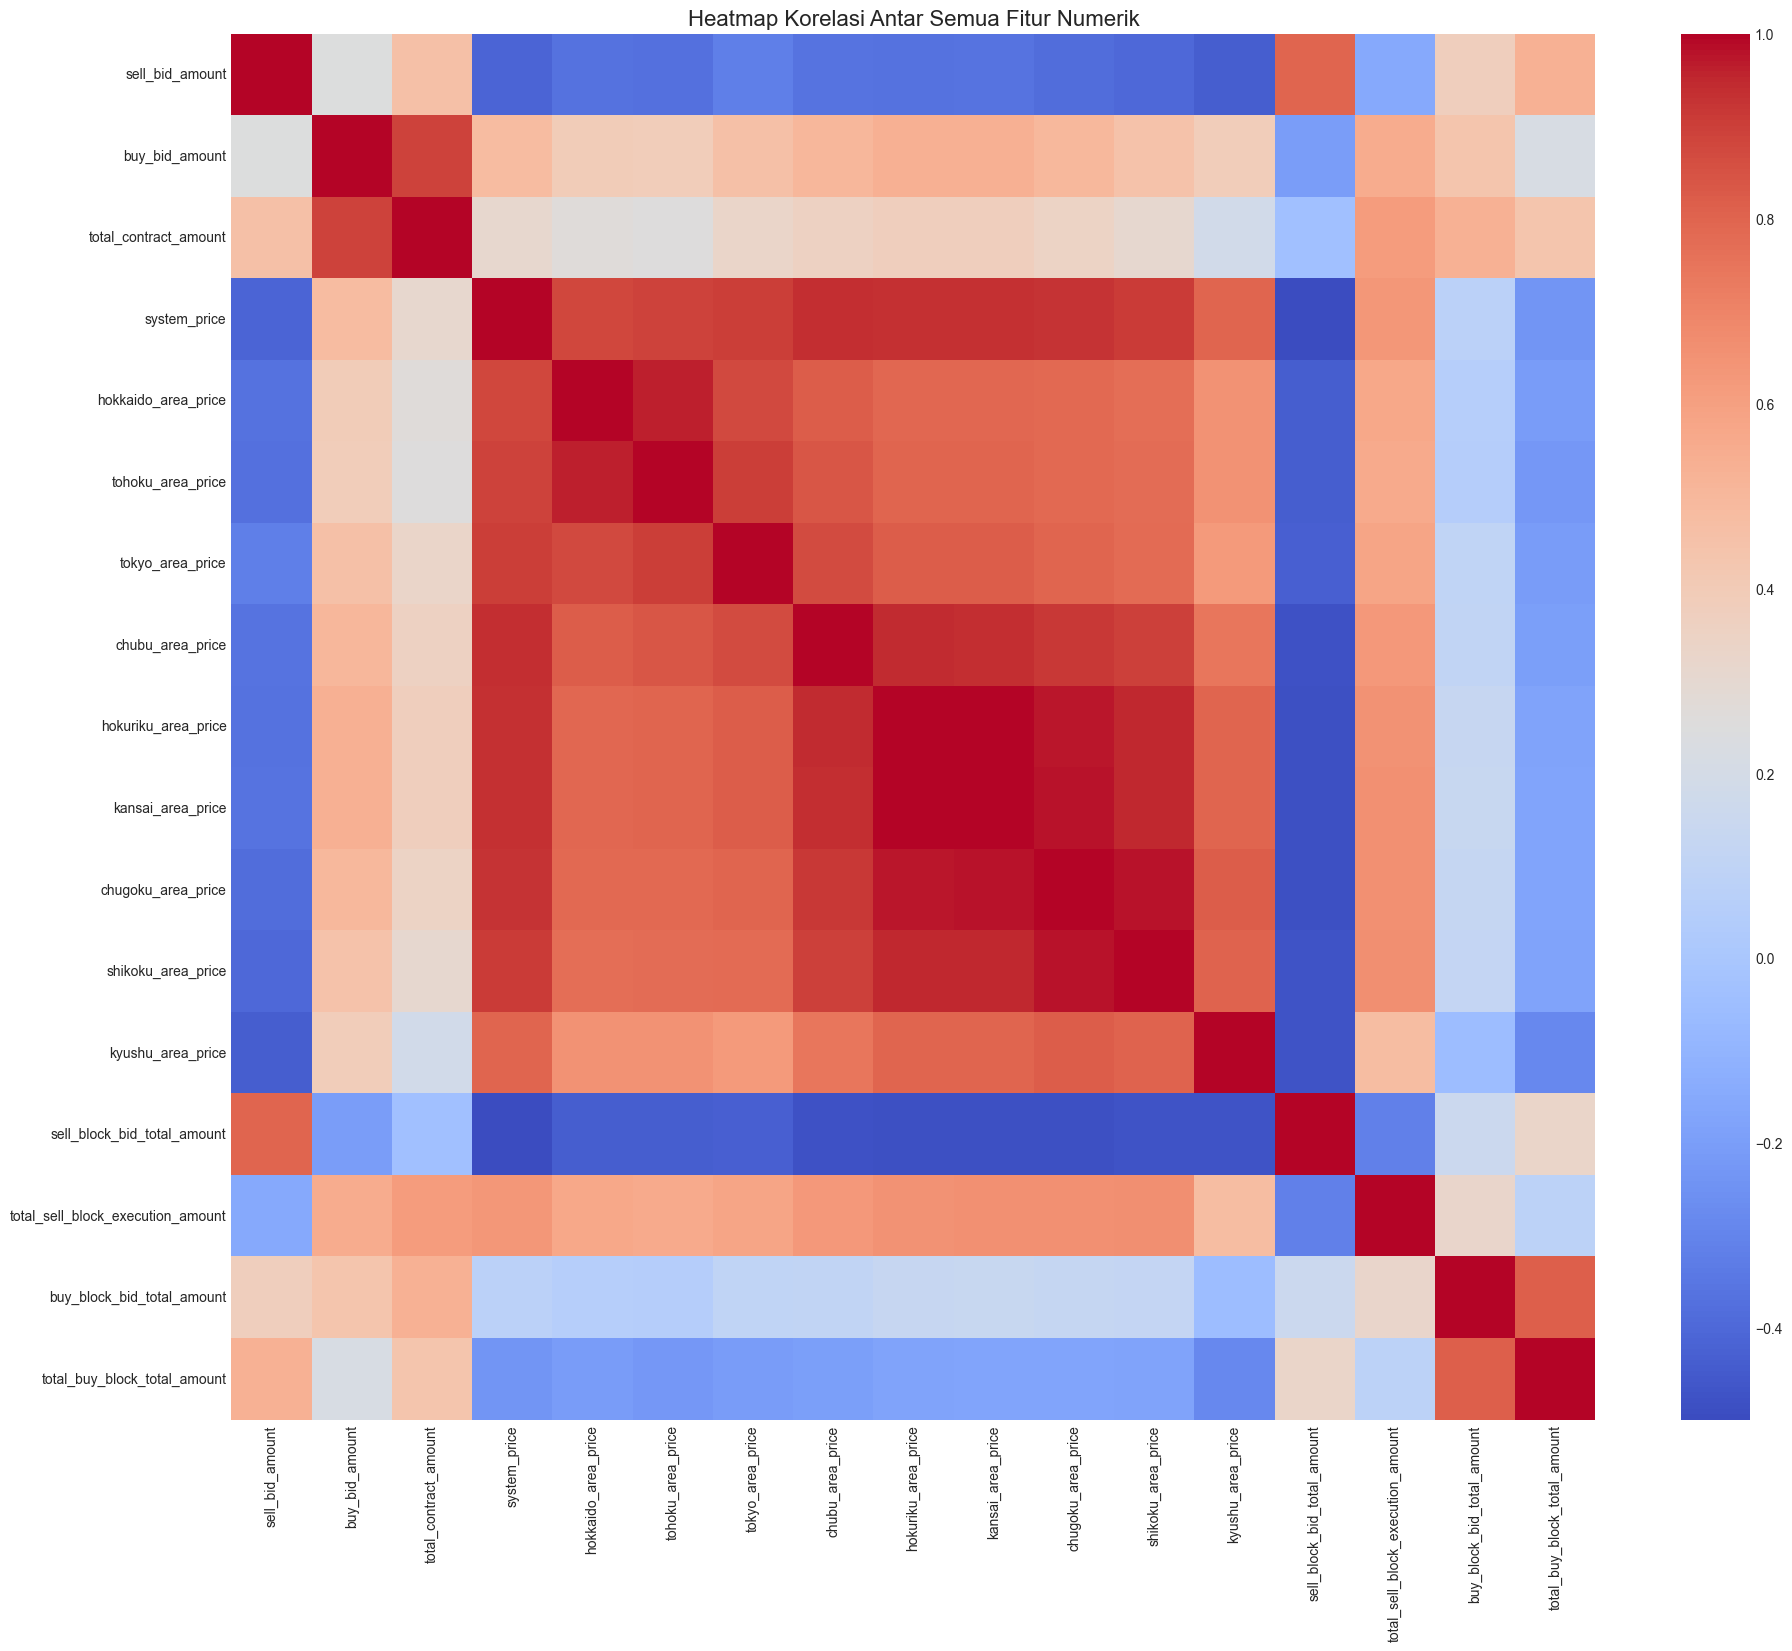

In [133]:
# Menghitung matriks korelasi untuk semua fitur
# Kita hanya akan menggunakan fitur numerik untuk korelasi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

# Menampilkan korelasi dari setiap fitur terhadap 'system_price'
# Diurutkan dari yang paling tinggi ke paling rendah
print(f"\nKorelasi Fitur terhadap Target ({TARGET}):")
target_correlation = correlation_matrix[TARGET].sort_values(ascending=False)
print(target_correlation)

# Visualisasi matriks korelasi dengan heatmap
# Ini membantu melihat gambaran besar hubungan antar semua variabel
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False agar tidak terlalu ramai
plt.title('Heatmap Korelasi Antar Semua Fitur Numerik', fontsize=16)
plt.show()

In [15]:
# --- 4. Rekayasa Fitur untuk Model Machine Learning ---
def create_features(df):
    """
    Membuat fitur berbasis waktu dari datetime index.
    """
    df_copy = df.copy()
    df_copy['hour'] = df_copy.index.hour
    df_copy['day_of_week'] = df_copy.index.dayofweek # Senin=0, Minggu=6
    df_copy['day_of_year'] = df_copy.index.dayofyear
    df_copy['month'] = df_copy.index.month
    df_copy['quarter'] = df_copy.index.quarter
    df_copy['year'] = df_copy.index.year
    return df_copy

df_featured = create_features(df)
print("\nData dengan fitur-fitur baru:")
df_featured.head()


Data dengan fitur-fitur baru:


,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,...,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount,hour,day_of_week,day_of_year,month,quarter,year
date_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,18841875.0,20167825.0,16960850.0,15.46,19.850,19.850,19.850,19.850,19.850,19.850,...,5078250.0,3815550.0,2149850.0,1269250.0,0,5,1,1,1,2022
2022-01-01 01:00:00,21068300.0,21134525.0,17718050.0,15.46,18.610,18.610,18.610,18.610,18.610,18.610,...,5824950.0,3938750.0,3534175.0,2422775.0,1,5,1,1,1,2022
2022-01-01 02:00:00,22100150.0,21453250.0,18018200.0,15.46,17.595,17.595,17.595,17.595,17.595,17.595,...,6524875.0,3935175.0,4163550.0,3000525.0,2,5,1,1,1,2022
2022-01-01 03:00:00,22982925.0,21574900.0,18159450.0,15.46,16.785,16.785,16.785,16.785,16.785,16.785,...,6982575.0,3931425.0,4626375.0,3438875.0,3,5,1,1,1,2022
2022-01-01 04:00:00,23685750.0,21616450.0,18330475.0,15.46,16.785,16.785,16.785,16.785,16.785,16.785,...,7207250.0,3931750.0,4985375.0,3770800.0,4,5,1,1,1,2022


In [ ]:
df.columns

Index(['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount',
       'system_price', 'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount'],
      dtype='object')

In [36]:
def create_sliding_window_dataset(df, window_days,target):
    """
    Creates a sliding window dataset from the hourly data.
    """

    feature = ['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount', 
        'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount']
    
    window_size_hours = window_days * 24
    day1 = [col for col in feature]
    df_windowed = df.copy()

    print(f"\nCreating dataset for a {window_days}-day ({window_size_hours}-hour) sliding window...")

    feature = ['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount',
       'system_price', 'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount']

    # Create lagged features for all columns in the dataframe
    for col in feature:
        for i in range(24, window_size_hours + 24):
            # The .shift(i) function pushes data from 'i' hours ago to the current row.
            # This creates our feature set (X) based on past data.
            df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)

    # The shifting operations create NaN values at the beginning and end of the dataframe.
    # We need to remove these rows as they cannot be used for training.
    df_windowed = df_windowed.drop(columns=day1, axis=1)
    final_df = df_windowed.dropna()

    print(f"Finished creating {window_days}-day window. Final dataset shape: {final_df.shape}")
    return final_df

df_1_ml = create_sliding_window_dataset(df_featured, window_days=1, target='system_price')
df_2_ml = create_sliding_window_dataset(df_featured, window_days=2, target='system_price')
df_7_ml = create_sliding_window_dataset(df_featured, window_days=7, target='system_price')


Creating dataset for a 1-day (24-hour) sliding window...
Finished creating 1-day window. Final dataset shape: (32713, 415)

Creating dataset for a 2-day (48-hour) sliding window...


C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Finished creating 2-day window. Final dataset shape: (32689, 823)

Creating dataset for a 7-day (168-hour) sliding window...


C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2087145145.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Finished creating 7-day window. Final dataset shape: (32569, 2863)


In [39]:
df_1_ml

,system_price,hour,day_of_week,day_of_year,month,quarter,year,sell_bid_amount_lag_24h,sell_bid_amount_lag_25h,sell_bid_amount_lag_26h,...,total_buy_block_total_amount_lag_38h,total_buy_block_total_amount_lag_39h,total_buy_block_total_amount_lag_40h,total_buy_block_total_amount_lag_41h,total_buy_block_total_amount_lag_42h,total_buy_block_total_amount_lag_43h,total_buy_block_total_amount_lag_44h,total_buy_block_total_amount_lag_45h,total_buy_block_total_amount_lag_46h,total_buy_block_total_amount_lag_47h
date_time,,,,,,,,,,,,,,,,,,,,,
2022-01-02 23:00:00,15.230,23,6,2,1,1,2022,20700575.0,21732575.0,21790775.0,...,3504325.0,3841825.0,3786150.0,3793700.0,3836825.0,3770800.0,3438875.0,3000525.0,2422775.0,1269250.0
2022-01-03 00:00:00,14.235,0,0,3,1,1,2022,19509875.0,20700575.0,21732575.0,...,3328775.0,3504325.0,3841825.0,3786150.0,3793700.0,3836825.0,3770800.0,3438875.0,3000525.0,2422775.0
2022-01-03 01:00:00,14.555,1,0,3,1,1,2022,21428800.0,19509875.0,20700575.0,...,3113950.0,3328775.0,3504325.0,3841825.0,3786150.0,3793700.0,3836825.0,3770800.0,3438875.0,3000525.0
2022-01-03 02:00:00,15.460,2,0,3,1,1,2022,21874550.0,21428800.0,19509875.0,...,3029975.0,3113950.0,3328775.0,3504325.0,3841825.0,3786150.0,3793700.0,3836825.0,3770800.0,3438875.0
2022-01-03 03:00:00,15.460,3,0,3,1,1,2022,22136875.0,21874550.0,21428800.0,...,3284725.0,3029975.0,3113950.0,3328775.0,3504325.0,3841825.0,3786150.0,3793700.0,3836825.0,3770800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00,11.795,19,4,269,9,3,2025,23959050.0,23579400.0,23447300.0,...,1619150.0,1583625.0,1536125.0,1332750.0,1338550.0,1126225.0,907325.0,1346300.0,1257750.0,1331925.0
2025-09-26 20:00:00,11.500,20,4,269,9,3,2025,23849000.0,23959050.0,23579400.0,...,2045600.0,1619150.0,1583625.0,1536125.0,1332750.0,1338550.0,1126225.0,907325.0,1346300.0,1257750.0
2025-09-26 21:00:00,11.305,21,4,269,9,3,2025,24052925.0,23849000.0,23959050.0,...,2001750.0,2045600.0,1619150.0,1583625.0,1536125.0,1332750.0,1338550.0,1126225.0,907325.0,1346300.0


In [40]:
def split_data(df, target, test_size=0.1):
    """
    Splits the dataframe into training and testing sets.
    """
    train_data = df.iloc[:-int(test_size * len(df))]
    test_data = df.iloc[-int(test_size * len(df)):]
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]
    return X_train, y_train, X_test, y_test

X_train_1, y_train_1, X_test_1, y_test_1 = split_data(df_1_ml, target='system_price')
X_train_2, y_train_2, X_test_2, y_test_2 = split_data(df_2_ml, target='system_price')
X_train_7, y_train_7, X_test_7, y_test_7 = split_data(df_7_ml, target='system_price')

In [41]:
y_test_1

date_time
2025-05-13 17:00:00    11.090
2025-05-13 18:00:00    13.260
2025-05-13 19:00:00    12.125
2025-05-13 20:00:00    10.960
2025-05-13 21:00:00    10.370
                        ...  
2025-09-26 19:00:00    11.795
2025-09-26 20:00:00    11.500
2025-09-26 21:00:00    11.305
2025-09-26 22:00:00    10.745
2025-09-26 23:00:00     9.810
Freq: h, Name: system_price, Length: 3271, dtype: float64

In [42]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=5)
print("Training Random Forest model...")
rf_model.fit(X_train_1, y_train_1)
print("Training complete.")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test_1)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test_1, rf_predictions))
rf_mae = mean_absolute_error(y_test_1, rf_predictions)

print(f"\nRandom Forest Model Performance:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

Training Random Forest model...
Training complete.

Random Forest Model Performance:
RMSE: 2.3181
MAE: 1.5046


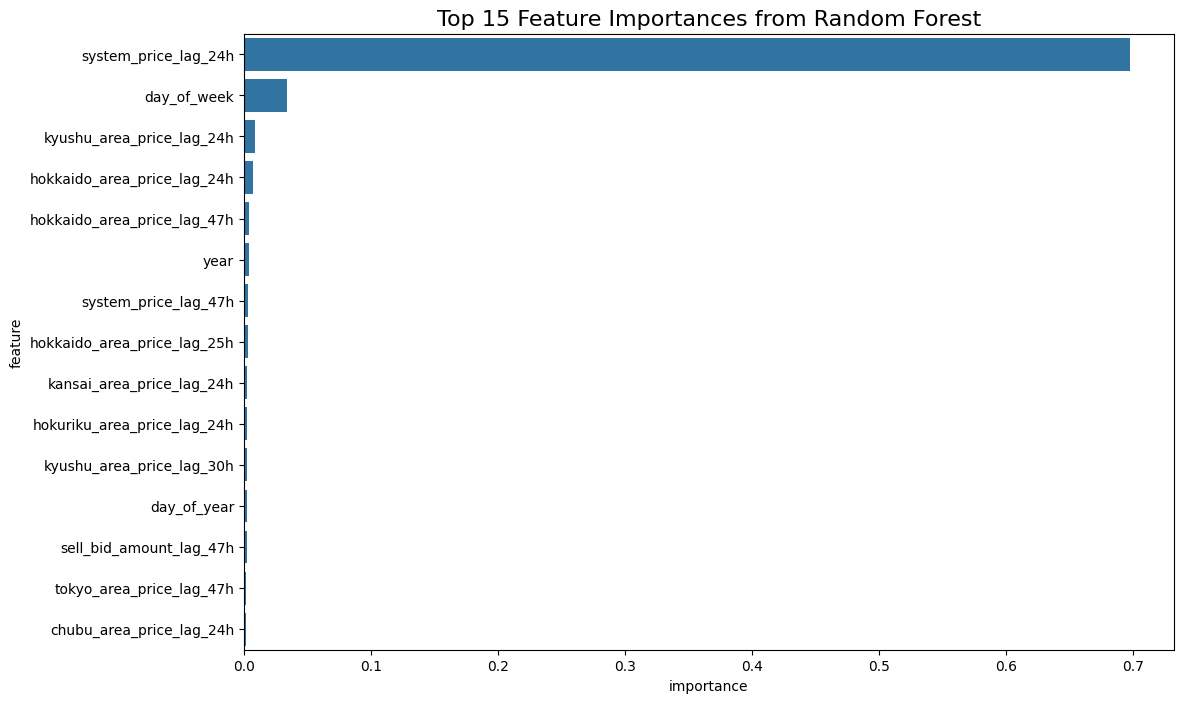

In [43]:
# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train_1.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.show()

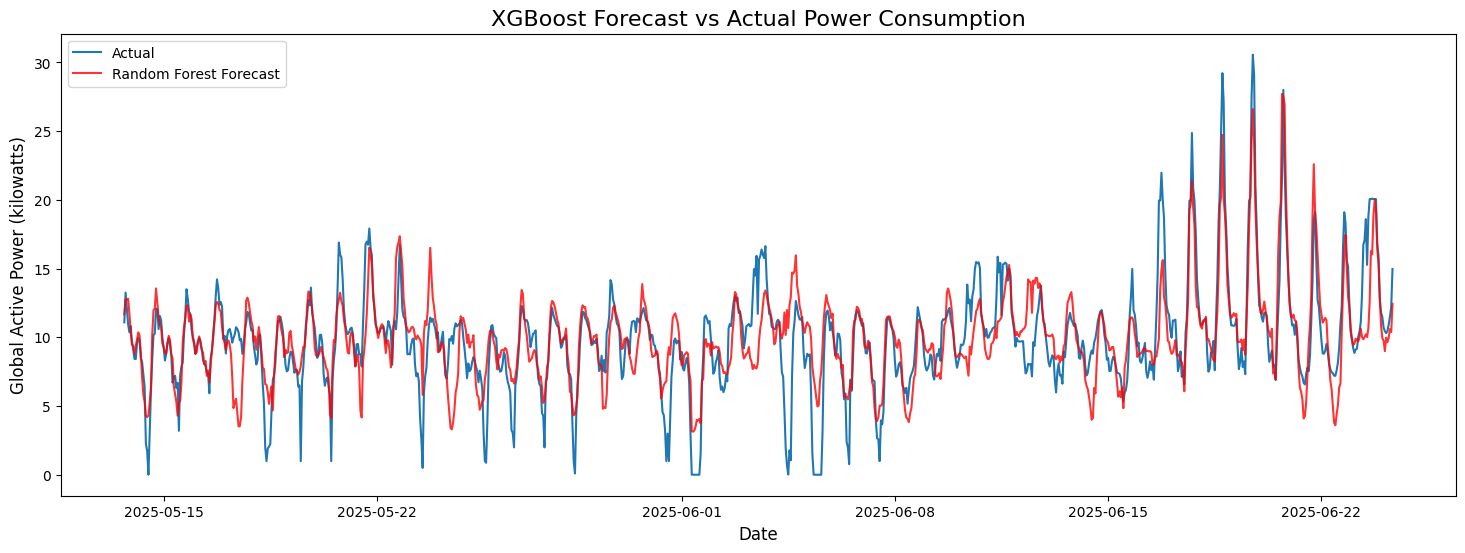

In [44]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_1[:1000].index, y_test_1[:1000], label='Actual')
plt.plot(y_test_1[:1000].index, rf_predictions[:1000], color='red', label='Random Forest Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)
plt.legend()
plt.show()

In [45]:
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1, objective='reg:squarederror')
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_1, y_train_1,
                eval_set=[(X_test_1, y_test_1)]) # Corrected the call to fit
print("Training complete.")

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test_1)

# Evaluate the model
xgb_rmse = np.sqrt(mean_squared_error(y_test_1, xgb_predictions))
xgb_mae = mean_absolute_error(y_test_1, xgb_predictions)

print(f"\nXGBoost Model Performance:")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE: {xgb_mae:.4f}")


Training XGBoost model...
[0]	validation_0-rmse:5.17567
[1]	validation_0-rmse:4.96500
[2]	validation_0-rmse:4.77497
[3]	validation_0-rmse:4.58790
[4]	validation_0-rmse:4.41233
[5]	validation_0-rmse:4.24842
[6]	validation_0-rmse:4.09994
[7]	validation_0-rmse:3.95838
[8]	validation_0-rmse:3.82204
[9]	validation_0-rmse:3.70698
[10]	validation_0-rmse:3.59823
[11]	validation_0-rmse:3.49619
[12]	validation_0-rmse:3.39790
[13]	validation_0-rmse:3.30854
[14]	validation_0-rmse:3.22611
[15]	validation_0-rmse:3.14956
[16]	validation_0-rmse:3.07790
[17]	validation_0-rmse:3.00734
[18]	validation_0-rmse:2.95064
[19]	validation_0-rmse:2.89385
[20]	validation_0-rmse:2.84523
[21]	validation_0-rmse:2.79786
[22]	validation_0-rmse:2.75424
[23]	validation_0-rmse:2.71166
[24]	validation_0-rmse:2.67384
[25]	validation_0-rmse:2.64017
[26]	validation_0-rmse:2.61023
[27]	validation_0-rmse:2.58153
[28]	validation_0-rmse:2.55611
[29]	validation_0-rmse:2.53824
[30]	validation_0-rmse:2.52097
[31]	validation_0-rmse

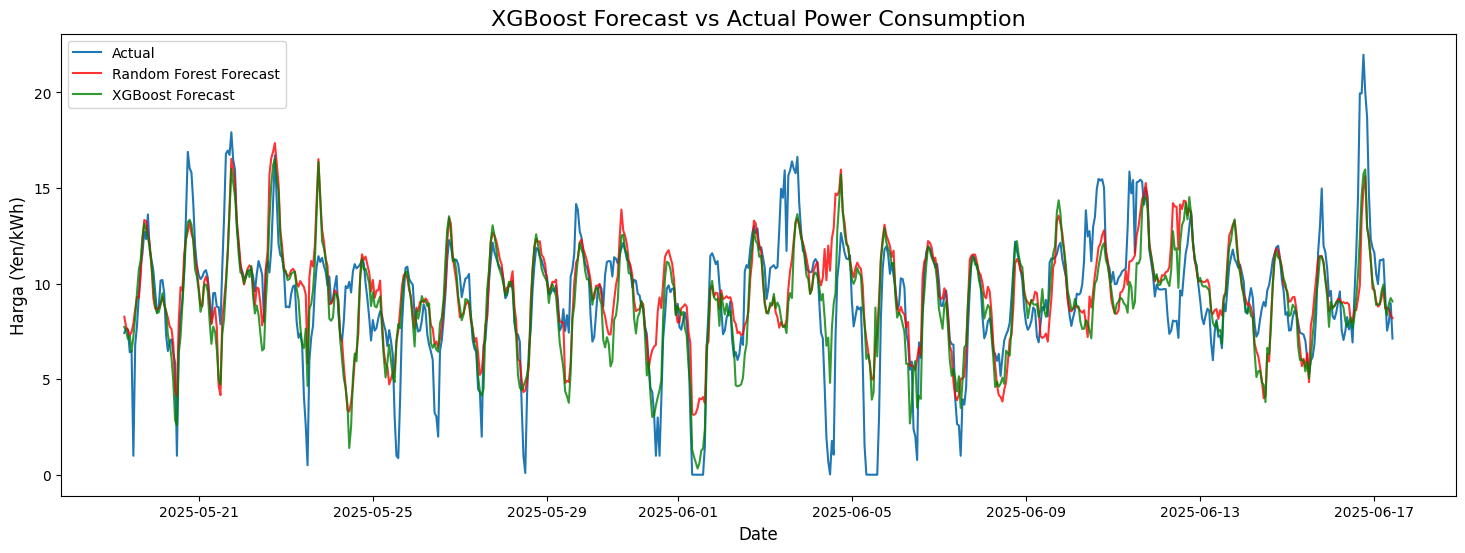

In [46]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_1[134:834].index, y_test_1[134:834], label='Actual')
plt.plot(y_test_1[134:834].index, rf_predictions[134:834], color='red', label='Random Forest Forecast', alpha=0.8)
plt.plot(y_test_1[134:834].index, xgb_predictions[134:834], color='green', label='XGBoost Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Harga (Yen/kWh)', fontsize=12)
plt.legend()
plt.show()

In [54]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# no random state for time series

X_train, X_val, y_train, y_val = train_test_split(df_featured.drop(columns=['system_price']), df_featured['system_price'], test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, shuffle=False)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    # The loop must stop earlier to account for the lag
    for i in range(25, len(X) - (2 * time_steps - 1)):
        # The input sequence is the same
        v = X[i:(i + time_steps)]
        Xs.append(v)
        
        # The target is now time_steps ahead of the end of the sequence
        target_idx = i + 2 * time_steps - 1
        ys.append(y[target_idx])
        
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print("Data prepared for RNN models.")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

Data prepared for RNN models.
X_train_seq shape: (26136, 24, 22)
y_train_seq shape: (26136, 1)


In [48]:
X_train_seq

array([[[0.21762567, 0.39896448, 0.44174681, ..., 0.        ,
         0.        , 0.        ],
        [0.27759807, 0.43064625, 0.47400181, ..., 0.        ,
         0.        , 0.        ],
        [0.29152915, 0.44638473, 0.48182486, ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.35705289, 0.51130729, 0.567614  , ..., 0.        ,
         0.        , 0.        ],
        [0.31463615, 0.46504085, 0.52597785, ..., 0.        ,
         0.        , 0.        ],
        [0.27906931, 0.41782188, 0.49819374, ..., 0.        ,
         0.        , 0.        ]],

       [[0.27759807, 0.43064625, 0.47400181, ..., 0.        ,
         0.        , 0.        ],
        [0.29152915, 0.44638473, 0.48182486, ..., 0.        ,
         0.        , 0.        ],
        [0.29972763, 0.45827334, 0.48452476, ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.31463615, 0.46504085, 0.52597785, ..., 0.        ,
         0.        , 0.        ],
        [0.2

In [49]:
class WeightNormConv1D(layers.Layer):
    def __init__(self, filters, kernel_size, dilation_rate=1, padding='causal', activation='relu', **kwargs):
        super(WeightNormConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.padding = padding
        self.activation_name = activation
        self.conv = Conv1D(filters=filters, kernel_size=kernel_size,
                           dilation_rate=dilation_rate, padding=padding, use_bias=False)
        self.g = self.add_weight(name='g', shape=(filters,), initializer='ones', trainable=True)
        self.activation = Activation(activation)
        
    def call(self, inputs):
        # Perform convolution
        conv_output = self.conv(inputs)

        # Get the kernel weights
        v = self.conv.trainable_weights[0]  # Shape: (kernel_size, input_channels, filters)

        # Compute the norm of v along the first two dimensions
        v_norm = tf.norm(v, axis=[0, 1], keepdims=True)  # Shape: (1, 1, filters)

        # Normalize the weights and scale by g
        w = (self.g / v_norm) * v  # Shape: (kernel_size, input_channels, filters)

        # Manually update the kernel weights with normalized weights
        self.conv.kernel.assign(w)

        # Apply the activation function to the convolution output
        return self.activation(conv_output)
    
    def get_config(self):
        config = super(WeightNormConv1D, self).get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate,
            "padding": self.padding,
            "activation": self.activation_name
        })
        return config

# TCN Block (No changes required; it's a functional block)
def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout_rate=0.3, sequence=True):
    conv = WeightNormConv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate)(x)
    conv = Dropout(dropout_rate)(conv)
    x = Conv1D(filters=filters, kernel_size=1, padding='same')(x)
    x = Add()([x, conv])
    if not sequence:
        x = GlobalAveragePooling1D()(x)
    return x

In [50]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

def Bilstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x1 = Bidirectional(LSTM(128, return_sequences=False))(inputs)
    x1 = Dropout(0.2)(x1)
    # x1 = Bidirectional(LSTM(64, return_sequences=True))(x1)
    # x1 = Dropout(0.2)(x1)
    # x1 = Bidirectional(LSTM(32, return_sequences=False))(x1)
    # x1 = Dropout(0.2)(x1)

    # TCN Layer (Using Conv1D for simplicity)
    x2 = tcn_block(inputs, filters=32, kernel_size=7, dilation_rate=1, dropout_rate=0.2, sequence=True)
    x2 = tcn_block(x2, filters=32, kernel_size=7, dilation_rate=2, dropout_rate=0.2, sequence=True)
    x2 = tcn_block(x2, filters=32, kernel_size=7, dilation_rate=4, dropout_rate=0.2, sequence=False)

    x = Concatenate()([x1, x2])

    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizer, loss='mse')
    return model

model = Bilstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 24, 22)]     0           []                               
                                                                                                  
 weight_norm_conv1d (WeightNorm  (None, 24, 32)      4960        ['input_1[0][0]']                
 Conv1D)                                                                                          
                                                                                                  
 conv1d_1 (Conv1D)              (None, 24, 32)       736         ['input_1[0][0]']                
                                                                                                  
 dropout_1 (Dropout)            (None, 24, 32)       0           ['weight_norm_conv1d[0][0]'] 

In [55]:
# Train the LSTM model
print("\nTraining LSTM model...")
lstm_history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    shuffle=False
)
print("Training complete.")

# Make predictions
lstm_predictions_scaled = model.predict(X_test_seq)
# Inverse transform predictions to original scale
lstm_predictions = target_scaler.inverse_transform(lstm_predictions_scaled)

# Inverse transform actuals to original scale for comparison
y_test_actual = target_scaler.inverse_transform(y_test_seq)

# Evaluate the model
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)

print(f"\nLSTM Model Performance:")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")


Training LSTM model...
Epoch 1/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0028 - val_loss: 0.0010
Epoch 2/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 3/20
409/409 [==============================] - 4s 9ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 4/20
409/409 [==============================] - 4s 9ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 5/20
409/409 [==============================] - 4s 9ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 6/20
409/409 [==============================] - 4s 9ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 7/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 8/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 9/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 10/20
409/409 [==============================] - 4s 10ms/step - l

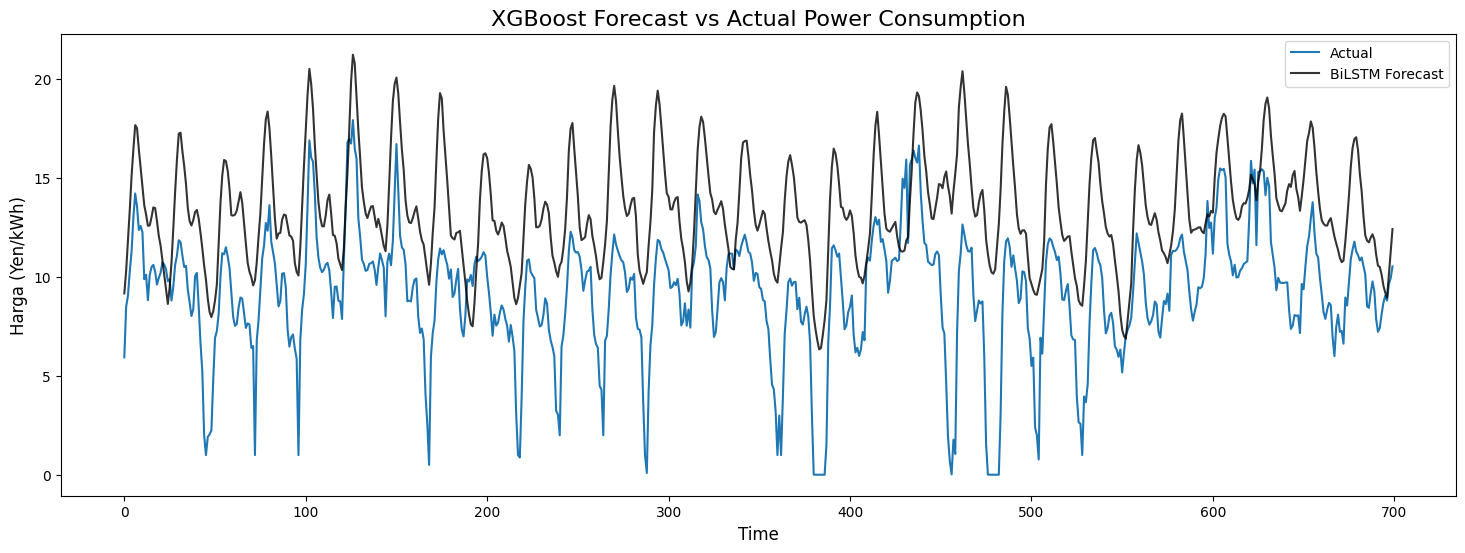

In [56]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_actual[:700], label='Actual')
# plt.plot(rf_predictions[134:834], color='red', label='Random Forest Forecast', alpha=0.8)
# plt.plot(xgb_predictions[134:834], color='green', label='XGBoost Forecast', alpha=0.8)
plt.plot(lstm_predictions[:700], color='black', label='BiLSTM Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Harga (Yen/kWh)', fontsize=12)
plt.legend()
plt.show()

# Combined Data

In [28]:
weather_df = pd.read_csv('data/weather.csv')
jepx_df = pd.read_csv('data/jepx_2022.csv')

weather_df['date_time'] = pd.to_datetime(weather_df['date_time'])
weather_df.set_index('date_time', inplace=True)
jepx_df['date_time'] = pd.to_datetime(jepx_df['date_time'])
jepx_df.set_index('date_time', inplace=True)

In [29]:
jepx_df = jepx_df.resample('h').mean()
jepx_df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,chugoku_area_price,shikoku_area_price,kyushu_area_price,sell_block_bid_total_amount,total_sell_block_execution_amount,buy_block_bid_total_amount,total_buy_block_total_amount
date_time,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,18841875.0,20167825.0,16960850.0,15.460,19.850,19.850,19.850,19.850,19.850,19.850,19.850,19.850,13.250,5078250.0,3815550.0,2149850.0,1269250.0
2022-01-01 01:00:00,21068300.0,21134525.0,17718050.0,15.460,18.610,18.610,18.610,18.610,18.610,18.610,18.610,18.610,13.250,5824950.0,3938750.0,3534175.0,2422775.0
2022-01-01 02:00:00,22100150.0,21453250.0,18018200.0,15.460,17.595,17.595,17.595,17.595,17.595,17.595,17.595,17.595,13.250,6524875.0,3935175.0,4163550.0,3000525.0
2022-01-01 03:00:00,22982925.0,21574900.0,18159450.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,16.785,16.785,11.890,6982575.0,3931425.0,4626375.0,3438875.0
2022-01-01 04:00:00,23685750.0,21616450.0,18330475.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,16.785,16.785,10.530,7207250.0,3931750.0,4985375.0,3770800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00,22288600.0,22215700.0,16218650.0,11.795,15.270,14.240,14.240,11.410,11.410,11.410,11.410,11.410,11.410,5507525.0,1550000.0,1883900.0,1748900.0
2025-09-26 20:00:00,22787100.0,21286575.0,15459075.0,11.500,13.440,12.535,12.535,11.410,10.865,10.865,10.865,10.865,10.865,6651575.0,1373225.0,1940700.0,1809250.0
2025-09-26 21:00:00,22922825.0,20512950.0,14937225.0,11.305,13.380,11.490,11.490,11.410,9.500,9.500,9.500,9.500,9.500,6963900.0,1211575.0,1844375.0,1749725.0


In [18]:
weather_df

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,pressure_msl,cloud_cover,cloud_cover_low,cloud_cover_high,cloud_cover_mid,wind_speed_10m,wind_direction_10m,wind_speed_100m,wind_direction_100m,weather_code
date_time,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,2.731000,48.675410,0.0,0.0,0.0,1019.6,1.0,0.0,0.0,4.0,16.575644,267.510500,29.091030,282.14426,0.0
2022-01-01 01:00:00+00:00,4.381000,39.190080,0.0,0.0,0.0,1019.9,0.0,0.0,0.0,0.0,25.809765,300.141300,32.359974,302.27563,0.0
2022-01-01 02:00:00+00:00,5.231000,27.463337,0.0,0.0,0.0,1019.7,2.0,1.0,0.0,2.0,39.187120,308.659820,49.419754,308.79020,0.0
2022-01-01 03:00:00+00:00,5.581000,28.690434,0.0,0.0,0.0,1019.2,3.0,3.0,0.0,2.0,39.966484,315.364900,49.639550,314.70618,0.0
2022-01-01 04:00:00+00:00,5.431000,32.518950,0.0,0.0,0.0,1019.0,0.0,0.0,0.0,0.0,38.440853,326.458740,47.040302,324.97200,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00+00:00,22.130999,91.501150,0.1,0.1,0.0,1015.8,100.0,100.0,0.0,100.0,7.186487,22.067963,13.298089,39.50765,51.0
2025-09-26 20:00:00+00:00,21.831000,93.478096,0.7,0.7,0.0,1016.1,100.0,100.0,10.0,100.0,7.019999,337.380100,12.074766,349.69522,53.0
2025-09-26 21:00:00+00:00,21.730999,95.215164,0.4,0.4,0.0,1016.4,100.0,100.0,4.0,100.0,6.072165,348.023900,10.658068,4.84392,51.0


In [31]:
if jepx_df.index.tz is None:
    jepx_df = jepx_df.tz_localize('UTC')

if weather_df.index.tz is None:
    weather_df = weather_df.tz_localize('UTC')

# --- 3. Join the DataFrames ---
# .join() will combine the two DataFrames by matching their indexes (the date_time).
# It will take all columns from both tables and put them together.
merged_df = jepx_df.join(weather_df)

merged_df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,...,pressure_msl,cloud_cover,cloud_cover_low,cloud_cover_high,cloud_cover_mid,wind_speed_10m,wind_direction_10m,wind_speed_100m,wind_direction_100m,weather_code
date_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,18841875.0,20167825.0,16960850.0,15.460,19.850,19.850,19.850,19.850,19.850,19.850,...,1019.6,1.0,0.0,0.0,4.0,16.575644,267.510500,29.091030,282.14426,0.0
2022-01-01 01:00:00+00:00,21068300.0,21134525.0,17718050.0,15.460,18.610,18.610,18.610,18.610,18.610,18.610,...,1019.9,0.0,0.0,0.0,0.0,25.809765,300.141300,32.359974,302.27563,0.0
2022-01-01 02:00:00+00:00,22100150.0,21453250.0,18018200.0,15.460,17.595,17.595,17.595,17.595,17.595,17.595,...,1019.7,2.0,1.0,0.0,2.0,39.187120,308.659820,49.419754,308.79020,0.0
2022-01-01 03:00:00+00:00,22982925.0,21574900.0,18159450.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,...,1019.2,3.0,3.0,0.0,2.0,39.966484,315.364900,49.639550,314.70618,0.0
2022-01-01 04:00:00+00:00,23685750.0,21616450.0,18330475.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,...,1019.0,0.0,0.0,0.0,0.0,38.440853,326.458740,47.040302,324.97200,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00+00:00,22288600.0,22215700.0,16218650.0,11.795,15.270,14.240,14.240,11.410,11.410,11.410,...,1015.8,100.0,100.0,0.0,100.0,7.186487,22.067963,13.298089,39.50765,51.0
2025-09-26 20:00:00+00:00,22787100.0,21286575.0,15459075.0,11.500,13.440,12.535,12.535,11.410,10.865,10.865,...,1016.1,100.0,100.0,10.0,100.0,7.019999,337.380100,12.074766,349.69522,53.0
2025-09-26 21:00:00+00:00,22922825.0,20512950.0,14937225.0,11.305,13.380,11.490,11.490,11.410,9.500,9.500,...,1016.4,100.0,100.0,4.0,100.0,6.072165,348.023900,10.658068,4.84392,51.0


In [32]:
merged_df.to_csv('data/jepx_weather.csv')

In [5]:
# load jepx_weather data
jepx_weather_df = pd.read_csv('data/jepx_weather.csv')
jepx_weather_df['date_time'] = pd.to_datetime(jepx_weather_df['date_time'])
jepx_weather_df.set_index('date_time', inplace=True)
jepx_weather_df

,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,...,pressure_msl,cloud_cover,cloud_cover_low,cloud_cover_high,cloud_cover_mid,wind_speed_10m,wind_direction_10m,wind_speed_100m,wind_direction_100m,weather_code
date_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,18841875.0,20167825.0,16960850.0,15.460,19.850,19.850,19.850,19.850,19.850,19.850,...,1019.6,1.0,0.0,0.0,4.0,16.575644,267.510500,29.091030,282.14426,0.0
2022-01-01 01:00:00+00:00,21068300.0,21134525.0,17718050.0,15.460,18.610,18.610,18.610,18.610,18.610,18.610,...,1019.9,0.0,0.0,0.0,0.0,25.809765,300.141300,32.359974,302.27563,0.0
2022-01-01 02:00:00+00:00,22100150.0,21453250.0,18018200.0,15.460,17.595,17.595,17.595,17.595,17.595,17.595,...,1019.7,2.0,1.0,0.0,2.0,39.187120,308.659820,49.419754,308.79020,0.0
2022-01-01 03:00:00+00:00,22982925.0,21574900.0,18159450.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,...,1019.2,3.0,3.0,0.0,2.0,39.966484,315.364900,49.639550,314.70618,0.0
2022-01-01 04:00:00+00:00,23685750.0,21616450.0,18330475.0,15.460,16.785,16.785,16.785,16.785,16.785,16.785,...,1019.0,0.0,0.0,0.0,0.0,38.440853,326.458740,47.040302,324.97200,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26 19:00:00+00:00,22288600.0,22215700.0,16218650.0,11.795,15.270,14.240,14.240,11.410,11.410,11.410,...,1015.8,100.0,100.0,0.0,100.0,7.186487,22.067963,13.298089,39.50765,51.0
2025-09-26 20:00:00+00:00,22787100.0,21286575.0,15459075.0,11.500,13.440,12.535,12.535,11.410,10.865,10.865,...,1016.1,100.0,100.0,10.0,100.0,7.019999,337.380100,12.074766,349.69522,53.0
2025-09-26 21:00:00+00:00,22922825.0,20512950.0,14937225.0,11.305,13.380,11.490,11.490,11.410,9.500,9.500,...,1016.4,100.0,100.0,4.0,100.0,6.072165,348.023900,10.658068,4.84392,51.0


In [57]:
jepx_weather_featured = create_features(jepx_weather_df)
print("\nData dengan fitur-fitur baru:")
jepx_weather_featured.head()


Data dengan fitur-fitur baru:


,sell_bid_amount,buy_bid_amount,total_contract_amount,system_price,hokkaido_area_price,tohoku_area_price,tokyo_area_price,chubu_area_price,hokuriku_area_price,kansai_area_price,...,wind_direction_10m,wind_speed_100m,wind_direction_100m,weather_code,hour,day_of_week,day_of_year,month,quarter,year
date_time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,18841875.0,20167825.0,16960850.0,15.46,19.850,19.850,19.850,19.850,19.850,19.850,...,267.51050,29.091030,282.14426,0.0,0,5,1,1,1,2022
2022-01-01 01:00:00+00:00,21068300.0,21134525.0,17718050.0,15.46,18.610,18.610,18.610,18.610,18.610,18.610,...,300.14130,32.359974,302.27563,0.0,1,5,1,1,1,2022
2022-01-01 02:00:00+00:00,22100150.0,21453250.0,18018200.0,15.46,17.595,17.595,17.595,17.595,17.595,17.595,...,308.65982,49.419754,308.79020,0.0,2,5,1,1,1,2022
2022-01-01 03:00:00+00:00,22982925.0,21574900.0,18159450.0,15.46,16.785,16.785,16.785,16.785,16.785,16.785,...,315.36490,49.639550,314.70618,0.0,3,5,1,1,1,2022
2022-01-01 04:00:00+00:00,23685750.0,21616450.0,18330475.0,15.46,16.785,16.785,16.785,16.785,16.785,16.785,...,326.45874,47.040302,324.97200,0.0,4,5,1,1,1,2022


In [58]:
jepx_weather_df.columns

Index(['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount',
       'system_price', 'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'pressure_msl', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_high',
       'cloud_cover_mid', 'wind_speed_10m', 'wind_direction_10m',
       'wind_speed_100m', 'wind_direction_100m', 'weather_code'],
      dtype='object')

In [65]:
def create_sliding_window_dataset_combined(df, window_days,target):
    """
    Creates a sliding window dataset from the hourly data.
    """

    feature = ['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount', 
               'hokkaido_area_price', 'tohoku_area_price',
        'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'pressure_msl', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_high',
       'cloud_cover_mid', 'wind_speed_10m', 'wind_direction_10m',
       'wind_speed_100m', 'wind_direction_100m', 'weather_code']
    
    window_size_hours = window_days * 24
    day1 = [col for col in feature]
    df_windowed = df.copy()

    print(f"\nCreating dataset for a {window_days}-day ({window_size_hours}-hour) sliding window...")

    feature = ['sell_bid_amount', 'buy_bid_amount', 'total_contract_amount',
       'system_price', 'hokkaido_area_price', 'tohoku_area_price',
       'tokyo_area_price', 'chubu_area_price', 'hokuriku_area_price',
       'kansai_area_price', 'chugoku_area_price', 'shikoku_area_price',
       'kyushu_area_price', 'sell_block_bid_total_amount',
       'total_sell_block_execution_amount', 'buy_block_bid_total_amount',
       'total_buy_block_total_amount', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'rain', 'snowfall',
       'pressure_msl', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_high',
       'cloud_cover_mid', 'wind_speed_10m', 'wind_direction_10m',
       'wind_speed_100m', 'wind_direction_100m', 'weather_code']

    # Create lagged features for all columns in the dataframe
    for col in feature:
        for i in range(24, window_size_hours + 24):
            # The .shift(i) function pushes data from 'i' hours ago to the current row.
            # This creates our feature set (X) based on past data.
            df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)

    # The shifting operations create NaN values at the beginning and end of the dataframe.
    # We need to remove these rows as they cannot be used for training.
    df_windowed = df_windowed.drop(columns=day1, axis=1)
    final_df = df_windowed.dropna()

    print(f"Finished creating {window_days}-day window. Final dataset shape: {final_df.shape}")
    return final_df

combined_1_ml = create_sliding_window_dataset_combined(jepx_weather_featured, window_days=1, target='system_price')
# combined_2_ml = create_sliding_window_dataset_combined(jepx_weather_df, window_days=2, target='system_price')
# combined_7_ml = create_sliding_window_dataset_combined(jepx_weather_df, window_days=7, target='system_price')


Creating dataset for a 1-day (24-hour) sliding window...


C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2523699263.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2523699263.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_windowed[f'{col}_lag_{i}h'] = df_windowed[col].shift(i)
C:\Users\ideap\AppData\Local\Temp\ipykernel_18064\2523699263.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Finished creating 1-day window. Final dataset shape: (32713, 775)


In [66]:
def split_data(df, target, test_size=0.1):
    """
    Splits the dataframe into training and testing sets.
    """
    train_data = df.iloc[:-int(test_size * len(df))]
    test_data = df.iloc[-int(test_size * len(df)):]
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]
    return X_train, y_train, X_test, y_test

X_train_1, y_train_1, X_test_1, y_test_1 = split_data(combined_1_ml, target='system_price')
# X_train_2, y_train_2, X_test_2, y_test_2 = split_data(df_2_ml, target='system_price')
# X_train_7, y_train_7, X_test_7, y_test_7 = split_data(df_7_ml, target='system_price')

In [67]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=5)
print("Training Random Forest model...")
rf_model.fit(X_train_1, y_train_1)
print("Training complete.")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test_1)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test_1, rf_predictions))
rf_mae = mean_absolute_error(y_test_1, rf_predictions)

print(f"\nRandom Forest Model Performance:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

Training Random Forest model...
Training complete.

Random Forest Model Performance:
RMSE: 2.3418
MAE: 1.5068


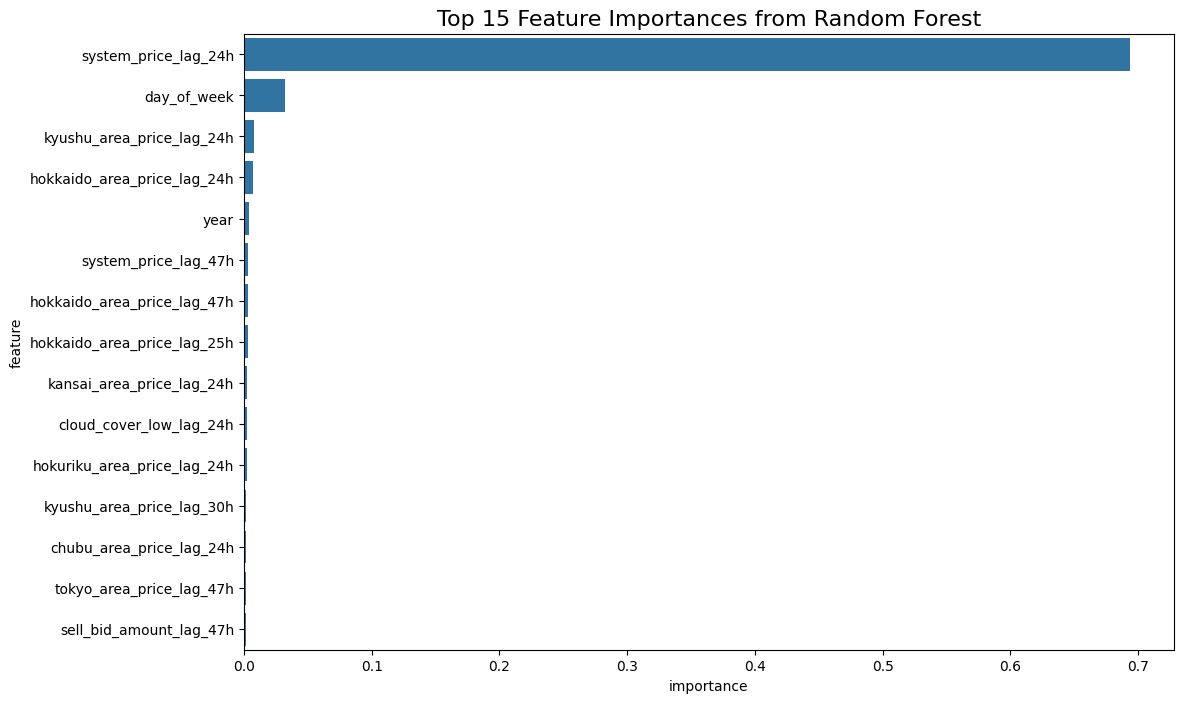

In [68]:
# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train_1.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.show()

In [69]:
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1, objective='reg:squarederror')
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_1, y_train_1,
                eval_set=[(X_test_1, y_test_1)]) # Corrected the call to fit
print("Training complete.")

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test_1)

# Evaluate the model
xgb_rmse = np.sqrt(mean_squared_error(y_test_1, xgb_predictions))
xgb_mae = mean_absolute_error(y_test_1, xgb_predictions)

print(f"\nXGBoost Model Performance:")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE: {xgb_mae:.4f}")


Training XGBoost model...
[0]	validation_0-rmse:5.17548
[1]	validation_0-rmse:4.96498
[2]	validation_0-rmse:4.77413
[3]	validation_0-rmse:4.58679
[4]	validation_0-rmse:4.41751
[5]	validation_0-rmse:4.25203
[6]	validation_0-rmse:4.10534
[7]	validation_0-rmse:3.96757
[8]	validation_0-rmse:3.83911
[9]	validation_0-rmse:3.70771
[10]	validation_0-rmse:3.59346
[11]	validation_0-rmse:3.48851
[12]	validation_0-rmse:3.39320
[13]	validation_0-rmse:3.30290
[14]	validation_0-rmse:3.21407
[15]	validation_0-rmse:3.13644
[16]	validation_0-rmse:3.06980
[17]	validation_0-rmse:3.00005
[18]	validation_0-rmse:2.93807
[19]	validation_0-rmse:2.88285
[20]	validation_0-rmse:2.83256
[21]	validation_0-rmse:2.78033
[22]	validation_0-rmse:2.73633
[23]	validation_0-rmse:2.69625
[24]	validation_0-rmse:2.65790
[25]	validation_0-rmse:2.62454
[26]	validation_0-rmse:2.59021
[27]	validation_0-rmse:2.56266
[28]	validation_0-rmse:2.53814
[29]	validation_0-rmse:2.51667
[30]	validation_0-rmse:2.49467
[31]	validation_0-rmse

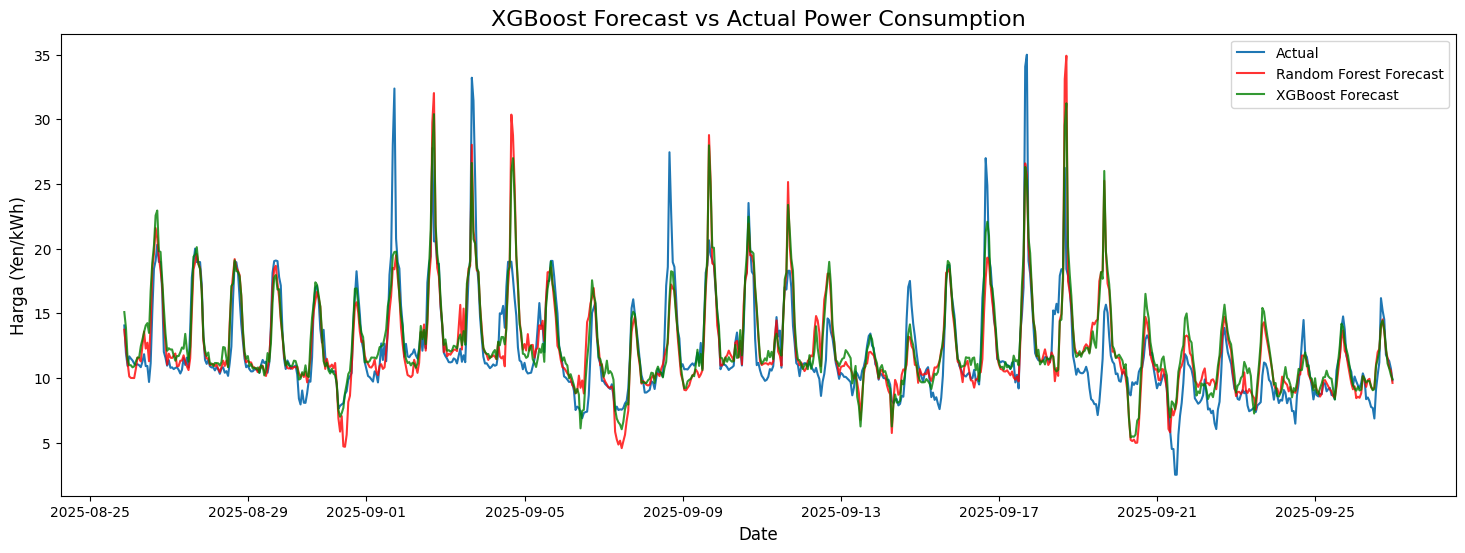

In [82]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_1[2500:].index, y_test_1[2500:], label='Actual')
plt.plot(y_test_1[2500:].index, rf_predictions[2500:], color='red', label='Random Forest Forecast', alpha=0.8)
plt.plot(y_test_1[2500:].index, xgb_predictions[2500:], color='green', label='XGBoost Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Harga (Yen/kWh)', fontsize=12)
plt.legend()
plt.show()

In [71]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import train_test_split

# no random state for time series

X_train, X_val, y_train, y_val = train_test_split(jepx_weather_featured.drop(columns=['system_price']), jepx_weather_featured['system_price'], test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, shuffle=False)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    # The loop must stop earlier to account for the lag
    for i in range(25, len(X) - (2 * time_steps - 1)):
        # The input sequence is the same
        v = X[i:(i + time_steps)]
        Xs.append(v)
        
        # The target is now time_steps ahead of the end of the sequence
        target_idx = i + 2 * time_steps - 1
        ys.append(y[target_idx])
        
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print("Data prepared for RNN models.")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

Data prepared for RNN models.
X_train_seq shape: (26136, 24, 37)
y_train_seq shape: (26136, 1)


In [72]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

def Bilstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x1 = Bidirectional(LSTM(128, return_sequences=False))(inputs)
    x1 = Dropout(0.2)(x1)
    # x1 = Bidirectional(LSTM(64, return_sequences=True))(x1)
    # x1 = Dropout(0.2)(x1)
    # x1 = Bidirectional(LSTM(32, return_sequences=False))(x1)
    # x1 = Dropout(0.2)(x1)

    # TCN Layer (Using Conv1D for simplicity)
    x2 = tcn_block(inputs, filters=32, kernel_size=7, dilation_rate=1, dropout_rate=0.2, sequence=True)
    x2 = tcn_block(x2, filters=32, kernel_size=7, dilation_rate=2, dropout_rate=0.2, sequence=True)
    x2 = tcn_block(x2, filters=32, kernel_size=7, dilation_rate=4, dropout_rate=0.2, sequence=False)

    x = Concatenate()([x1, x2])

    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizer, loss='mse')
    return model

model = Bilstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 24, 37)]     0           []                               
                                                                                                  
 weight_norm_conv1d_3 (WeightNo  (None, 24, 32)      8320        ['input_2[0][0]']                
 rmConv1D)                                                                                        
                                                                                                  
 conv1d_7 (Conv1D)              (None, 24, 32)       1216        ['input_2[0][0]']                
                                                                                                  
 dropout_5 (Dropout)            (None, 24, 32)       0           ['weight_norm_conv1d_3[0][0

In [73]:
# Train the BiLSTM model
print("\nTraining LSTM model...")
lstm_history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    shuffle=False
)
print("Training complete.")

# Make predictions
lstm_predictions_scaled = model.predict(X_test_seq)
# Inverse transform predictions to original scale
lstm_predictions = target_scaler.inverse_transform(lstm_predictions_scaled)

# Inverse transform actuals to original scale for comparison
y_test_actual = target_scaler.inverse_transform(y_test_seq)

# Evaluate the model
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)

print(f"\nBiLSTM Model Performance:")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")


Training LSTM model...
Epoch 1/20
409/409 [==============================] - 6s 11ms/step - loss: 0.0123 - val_loss: 0.0240
Epoch 2/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0051 - val_loss: 0.0080
Epoch 3/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 4/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0034 - val_loss: 8.4075e-04
Epoch 5/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 6/20
409/409 [==============================] - 4s 10ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 7/20
409/409 [==============================] - 4s 11ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 8/20
409/409 [==============================] - 4s 11ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 9/20
409/409 [==============================] - 5s 11ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 10/20
409/409 [==============================] - 4s 10ms/

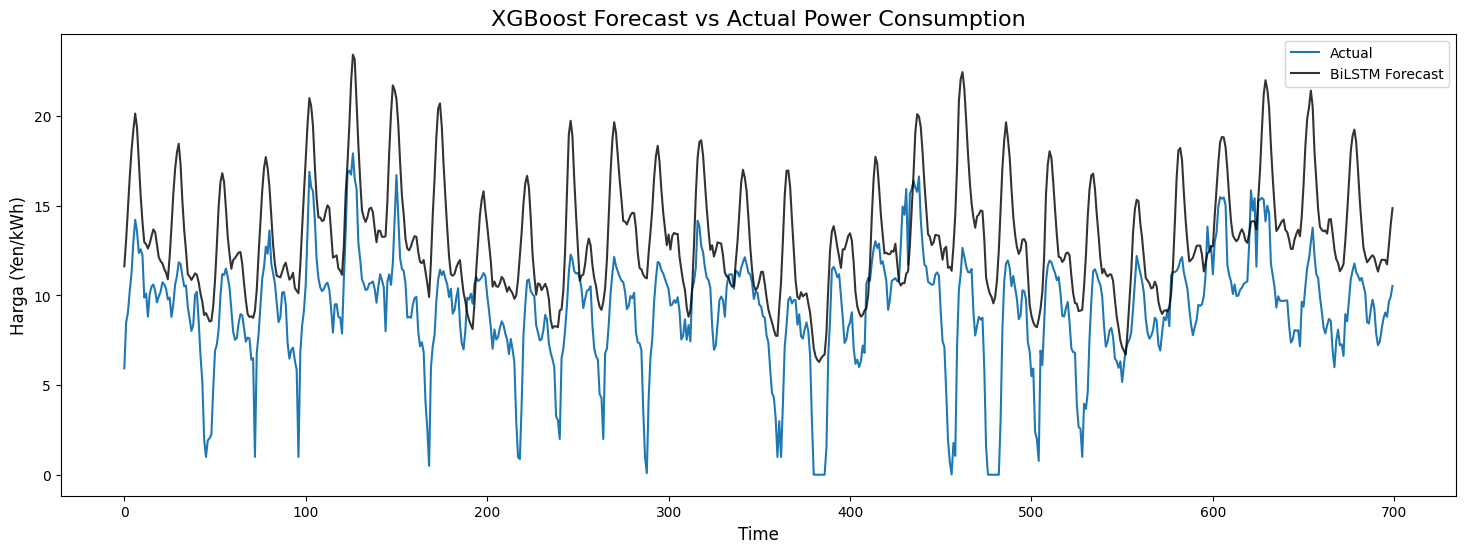

In [74]:
# Plot predictions vs actuals for the best ML model
plt.figure(figsize=(18, 6))
plt.plot(y_test_actual[:700], label='Actual')
# plt.plot(rf_predictions[134:834], color='red', label='Random Forest Forecast', alpha=0.8)
# plt.plot(xgb_predictions[134:834], color='green', label='XGBoost Forecast', alpha=0.8)
plt.plot(lstm_predictions[:700], color='black', label='BiLSTM Forecast', alpha=0.8)
plt.title('XGBoost Forecast vs Actual Power Consumption', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Harga (Yen/kWh)', fontsize=12)
plt.legend()
plt.show()